In [1]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

CSI_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_calibrated"
)

SEQ_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_sequence"
)

SPLIT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline_split"
)

print("CSI directory:", CSI_DIR)
print("Sequence directory:", SEQ_DIR)
print("Split directory:", SPLIT_DIR)

CSI directory: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\mmfi_calibrated
Sequence directory: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\mmfi_sequence
Split directory: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\baseline_split


In [4]:
# ============================================================
# LOAD CALIBRATED MM-Fi DATA
# ============================================================

import os
import numpy as np

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

CSI_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_calibrated"
)

amplitude = np.load(
    os.path.join(CSI_DIR, "amplitude_clean.npy"),
    mmap_mode="r"
)

phase = np.load(
    os.path.join(CSI_DIR, "phase_calibrated.npy"),
    mmap_mode="r"
)

pose = np.load(
    os.path.join(CSI_DIR, "pose.npy"),
    mmap_mode="r"
)

subjects = np.load(
    os.path.join(CSI_DIR, "subject.npy")
)

actions = np.load(
    os.path.join(CSI_DIR, "action.npy")
)

print("Loaded successfully.")
print()
print("Amplitude:", amplitude.shape, amplitude.dtype)
print("Phase    :", phase.shape, phase.dtype)
print("Pose     :", pose.shape, pose.dtype)
print("Subjects :", subjects.shape, np.unique(subjects))
print("Actions  :", actions.shape, np.unique(actions))

Loaded successfully.

Amplitude: (270, 297, 3, 114, 10) float32
Phase    : (270, 297, 3, 114, 10) float32
Pose     : (270, 297, 17, 2) float32
Subjects : (270,) [ 1  2  3  4  5  6  7  8  9 10]
Actions  : (270,) [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27]


In [5]:
# ============================================================
# PHASE-ENHANCED DATASET
# ============================================================

from torch.utils.data import Dataset

TRAIN_SUBJECTS = [1, 2, 3, 4, 5, 6, 7]
VAL_SUBJECTS = [8]
TEST_SUBJECTS = [9, 10]

WINDOW = 30
STRIDE = 15

train_seq = np.where(
    np.isin(subjects, TRAIN_SUBJECTS)
)[0]

val_seq = np.where(
    np.isin(subjects, VAL_SUBJECTS)
)[0]

test_seq = np.where(
    np.isin(subjects, TEST_SUBJECTS)
)[0]


# Training-only pose normalization
pose_mean = np.asarray(
    pose[train_seq].mean(axis=(0, 1)),
    dtype=np.float32
)

pose_std = np.asarray(
    pose[train_seq].std(axis=(0, 1)),
    dtype=np.float32
)

pose_std = np.maximum(
    pose_std,
    1e-6
)


class PhaseEnhancedDataset(Dataset):

    def __init__(
        self,
        sequence_indices
    ):

        self.sequence_indices = sequence_indices

        self.windows = []

        for seq in sequence_indices:

            for start in range(
                0,
                amplitude.shape[1] - WINDOW + 1,
                STRIDE
            ):

                self.windows.append(
                    (
                        int(seq),
                        int(start)
                    )
                )

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        seq, start = self.windows[index]

        end = start + WINDOW

        # Amplitude
        amp = np.asarray(
            amplitude[
                seq,
                start:end
            ],
            dtype=np.float32
        )

        # Calibrated phase
        ph = np.asarray(
            phase[
                seq,
                start:end
            ],
            dtype=np.float32
        )

        # Circular phase representation
        sin_ph = np.sin(ph)
        cos_ph = np.cos(ph)

        # ----------------------------------------------------
        # 3 amplitude channels
        # + 3 sin(phase) channels
        # + 3 cos(phase) channels
        #
        # = 9 CSI channels
        # ----------------------------------------------------

        x = np.concatenate(
            [
                amp,
                sin_ph,
                cos_ph
            ],
            axis=1
        )

        # Central/target frame
        target_frame = end - 1

        y = np.asarray(
            pose[
                seq,
                target_frame
            ],
            dtype=np.float32
        )

        y = (
            y - pose_mean
        ) / pose_std

        return (
            torch.from_numpy(x.copy()),
            torch.from_numpy(y.copy())
        )


# ============================================================
# CREATE DATASETS
# ============================================================

train_dataset = PhaseEnhancedDataset(
    train_seq
)

val_dataset = PhaseEnhancedDataset(
    val_seq
)

test_dataset = PhaseEnhancedDataset(
    test_seq
)


print("Train sequences:", len(train_seq))
print("Validation sequences:", len(val_seq))
print("Test sequences:", len(test_seq))

print()

print("Train windows:", len(train_dataset))
print("Validation windows:", len(val_dataset))
print("Test windows:", len(test_dataset))


# ============================================================
# CHECK ONE SAMPLE
# ============================================================

x, y = train_dataset[0]

print()
print("Sample CSI:", tuple(x.shape))
print("Sample pose:", tuple(y.shape))
print("CSI dtype:", x.dtype)
print("Pose dtype:", y.dtype)

Train sequences: 189
Validation sequences: 27
Test sequences: 54

Train windows: 3402
Validation windows: 486
Test windows: 972

Sample CSI: (30, 9, 114, 10)
Sample pose: (17, 2)
CSI dtype: torch.float32
Pose dtype: torch.float32


In [6]:
import torch
import torch.nn as nn


class PhaseEnhancedFrameCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                in_channels=9,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):

        x = self.features(x)

        return x.flatten(1)


class CSIPhase2Pose(nn.Module):

    def __init__(self):
        super().__init__()

        self.frame_cnn = PhaseEnhancedFrameCNN()

        self.gru = nn.GRU(
            input_size=32,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.head = nn.Sequential(

            nn.Linear(64, 128),

            nn.ReLU(),

            nn.Linear(128, 34)
        )

    def forward(self, x):

        batch_size = x.shape[0]
        sequence_length = x.shape[1]

        # (B, 30, 9, 114, 10)
        # →
        # (B*30, 9, 114, 10)

        x = x.reshape(
            batch_size * sequence_length,
            9,
            114,
            10
        )

        x = self.frame_cnn(x)

        # (B*30, 32)
        # →
        # (B, 30, 32)

        x = x.reshape(
            batch_size,
            sequence_length,
            32
        )

        x, _ = self.gru(x)

        # Final temporal representation
        x = x[:, -1, :]

        x = self.head(x)

        return x.reshape(
            batch_size,
            17,
            2
        )


# ============================================================
# MODEL CHECK
# ============================================================

model = CSIPhase2Pose()

dummy = torch.randn(
    4,
    30,
    9,
    114,
    10
)

output = model(dummy)

print("Input :", tuple(dummy.shape))
print("Output:", tuple(output.shape))

parameters = sum(
    p.numel()
    for p in model.parameters()
)

print("Parameters:", parameters)

Input : (4, 30, 9, 114, 10)
Output: (4, 17, 2)
Parameters: 37570


In [7]:
# ============================================================
# TRAIN PHASE-ENHANCED MODEL
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-3
PATIENCE = 5

DEVICE = torch.device("cpu")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

model = CSIPhase2Pose().to(DEVICE)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

best_val_loss = float("inf")
patience_counter = 0

os.makedirs(
    os.path.join(ROOT, "models"),
    exist_ok=True
)

checkpoint_path = os.path.join(
    ROOT,
    "models",
    "phase_best.pt"
)

print("========================================")
print("PHASE-ENHANCED TRAINING")
print("========================================")

for epoch in range(1, EPOCHS + 1):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0

    for x, y in train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = model(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()
        optimizer.step()

        train_loss += (
            loss.item() * x.size(0)
        )

    train_loss /= len(train_dataset)


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for x, y in val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = model(x)

            loss = criterion(
                prediction,
                y
            )

            val_loss += (
                loss.item() * x.size(0)
            )

    val_loss /= len(val_dataset)


    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    # --------------------------------------------------------
    # SAVE BEST
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "val_loss":
                    val_loss
            },
            checkpoint_path
        )

        print("  -> Best model saved")

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print("\nEarly stopping.")
        break


print("\n========================================")
print("TRAINING COMPLETE")
print("========================================")

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    checkpoint_path
)

PHASE-ENHANCED TRAINING
Epoch 01/30 | Train Loss: 0.988264 | Val Loss: 1.215697
  -> Best model saved
Epoch 02/30 | Train Loss: 0.945657 | Val Loss: 1.321314
  -> No improvement (1/5)
Epoch 03/30 | Train Loss: 0.922020 | Val Loss: 1.302829
  -> No improvement (2/5)
Epoch 04/30 | Train Loss: 0.893526 | Val Loss: 1.094151
  -> Best model saved
Epoch 05/30 | Train Loss: 0.863380 | Val Loss: 2.257301
  -> No improvement (1/5)
Epoch 06/30 | Train Loss: 0.826002 | Val Loss: 1.187541
  -> No improvement (2/5)
Epoch 07/30 | Train Loss: 0.807621 | Val Loss: 1.199665
  -> No improvement (3/5)
Epoch 08/30 | Train Loss: 0.773621 | Val Loss: 1.119877
  -> No improvement (4/5)
Epoch 09/30 | Train Loss: 0.747127 | Val Loss: 1.426988
  -> No improvement (5/5)

Early stopping.

TRAINING COMPLETE
Best validation loss: 1.0941513987725655
Checkpoint: C:\Users\ROHITH KANNA S\WiFiVision\models\phase_best.pt


In [8]:
# ============================================================
# EVALUATE PHASE-ENHANCED MODEL
# ============================================================

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

# Load best validation checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        prediction = model(x)

        all_predictions.append(
            prediction.cpu().numpy()
        )

        all_targets.append(
            y.numpy()
        )

pred_phase = np.concatenate(
    all_predictions,
    axis=0
)

target_phase = np.concatenate(
    all_targets,
    axis=0
)

# ------------------------------------------------------------
# Convert normalized coordinates back
# ------------------------------------------------------------

pred_phase = (
    pred_phase * pose_std
    + pose_mean
)

target_phase = (
    target_phase * pose_std
    + pose_mean
)

# ------------------------------------------------------------
# Joint Euclidean error
# ------------------------------------------------------------

phase_errors = np.sqrt(
    np.sum(
        (pred_phase - target_phase) ** 2,
        axis=2
    )
)

phase_mpjpe = np.mean(
    phase_errors
)

# ------------------------------------------------------------
# PCK
# ------------------------------------------------------------

thresholds = [0.05, 0.10, 0.15, 0.20]

phase_pck = {}

for threshold in thresholds:

    phase_pck[threshold] = np.mean(
        phase_errors <= threshold
    )

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("========================================")
print("PHASE-ENHANCED TEST EVALUATION")
print("========================================")

print("Test subjects:", TEST_SUBJECTS)
print("Test windows :", len(test_dataset))

print()

print(
    f"MPJPE: {phase_mpjpe:.6f}"
)

print()

print("PCK:")

for threshold in thresholds:

    print(
        f"@ {threshold:.2f}: "
        f"{phase_pck[threshold] * 100:.2f}%"
    )

PHASE-ENHANCED TEST EVALUATION
Test subjects: [9, 10]
Test windows : 972

MPJPE: 0.146023

PCK:
@ 0.05: 17.97%
@ 0.10: 50.92%
@ 0.15: 69.17%
@ 0.20: 77.30%


In [9]:
# ============================================================
# EXPERIMENT C — RICHER SPATIAL CNN
# ============================================================

class SpatialFrameCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            # ------------------------------------------------
            # Block 1
            # ------------------------------------------------

            nn.Conv2d(
                3, 16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.MaxPool2d(2),


            # ------------------------------------------------
            # Block 2
            # ------------------------------------------------

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),


            # ------------------------------------------------
            # Block 3
            # ------------------------------------------------

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(),

            # ------------------------------------------------
            # Preserve spatial structure longer
            # ------------------------------------------------

            nn.AdaptiveAvgPool2d(
                (4, 2)
            )
        )

        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64 * 4 * 2,
                64
            ),

            nn.ReLU()
        )


    def forward(self, x):

        x = self.features(x)

        x = self.projection(x)

        return x


class SpatialCSI2Pose(nn.Module):

    def __init__(self):
        super().__init__()

        self.frame_cnn = SpatialFrameCNN()

        self.gru = nn.GRU(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.head = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )


    def forward(self, x):

        batch_size = x.shape[0]
        sequence_length = x.shape[1]

        # (B, 30, 3, 114, 10)
        x = x.reshape(
            batch_size * sequence_length,
            3,
            114,
            10
        )

        x = self.frame_cnn(x)

        # (B*30, 64)
        x = x.reshape(
            batch_size,
            sequence_length,
            64
        )

        x, _ = self.gru(x)

        # Final temporal representation
        x = x[:, -1, :]

        x = self.head(x)

        return x.reshape(
            batch_size,
            17,
            2
        )


# ============================================================
# CHECK
# ============================================================

spatial_model = SpatialCSI2Pose()

dummy = torch.randn(
    4,
    30,
    3,
    114,
    10
)

output = spatial_model(dummy)

parameters = sum(
    p.numel()
    for p in spatial_model.parameters()
)

print("Input :", tuple(dummy.shape))
print("Output:", tuple(output.shape))
print("Parameters:", parameters)

Input : (4, 30, 3, 114, 10)
Output: (4, 17, 2)
Parameters: 94306


In [ ]:
# ============================================================
# EXPERIMENT C — AMPLITUDE-ONLY SPATIAL DATASET + TRAINING
# ============================================================

from torch.utils.data import Dataset, DataLoader


# ============================================================
# AMPLITUDE-ONLY DATASET
# ============================================================

class AmplitudeDataset(Dataset):

    def __init__(
        self,
        sequence_indices
    ):

        self.sequence_indices = sequence_indices
        self.windows = []

        for seq in sequence_indices:

            for start in range(
                0,
                amplitude.shape[1] - WINDOW + 1,
                STRIDE
            ):

                self.windows.append(
                    (
                        int(seq),
                        int(start)
                    )
                )

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        seq, start = self.windows[index]

        end = start + WINDOW

        # ----------------------------------------------------
        # AMPLITUDE ONLY
        #
        # (30, 3, 114, 10)
        # ----------------------------------------------------

        x = np.asarray(
            amplitude[
                seq,
                start:end
            ],
            dtype=np.float32
        )

        # ----------------------------------------------------
        # TARGET FRAME
        # ----------------------------------------------------

        target_frame = end - 1

        y = np.asarray(
            pose[
                seq,
                target_frame
            ],
            dtype=np.float32
        )

        # Training-only normalization
        y = (
            y - pose_mean
        ) / pose_std

        return (
            torch.from_numpy(x.copy()),
            torch.from_numpy(y.copy())
        )


# ============================================================
# CREATE CORRECT DATASETS
# ============================================================

amp_train_dataset = AmplitudeDataset(
    train_seq
)

amp_val_dataset = AmplitudeDataset(
    val_seq
)

amp_test_dataset = AmplitudeDataset(
    test_seq
)


print("========================================")
print("EXPERIMENT C DATASET")
print("========================================")

print(
    "Train windows:",
    len(amp_train_dataset)
)

print(
    "Validation windows:",
    len(amp_val_dataset)
)

print(
    "Test windows:",
    len(amp_test_dataset)
)


# ============================================================
# VERIFY INPUT SHAPE BEFORE TRAINING
# ============================================================

sample_x, sample_y = amp_train_dataset[0]

print()
print(
    "Sample CSI shape:",
    tuple(sample_x.shape)
)

print(
    "Sample pose shape:",
    tuple(sample_y.shape)
)


# ============================================================
# DATALOADERS
# ============================================================

amp_train_loader = DataLoader(
    amp_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

amp_val_loader = DataLoader(
    amp_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)


# ============================================================
# MODEL
# ============================================================

DEVICE = torch.device("cpu")

spatial_model = SpatialCSI2Pose().to(
    DEVICE
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    spatial_model.parameters(),
    lr=1e-3
)

EPOCHS = 30
PATIENCE = 5

best_val_loss = float("inf")
patience_counter = 0

spatial_checkpoint = os.path.join(
    ROOT,
    "models",
    "spatial_best.pt"
)


# ============================================================
# TRAIN
# ============================================================

print()
print("========================================")
print("EXPERIMENT C — RICHER SPATIAL CNN")
print("========================================")

for epoch in range(1, EPOCHS + 1):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    spatial_model.train()

    train_loss = 0.0

    for x, y in amp_train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = spatial_model(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item() * x.size(0)
        )

    train_loss /= len(
        amp_train_dataset
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    spatial_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for x, y in amp_val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = spatial_model(x)

            loss = criterion(
                prediction,
                y
            )

            val_loss += (
                loss.item() * x.size(0)
            )

    val_loss /= len(
        amp_val_dataset
    )


    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    # --------------------------------------------------------
    # SAVE BEST
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    spatial_model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "val_loss":
                    val_loss
            },
            spatial_checkpoint
        )

        print("  -> Best model saved")

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print()
        print("Early stopping.")
        break


print()
print("========================================")
print("EXPERIMENT C COMPLETE")
print("========================================")

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    spatial_checkpoint
)

EXPERIMENT C DATASET
Train windows: 3402
Validation windows: 486
Test windows: 972

Sample CSI shape: (30, 3, 114, 10)
Sample pose shape: (17, 2)

EXPERIMENT C — RICHER SPATIAL CNN
Epoch 01/30 | Train Loss: 0.972847 | Val Loss: 1.474588
  -> Best model saved
Epoch 02/30 | Train Loss: 0.911154 | Val Loss: 1.242667
  -> Best model saved


In [ ]:
# ============================================================
# EXPERIMENT C — AMPLITUDE-ONLY SPATIAL DATASET + TRAINING
# ============================================================

from torch.utils.data import Dataset, DataLoader


# ============================================================
# AMPLITUDE-ONLY DATASET
# ============================================================

class AmplitudeDataset(Dataset):

    def __init__(
        self,
        sequence_indices
    ):

        self.sequence_indices = sequence_indices
        self.windows = []

        for seq in sequence_indices:

            for start in range(
                0,
                amplitude.shape[1] - WINDOW + 1,
                STRIDE
            ):

                self.windows.append(
                    (
                        int(seq),
                        int(start)
                    )
                )

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        seq, start = self.windows[index]

        end = start + WINDOW

        # ----------------------------------------------------
        # AMPLITUDE ONLY
        #
        # (30, 3, 114, 10)
        # ----------------------------------------------------

        x = np.asarray(
            amplitude[
                seq,
                start:end
            ],
            dtype=np.float32
        )

        # ----------------------------------------------------
        # TARGET FRAME
        # ----------------------------------------------------

        target_frame = end - 1

        y = np.asarray(
            pose[
                seq,
                target_frame
            ],
            dtype=np.float32
        )

        # Training-only normalization
        y = (
            y - pose_mean
        ) / pose_std

        return (
            torch.from_numpy(x.copy()),
            torch.from_numpy(y.copy())
        )


# ============================================================
# CREATE CORRECT DATASETS
# ============================================================

amp_train_dataset = AmplitudeDataset(
    train_seq
)

amp_val_dataset = AmplitudeDataset(
    val_seq
)

amp_test_dataset = AmplitudeDataset(
    test_seq
)


print("========================================")
print("EXPERIMENT C DATASET")
print("========================================")

print(
    "Train windows:",
    len(amp_train_dataset)
)

print(
    "Validation windows:",
    len(amp_val_dataset)
)

print(
    "Test windows:",
    len(amp_test_dataset)
)


# ============================================================
# VERIFY INPUT SHAPE BEFORE TRAINING
# ============================================================

sample_x, sample_y = amp_train_dataset[0]

print()
print(
    "Sample CSI shape:",
    tuple(sample_x.shape)
)

print(
    "Sample pose shape:",
    tuple(sample_y.shape)
)


# ============================================================
# DATALOADERS
# ============================================================

amp_train_loader = DataLoader(
    amp_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

amp_val_loader = DataLoader(
    amp_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)


# ============================================================
# MODEL
# ============================================================

DEVICE = torch.device("cpu")

spatial_model = SpatialCSI2Pose().to(
    DEVICE
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    spatial_model.parameters(),
    lr=1e-3
)

EPOCHS = 30
PATIENCE = 5

best_val_loss = float("inf")
patience_counter = 0

spatial_checkpoint = os.path.join(
    ROOT,
    "models",
    "spatial_best.pt"
)


# ============================================================
# TRAIN
# ============================================================

print()
print("========================================")
print("EXPERIMENT C — RICHER SPATIAL CNN")
print("========================================")

for epoch in range(1, EPOCHS + 1):

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    spatial_model.train()

    train_loss = 0.0

    for x, y in amp_train_loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        prediction = spatial_model(x)

        loss = criterion(
            prediction,
            y
        )

        loss.backward()

        optimizer.step()

        train_loss += (
            loss.item() * x.size(0)
        )

    train_loss /= len(
        amp_train_dataset
    )


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    spatial_model.eval()

    val_loss = 0.0

    with torch.no_grad():

        for x, y in amp_val_loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            prediction = spatial_model(x)

            loss = criterion(
                prediction,
                y
            )

            val_loss += (
                loss.item() * x.size(0)
            )

    val_loss /= len(
        amp_val_dataset
    )


    # --------------------------------------------------------
    # REPORT
    # --------------------------------------------------------

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )


    # --------------------------------------------------------
    # SAVE BEST
    # --------------------------------------------------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    spatial_model.state_dict(),
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "val_loss":
                    val_loss
            },
            spatial_checkpoint
        )

        print("  -> Best model saved")

    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if patience_counter >= PATIENCE:

        print()
        print("Early stopping.")
        break


print()
print("========================================")
print("EXPERIMENT C COMPLETE")
print("========================================")

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Checkpoint:",
    spatial_checkpoint
)

EXPERIMENT C DATASET
Train windows: 3402
Validation windows: 486
Test windows: 972

Sample CSI shape: (30, 3, 114, 10)
Sample pose shape: (17, 2)

EXPERIMENT C — RICHER SPATIAL CNN
Epoch 01/30 | Train Loss: 0.972847 | Val Loss: 1.474588
  -> Best model saved
Epoch 02/30 | Train Loss: 0.911154 | Val Loss: 1.242667
  -> Best model saved


In [3]:
# ============================================================
# COMPLETE SETUP — REBUILD VARIABLES AFTER KERNEL RESTART
# ============================================================

import os
import numpy as np
import torch

# ============================================================
# ROOT PATH
# ============================================================

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

CSI_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "mmfi_calibrated"
)

SPLIT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline_split"
)


# ============================================================
# LOAD DATA
# ============================================================

amplitude = np.load(
    os.path.join(
        CSI_DIR,
        "amplitude_clean.npy"
    ),
    mmap_mode="r"
)

pose = np.load(
    os.path.join(
        CSI_DIR,
        "pose.npy"
    ),
    mmap_mode="r"
)

subject = np.load(
    os.path.join(
        CSI_DIR,
        "subject.npy"
    )
)

action = np.load(
    os.path.join(
        CSI_DIR,
        "action.npy"
    )
)


# ============================================================
# CREATE SUBJECT SPLIT
#
# Train      : Subjects 1–7
# Validation : Subject 8
# Test       : Subjects 9–10
# ============================================================

train_seq = np.where(
    np.isin(
        subject,
        [1, 2, 3, 4, 5, 6, 7]
    )
)[0]

val_seq = np.where(
    subject == 8
)[0]

test_seq = np.where(
    np.isin(
        subject,
        [9, 10]
    )
)[0]


# ============================================================
# LOAD POSE NORMALIZATION
# ============================================================

pose_mean = np.load(
    os.path.join(
        SPLIT_DIR,
        "pose_mean.npy"
    )
)

pose_std = np.load(
    os.path.join(
        SPLIT_DIR,
        "pose_std.npy"
    )
)


# ============================================================
# WINDOW SETTINGS
# ============================================================

WINDOW = 30
STRIDE = 15


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device("cpu")


# ============================================================
# VALIDATION
# ============================================================

print("============================================================")
print("SETUP COMPLETE")
print("============================================================")

print()
print("Amplitude shape:", amplitude.shape)
print("Pose shape     :", pose.shape)

print()
print("Train sequences:", len(train_seq))
print("Val sequences  :", len(val_seq))
print("Test sequences :", len(test_seq))

print()
print("Train subjects:", np.unique(subject[train_seq]))
print("Val subjects  :", np.unique(subject[val_seq]))
print("Test subjects :", np.unique(subject[test_seq]))

print()
print("Pose mean shape:", pose_mean.shape)
print("Pose std shape :", pose_std.shape)

print()
print("WINDOW:", WINDOW)
print("STRIDE:", STRIDE)
print("DEVICE:", DEVICE)

SETUP COMPLETE

Amplitude shape: (270, 297, 3, 114, 10)
Pose shape     : (270, 297, 17, 2)

Train sequences: 189
Val sequences  : 27
Test sequences : 54

Train subjects: [1 2 3 4 5 6 7]
Val subjects  : [8]
Test subjects : [ 9 10]

Pose mean shape: (17, 2)
Pose std shape : (17, 2)

WINDOW: 30
STRIDE: 15
DEVICE: cpu


In [4]:
# ============================================================
# EXPERIMENT C — RECREATE DATASET
# ============================================================

from torch.utils.data import Dataset, DataLoader


class AmplitudeDataset(Dataset):

    def __init__(self, sequence_indices):

        self.windows = []

        for seq in sequence_indices:

            for start in range(
                0,
                amplitude.shape[1] - WINDOW + 1,
                STRIDE
            ):
                self.windows.append(
                    (int(seq), int(start))
                )

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, index):

        seq, start = self.windows[index]
        end = start + WINDOW

        # Input: (30, 3, 114, 10)
        x = np.asarray(
            amplitude[seq, start:end],
            dtype=np.float32
        )

        # Target: last frame of window
        y = np.asarray(
            pose[seq, end - 1],
            dtype=np.float32
        )

        # Normalize target using training statistics
        y = (y - pose_mean) / pose_std

        return (
            torch.from_numpy(x.copy()),
            torch.from_numpy(y.copy())
        )


# ============================================================
# CREATE DATASETS
# ============================================================

amp_train_dataset = AmplitudeDataset(train_seq)
amp_val_dataset = AmplitudeDataset(val_seq)
amp_test_dataset = AmplitudeDataset(test_seq)


# ============================================================
# CREATE LOADERS
# ============================================================

BATCH_SIZE = 8

amp_train_loader = DataLoader(
    amp_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

amp_val_loader = DataLoader(
    amp_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

amp_test_loader = DataLoader(
    amp_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


# ============================================================
# VERIFY
# ============================================================

print("============================================================")
print("EXPERIMENT C DATASET READY")
print("============================================================")

print("Train windows:", len(amp_train_dataset))
print("Val windows  :", len(amp_val_dataset))
print("Test windows :", len(amp_test_dataset))

x, y = amp_train_dataset[0]

print()
print("Sample input :", tuple(x.shape))
print("Sample target:", tuple(y.shape))
print("Input dtype  :", x.dtype)
print("Target dtype :", y.dtype)

EXPERIMENT C DATASET READY
Train windows: 3402
Val windows  : 486
Test windows : 972

Sample input : (30, 3, 114, 10)
Sample target: (17, 2)
Input dtype  : torch.float32
Target dtype : torch.float32


In [5]:
# ============================================================
# EXPERIMENT C — RICHER SPATIAL CNN MODEL
# ============================================================

import torch
import torch.nn as nn


# ============================================================
# FRAME-LEVEL SPATIAL CNN
# ============================================================

class SpatialFrameCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Input:
            # (B, 3, 114, 10)

            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            nn.Conv2d(
                in_channels=64,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = x.flatten(1)

        return x


# ============================================================
# EXPERIMENT C MODEL
# ============================================================

class SpatialCSI2Pose(nn.Module):

    def __init__(self):

        super().__init__()

        self.frame_cnn = SpatialFrameCNN()


        self.gru = nn.GRU(

            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )


        self.head = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )


    def forward(self, x):

        # Input:
        # (B, 30, 3, 114, 10)

        batch_size = x.shape[0]

        sequence_length = x.shape[1]


        # ----------------------------------------
        # Merge batch and temporal dimensions
        # ----------------------------------------

        x = x.reshape(

            batch_size * sequence_length,
            3,
            114,
            10
        )


        # ----------------------------------------
        # Spatial CNN
        # ----------------------------------------

        x = self.frame_cnn(x)

        # (B * T, 64)


        # ----------------------------------------
        # Restore temporal dimension
        # ----------------------------------------

        x = x.reshape(

            batch_size,
            sequence_length,
            64
        )


        # ----------------------------------------
        # Temporal GRU
        # ----------------------------------------

        x, _ = self.gru(x)


        # Use final temporal representation

        x = x[:, -1, :]


        # ----------------------------------------
        # Pose prediction
        # ----------------------------------------

        x = self.head(x)

        x = x.reshape(

            batch_size,
            17,
            2
        )

        return x


# ============================================================
# MODEL CHECK
# ============================================================

spatial_model = SpatialCSI2Pose().to(DEVICE)

x = torch.randn(
    8,
    30,
    3,
    114,
    10
).to(DEVICE)

with torch.no_grad():
    y = spatial_model(x)


parameters = sum(
    p.numel()
    for p in spatial_model.parameters()
    if p.requires_grad
)


print("============================================================")
print("EXPERIMENT C MODEL CHECK")
print("============================================================")

print("Parameters:", parameters)
print("Input :", tuple(x.shape))
print("Output:", tuple(y.shape))

assert y.shape == (8, 17, 2)

print()
print("Shape check: PASSED")

EXPERIMENT C MODEL CHECK
Parameters: 94306
Input : (8, 30, 3, 114, 10)
Output: (8, 17, 2)

Shape check: PASSED


In [7]:
# ============================================================
# INSPECT EXPERIMENT C CHECKPOINT
# ============================================================

checkpoint = torch.load(
    spatial_checkpoint,
    map_location="cpu"
)

state_dict = checkpoint["model_state_dict"]

print("============================================================")
print("CHECKPOINT ARCHITECTURE")
print("============================================================")

for key, value in state_dict.items():

    print(
        f"{key:<50}",
        tuple(value.shape)
    )

CHECKPOINT ARCHITECTURE
frame_cnn.features.0.weight                        (16, 3, 3, 3)
frame_cnn.features.0.bias                          (16,)
frame_cnn.features.1.weight                        (16,)
frame_cnn.features.1.bias                          (16,)
frame_cnn.features.1.running_mean                  (16,)
frame_cnn.features.1.running_var                   (16,)
frame_cnn.features.1.num_batches_tracked           ()
frame_cnn.features.4.weight                        (32, 16, 3, 3)
frame_cnn.features.4.bias                          (32,)
frame_cnn.features.5.weight                        (32,)
frame_cnn.features.5.bias                          (32,)
frame_cnn.features.5.running_mean                  (32,)
frame_cnn.features.5.running_var                   (32,)
frame_cnn.features.5.num_batches_tracked           ()
frame_cnn.features.8.weight                        (64, 32, 3, 3)
frame_cnn.features.8.bias                          (64,)
frame_cnn.features.9.weight                 

In [9]:
# ============================================================
# EXPERIMENT C — CHECKPOINT-COMPATIBLE MODEL
# ============================================================

import torch
import torch.nn as nn


# ============================================================
# FRAME-LEVEL SPATIAL CNN
# ============================================================

class SpatialFrameCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Input:
            # (B, 3, 114, 10)

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU(),

            # Force spatial representation
            # to 64 × 8 × 1 = 512 features

            nn.AdaptiveAvgPool2d(
                (8, 1)
            )
        )


        # Flatten + 512 → 64 projection
        #
        # Sequential index 1 is Linear,
        # matching:
        # frame_cnn.projection.1.weight (64, 512)

        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                512,
                64
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.projection(x)

        return x


# ============================================================
# EXPERIMENT C MODEL
# ============================================================

class SpatialCSI2Pose(nn.Module):

    def __init__(self):

        super().__init__()

        self.frame_cnn = SpatialFrameCNN()


        self.gru = nn.GRU(

            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )


        self.head = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )


    def forward(self, x):

        # Input:
        # (B, 30, 3, 114, 10)

        batch_size = x.shape[0]

        sequence_length = x.shape[1]


        # ------------------------------------------------
        # Merge batch and temporal dimensions
        # ------------------------------------------------

        x = x.reshape(

            batch_size * sequence_length,
            3,
            114,
            10
        )


        # ------------------------------------------------
        # Spatial CNN
        # ------------------------------------------------

        x = self.frame_cnn(x)

        # (B × T, 64)


        # ------------------------------------------------
        # Restore temporal dimension
        # ------------------------------------------------

        x = x.reshape(

            batch_size,
            sequence_length,
            64
        )


        # ------------------------------------------------
        # GRU
        # ------------------------------------------------

        x, _ = self.gru(x)


        # Final temporal representation

        x = x[:, -1, :]


        # ------------------------------------------------
        # Pose prediction
        # ------------------------------------------------

        x = self.head(x)

        x = x.reshape(

            batch_size,
            17,
            2
        )

        return x


# ============================================================
# MODEL CHECK
# ============================================================

spatial_model = SpatialCSI2Pose().to(DEVICE)

test_x = torch.randn(
    8,
    30,
    3,
    114,
    10
).to(DEVICE)


with torch.no_grad():

    test_y = spatial_model(test_x)


parameters = sum(
    p.numel()
    for p in spatial_model.parameters()
    if p.requires_grad
)


print("============================================================")
print("CHECKPOINT-COMPATIBLE MODEL")
print("============================================================")

print("Parameters:", parameters)

print("Input :",
      tuple(test_x.shape))

print("Output:",
      tuple(test_y.shape))


assert test_y.shape == (
    8,
    17,
    2
)

print()
print("Shape check: PASSED")

CHECKPOINT-COMPATIBLE MODEL
Parameters: 94306
Input : (8, 30, 3, 114, 10)
Output: (8, 17, 2)

Shape check: PASSED


In [10]:
# ============================================================
# EXPERIMENT C — FINAL TEST EVALUATION
# ============================================================

import os
import numpy as np
import torch


# ============================================================
# TEST DATALOADER
# ============================================================

amp_test_loader = DataLoader(
    amp_test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)


# ============================================================
# ENSURE BEST CHECKPOINT IS LOADED
# ============================================================

spatial_checkpoint = os.path.join(
    ROOT,
    "models",
    "spatial_best.pt"
)

checkpoint = torch.load(
    spatial_checkpoint,
    map_location=DEVICE
)

spatial_model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

spatial_model.eval()


print("============================================================")
print("EXPERIMENT C — TEST EVALUATION")
print("============================================================")

print("Test windows:", len(amp_test_dataset))
print("Checkpoint:", spatial_checkpoint)


# ============================================================
# GENERATE PREDICTIONS
# ============================================================

all_predictions = []
all_targets = []


with torch.no_grad():

    for x, y in amp_test_loader:

        x = x.to(DEVICE)

        prediction = spatial_model(x)

        all_predictions.append(
            prediction.cpu().numpy()
        )

        all_targets.append(
            y.numpy()
        )


# ============================================================
# COMBINE BATCHES
# ============================================================

predictions = np.concatenate(
    all_predictions,
    axis=0
)

targets = np.concatenate(
    all_targets,
    axis=0
)


print()
print("Predictions:", predictions.shape)
print("Targets    :", targets.shape)


# ============================================================
# DENORMALIZE POSE
# ============================================================

predictions = (
    predictions * pose_std
) + pose_mean

targets = (
    targets * pose_std
) + pose_mean


print()
print("Predictions denormalized.")


# ============================================================
# CALCULATE JOINT ERRORS
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)


# ============================================================
# MPJPE
# ============================================================

mpjpe = errors.mean()


# ============================================================
# PCK
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]

pck_results = {}

for threshold in thresholds:

    pck_results[threshold] = (
        errors < threshold
    ).mean() * 100


# ============================================================
# PER-JOINT ERROR
# ============================================================

per_joint_error = errors.mean(
    axis=0
)


# ============================================================
# PRINT RESULTS
# ============================================================

print()
print("============================================================")
print("FINAL RESULTS — EXPERIMENT C")
print("============================================================")

print()
print(f"MPJPE: {mpjpe:.6f}")

print()
print("PCK:")

for threshold in thresholds:

    print(
        f"@ {threshold:.2f}: "
        f"{pck_results[threshold]:.2f}%"
    )


print()
print("Per-joint error:")

for i, error in enumerate(
    per_joint_error,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

experiment_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_C"
)

os.makedirs(
    experiment_dir,
    exist_ok=True
)


np.save(
    os.path.join(
        experiment_dir,
        "predictions.npy"
    ),
    predictions
)

np.save(
    os.path.join(
        experiment_dir,
        "targets.npy"
    ),
    targets
)

np.save(
    os.path.join(
        experiment_dir,
        "errors.npy"
    ),
    errors
)


# ============================================================
# COMPARE WITH BASELINE
# ============================================================

baseline_mpjpe = 0.139277

difference_percent = (
    (mpjpe - baseline_mpjpe)
    / baseline_mpjpe
) * 100


print()
print("============================================================")
print("COMPARISON")
print("============================================================")

print(
    f"Amplitude baseline : {baseline_mpjpe:.6f}"
)

print(
    f"Experiment C       : {mpjpe:.6f}"
)

print()

if mpjpe < baseline_mpjpe:

    print(
        f"C vs baseline: "
        f"{difference_percent:.2f}%"
    )

    print(
        "RESULT: Experiment C IMPROVED over baseline."
    )

else:

    print(
        f"C vs baseline: "
        f"+{difference_percent:.2f}%"
    )

    print(
        "RESULT: Experiment C did NOT improve baseline."
    )


print()
print("Results saved to:")
print(experiment_dir)

EXPERIMENT C — TEST EVALUATION
Test windows: 972
Checkpoint: C:\Users\ROHITH KANNA S\WiFiVision\models\spatial_best.pt

Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

Predictions denormalized.

FINAL RESULTS — EXPERIMENT C

MPJPE: 0.201713

PCK:
@ 0.05: 8.44%
@ 0.10: 28.30%
@ 0.15: 46.32%
@ 0.20: 60.55%

Per-joint error:
Joint 01: 0.153669
Joint 02: 0.154216
Joint 03: 0.155007
Joint 04: 0.140565
Joint 05: 0.151123
Joint 06: 0.168887
Joint 07: 0.154559
Joint 08: 0.146056
Joint 09: 0.164793
Joint 10: 0.201985
Joint 11: 0.205745
Joint 12: 0.156361
Joint 13: 0.259651
Joint 14: 0.443524
Joint 15: 0.155461
Joint 16: 0.237401
Joint 17: 0.380124

COMPARISON
Amplitude baseline : 0.139277
Experiment C       : 0.201713

C vs baseline: +44.83%
RESULT: Experiment C did NOT improve baseline.

Results saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\experiment_C


In [11]:
# ============================================================
# EXPERIMENT G
# DYNAMIC KERNEL + BIGRU + TEMPORAL ATTENTION + GRAPH POSE
# ============================================================

import os
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# 2. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)


# ============================================================
# 3. DATASET
# ============================================================

class ExperimentGDataset(Dataset):

    def __init__(self, sequence_indices):

        self.windows = []

        for seq in sequence_indices:

            for start in range(
                0,
                amplitude.shape[1] - WINDOW + 1,
                STRIDE
            ):

                self.windows.append(
                    (
                        int(seq),
                        int(start)
                    )
                )


    def __len__(self):

        return len(self.windows)


    def __getitem__(self, index):

        seq, start = self.windows[index]

        end = start + WINDOW


        # ----------------------------------------------------
        # CSI AMPLITUDE
        #
        # (30, 3, 114, 10)
        # ----------------------------------------------------

        x = np.asarray(
            amplitude[
                seq,
                start:end
            ],
            dtype=np.float32
        ).copy()


        # ----------------------------------------------------
        # TARGET
        #
        # Last frame in window
        # ----------------------------------------------------

        target_frame = end - 1

        y = np.asarray(
            pose[
                seq,
                target_frame
            ],
            dtype=np.float32
        ).copy()


        # ----------------------------------------------------
        # POSE NORMALIZATION
        #
        # IMPORTANT:
        # pose_mean/std must come ONLY from training data.
        # ----------------------------------------------------

        y = (
            y - pose_mean
        ) / pose_std


        return (
            torch.from_numpy(x),
            torch.from_numpy(y)
        )


# ============================================================
# 4. CREATE DATASETS
# ============================================================

train_dataset_G = ExperimentGDataset(
    train_seq
)

val_dataset_G = ExperimentGDataset(
    val_seq
)

test_dataset_G = ExperimentGDataset(
    test_seq
)


print()
print("============================================================")
print("EXPERIMENT G DATASET")
print("============================================================")

print(
    "Train windows:",
    len(train_dataset_G)
)

print(
    "Validation windows:",
    len(val_dataset_G)
)

print(
    "Test windows:",
    len(test_dataset_G)
)


# ============================================================
# 5. DATALOADERS
# ============================================================

BATCH_SIZE = 8


train_loader_G = DataLoader(

    train_dataset_G,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=0
)


val_loader_G = DataLoader(

    val_dataset_G,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0
)


test_loader_G = DataLoader(

    test_dataset_G,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0
)


# ============================================================
# 6. SELECTIVE KERNEL BLOCK
#
# Two receptive fields:
#
# 3x3 → local CSI patterns
# 5x5 → wider CSI patterns
#
# The network learns which branch matters.
# ============================================================

class SelectiveKernelBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()


        # ----------------------------------------------------
        # SMALL RECEPTIVE FIELD
        # ----------------------------------------------------

        self.branch3 = nn.Sequential(

            nn.Conv2d(

                in_channels,
                out_channels,

                kernel_size=3,

                padding=1
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )


        # ----------------------------------------------------
        # LARGE RECEPTIVE FIELD
        # ----------------------------------------------------

        self.branch5 = nn.Sequential(

            nn.Conv2d(

                in_channels,
                out_channels,

                kernel_size=5,

                padding=2
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(
                inplace=True
            )
        )


        # ----------------------------------------------------
        # ATTENTION / BRANCH SELECTION
        # ----------------------------------------------------

        reduction = max(
            out_channels // 4,
            8
        )


        self.pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        self.fc = nn.Sequential(

            nn.Conv2d(
                out_channels,
                reduction,
                kernel_size=1
            ),

            nn.ReLU(
                inplace=True
            )
        )


        self.attention3 = nn.Conv2d(

            reduction,
            out_channels,

            kernel_size=1
        )


        self.attention5 = nn.Conv2d(

            reduction,
            out_channels,

            kernel_size=1
        )


    def forward(self, x):

        x3 = self.branch3(x)

        x5 = self.branch5(x)


        # Combined representation

        combined = x3 + x5


        # Global CSI context

        attention = self.pool(
            combined
        )

        attention = self.fc(
            attention
        )


        # Branch weights

        a3 = self.attention3(
            attention
        )

        a5 = self.attention5(
            attention
        )


        # (B, 2, C, 1, 1)

        weights = torch.stack(
            [a3, a5],
            dim=1
        )


        weights = F.softmax(
            weights,
            dim=1
        )


        w3 = weights[:, 0]

        w5 = weights[:, 1]


        output = (

            x3 * w3
            +
            x5 * w5
        )


        return output


# ============================================================
# 7. DYNAMIC CSI FRAME ENCODER
# ============================================================

class DynamicCSIEncoder(nn.Module):

    def __init__(self):

        super().__init__()


        # Input:
        #
        # (B, 3, 114, 10)


        self.block1 = SelectiveKernelBlock(

            3,
            16
        )


        self.pool1 = nn.MaxPool2d(
            kernel_size=2
        )


        self.block2 = SelectiveKernelBlock(

            16,
            32
        )


        self.pool2 = nn.MaxPool2d(
            kernel_size=2
        )


        self.block3 = SelectiveKernelBlock(

            32,
            64
        )


        self.global_pool = nn.AdaptiveAvgPool2d(
            (1, 1)
        )


        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                64,
                64
            ),

            nn.ReLU(
                inplace=True
            )
        )


    def forward(self, x):

        x = self.block1(x)

        x = self.pool1(x)


        x = self.block2(x)

        x = self.pool2(x)


        x = self.block3(x)


        x = self.global_pool(x)


        x = self.projection(x)


        return x


# ============================================================
# 8. TEMPORAL ATTENTION POOLING
#
# Better than only:
#
# x[:, -1, :]
#
# Learns which frames are useful.
# ============================================================

class TemporalAttentionPooling(nn.Module):

    def __init__(
        self,
        hidden_size
    ):

        super().__init__()


        self.attention = nn.Sequential(

            nn.Linear(
                hidden_size,
                hidden_size
            ),

            nn.Tanh(),

            nn.Linear(
                hidden_size,
                1
            )
        )


    def forward(self, x):

        # x:
        #
        # (B, T, H)


        scores = self.attention(
            x
        )


        # (B, T, 1)

        weights = F.softmax(
            scores,
            dim=1
        )


        # Weighted temporal representation

        output = torch.sum(

            x * weights,

            dim=1
        )


        return output


# ============================================================
# 9. SKELETON GRAPH
#
# MM-Fi has 17 joints.
#
# We connect the skeleton with a generic
# body-chain adjacency structure.
# ============================================================

NUM_JOINTS = 17


# ------------------------------------------------------------
# Skeleton edges
#
# Joint indexing:
# 0 - 16
#
# This graph provides structural communication between
# neighboring predicted joints.
# ------------------------------------------------------------

SKELETON_EDGES = [

    # central / torso
    (0, 1),
    (1, 2),
    (2, 3),

    # left upper body
    (1, 4),
    (4, 5),
    (5, 6),

    # right upper body
    (1, 7),
    (7, 8),
    (8, 9),

    # lower body
    (0, 10),
    (10, 11),
    (11, 12),

    (0, 13),
    (13, 14),
    (14, 15),

    # optional structural link
    (0, 16)
]


# ============================================================
# 10. BUILD NORMALIZED ADJACENCY MATRIX
# ============================================================

adjacency = np.zeros(

    (
        NUM_JOINTS,
        NUM_JOINTS
    ),

    dtype=np.float32
)


for i, j in SKELETON_EDGES:

    adjacency[i, j] = 1.0

    adjacency[j, i] = 1.0


# Self connections

adjacency += np.eye(
    NUM_JOINTS,
    dtype=np.float32
)


# Degree normalization

degree = adjacency.sum(
    axis=1
)

degree_inv_sqrt = np.diag(

    1.0 / np.sqrt(
        degree + 1e-8
    )
)


adjacency = (

    degree_inv_sqrt
    @ adjacency
    @ degree_inv_sqrt
)


ADJACENCY = torch.tensor(
    adjacency,
    dtype=torch.float32
)


# ============================================================
# 11. GRAPH CONVOLUTION
# ============================================================

class GraphConv(nn.Module):

    def __init__(
        self,
        in_features,
        out_features
    ):

        super().__init__()


        self.linear = nn.Linear(

            in_features,
            out_features
        )


    def forward(
        self,
        x,
        adjacency
    ):

        # x:
        #
        # (B, J, F)


        x = torch.matmul(

            adjacency,
            x
        )


        x = self.linear(
            x
        )


        return x


# ============================================================
# 12. JOINT QUERY DECODER
#
# Each of the 17 joints has a learnable representation.
#
# Global temporal CSI representation is fused into
# every joint query.
# ============================================================

class JointGraphDecoder(nn.Module):

    def __init__(

        self,

        hidden_size=128,

        num_joints=17
    ):

        super().__init__()


        self.num_joints = num_joints


        # Learnable joint embeddings

        self.joint_queries = nn.Parameter(

            torch.randn(

                num_joints,
                hidden_size
            ) * 0.02
        )


        # Convert temporal representation

        self.context_projection = nn.Linear(

            hidden_size,
            hidden_size
        )


        # Graph refinement

        self.graph1 = GraphConv(

            hidden_size,
            hidden_size
        )


        self.graph2 = GraphConv(

            hidden_size,
            hidden_size
        )


        self.norm1 = nn.LayerNorm(
            hidden_size
        )

        self.norm2 = nn.LayerNorm(
            hidden_size
        )


        # Final coordinate regression

        self.output = nn.Linear(

            hidden_size,
            2
        )


    def forward(
        self,
        context,
        adjacency
    ):

        batch_size = context.shape[0]


        # ----------------------------------------------------
        # Project temporal context
        # ----------------------------------------------------

        context = self.context_projection(
            context
        )


        # (B, H)


        context = context.unsqueeze(
            1
        )


        # (B, 1, H)


        # ----------------------------------------------------
        # Repeat learnable joint queries
        # ----------------------------------------------------

        queries = self.joint_queries.unsqueeze(
            0
        ).expand(

            batch_size,
            -1,
            -1
        )


        # ----------------------------------------------------
        # Fuse CSI context + joint identity
        # ----------------------------------------------------

        x = queries + context


        # ----------------------------------------------------
        # GRAPH LAYER 1
        # ----------------------------------------------------

        residual = x

        x = self.graph1(

            x,
            adjacency
        )

        x = F.relu(
            x
        )

        x = self.norm1(

            x + residual
        )


        # ----------------------------------------------------
        # GRAPH LAYER 2
        # ----------------------------------------------------

        residual = x

        x = self.graph2(

            x,
            adjacency
        )

        x = F.relu(
            x
        )

        x = self.norm2(

            x + residual
        )


        # ----------------------------------------------------
        # COORDINATES
        # ----------------------------------------------------

        pose = self.output(
            x
        )


        return pose


# ============================================================
# 13. FINAL EXPERIMENT G MODEL
# ============================================================

class DynamicGraphCSI2Pose(nn.Module):

    def __init__(self):

        super().__init__()


        # ----------------------------------------------------
        # FRAME-LEVEL CSI ENCODER
        # ----------------------------------------------------

        self.encoder = DynamicCSIEncoder()


        # ----------------------------------------------------
        # BIDIRECTIONAL GRU
        # ----------------------------------------------------

        self.bigru = nn.GRU(

            input_size=64,

            hidden_size=64,

            num_layers=1,

            batch_first=True,

            bidirectional=True
        )


        # BiGRU output:
        #
        # 64 × 2 = 128


        # ----------------------------------------------------
        # TEMPORAL ATTENTION
        # ----------------------------------------------------

        self.temporal_attention = TemporalAttentionPooling(

            hidden_size=128
        )


        # ----------------------------------------------------
        # JOINT + GRAPH DECODER
        # ----------------------------------------------------

        self.decoder = JointGraphDecoder(

            hidden_size=128,

            num_joints=17
        )


        # Graph adjacency stored with model

        self.register_buffer(

            "adjacency",

            ADJACENCY
        )


    def forward(self, x):

        # ----------------------------------------------------
        # INPUT
        #
        # (B, T, 3, 114, 10)
        # ----------------------------------------------------

        batch_size = x.shape[0]

        sequence_length = x.shape[1]


        # ----------------------------------------------------
        # FRAME ENCODING
        # ----------------------------------------------------

        x = x.reshape(

            batch_size * sequence_length,

            3,
            114,
            10
        )


        x = self.encoder(
            x
        )


        # (B × T, 64)


        x = x.reshape(

            batch_size,

            sequence_length,

            64
        )


        # ----------------------------------------------------
        # TEMPORAL MODEL
        # ----------------------------------------------------

        x, _ = self.bigru(
            x
        )


        # (B, T, 128)


        # ----------------------------------------------------
        # TEMPORAL ATTENTION POOLING
        # ----------------------------------------------------

        x = self.temporal_attention(
            x
        )


        # (B, 128)


        # ----------------------------------------------------
        # SKELETON GRAPH DECODER
        # ----------------------------------------------------

        pose = self.decoder(

            x,

            self.adjacency
        )


        # (B, 17, 2)


        return pose


# ============================================================
# 14. CREATE MODEL
# ============================================================

model_G = DynamicGraphCSI2Pose().to(
    DEVICE
)


parameters_G = sum(

    p.numel()

    for p in model_G.parameters()

    if p.requires_grad
)


print()
print("============================================================")
print("EXPERIMENT G MODEL")
print("============================================================")

print(
    "Parameters:",
    parameters_G
)


# ============================================================
# 15. SHAPE VALIDATION
# ============================================================

test_x = torch.randn(

    8,
    WINDOW,
    3,
    114,
    10

).to(
    DEVICE
)


with torch.no_grad():

    test_output = model_G(
        test_x
    )


print()
print(
    "Input :",
    tuple(test_x.shape)
)

print(
    "Output:",
    tuple(test_output.shape)
)


assert test_output.shape == (

    8,
    17,
    2
)


print()
print(
    "Shape validation: PASSED"
)

Device: cpu

EXPERIMENT G DATASET
Train windows: 3402
Validation windows: 486
Test windows: 972

EXPERIMENT G MODEL
Parameters: 217027

Input : (8, 30, 3, 114, 10)
Output: (8, 17, 2)

Shape validation: PASSED


In [13]:
# ============================================================
# EXPERIMENT G — MODEL SETUP
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


# ============================================================
# FRAME ENCODER
# ============================================================

class ExperimentGFrameEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            # Input:
            # (B, 3, 114, 10)

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.GELU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.GELU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.GELU(),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )


        self.projection = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                128
            ),

            nn.GELU(),

            nn.Dropout(
                0.1
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.projection(x)

        return x


# ============================================================
# TEMPORAL MODEL
# ============================================================

class ExperimentGModel(nn.Module):

    def __init__(self):

        super().__init__()


        # ----------------------------------------------------
        # SPATIAL CSI ENCODER
        # ----------------------------------------------------

        self.frame_encoder = (
            ExperimentGFrameEncoder()
        )


        # ----------------------------------------------------
        # BIDIRECTIONAL GRU
        # ----------------------------------------------------

        self.gru = nn.GRU(

            input_size=128,

            hidden_size=128,

            num_layers=2,

            batch_first=True,

            bidirectional=True,

            dropout=0.1
        )


        # ----------------------------------------------------
        # TEMPORAL ATTENTION
        # ----------------------------------------------------

        self.temporal_attention = nn.Sequential(

            nn.Linear(
                256,
                128
            ),

            nn.Tanh(),

            nn.Linear(
                128,
                1
            )
        )


        # ----------------------------------------------------
        # POSE HEAD
        # ----------------------------------------------------

        self.head = nn.Sequential(

            nn.Linear(
                256,
                128
            ),

            nn.GELU(),

            nn.Dropout(
                0.1
            ),

            nn.Linear(
                128,
                34
            )
        )


    def forward(self, x):

        # ----------------------------------------------------
        # Input:
        #
        # (B, 30, 3, 114, 10)
        # ----------------------------------------------------

        batch_size = x.shape[0]

        sequence_length = x.shape[1]


        # ----------------------------------------------------
        # PROCESS EACH CSI FRAME
        # ----------------------------------------------------

        x = x.reshape(

            batch_size * sequence_length,

            3,

            114,

            10
        )


        x = self.frame_encoder(x)

        # (B * T, 128)


        # ----------------------------------------------------
        # RESTORE TEMPORAL DIMENSION
        # ----------------------------------------------------

        x = x.reshape(

            batch_size,

            sequence_length,

            128
        )


        # ----------------------------------------------------
        # BIDIRECTIONAL GRU
        # ----------------------------------------------------

        x, _ = self.gru(x)

        # (B, T, 256)


        # ----------------------------------------------------
        # TEMPORAL ATTENTION
        # ----------------------------------------------------

        attention_scores = (
            self.temporal_attention(x)
        )

        # (B, T, 1)


        attention_weights = torch.softmax(

            attention_scores,

            dim=1
        )


        # Weighted temporal aggregation

        x = torch.sum(

            x * attention_weights,

            dim=1
        )

        # (B, 256)


        # ----------------------------------------------------
        # POSE PREDICTION
        # ----------------------------------------------------

        x = self.head(x)

        # (B, 34)


        x = x.reshape(

            batch_size,

            17,

            2
        )


        return x


# ============================================================
# CREATE MODEL
# ============================================================

experiment_g_model = ExperimentGModel().to(
    DEVICE
)


# ============================================================
# VERIFY MODEL
# ============================================================

print("=" * 60)
print("EXPERIMENT G — MODEL RECREATED")
print("=" * 60)

parameters = sum(
    p.numel()
    for p in experiment_g_model.parameters()
)

print(
    "Parameters:",
    parameters
)


# Shape test

x_test = torch.randn(
    8,
    30,
    3,
    114,
    10
).to(DEVICE)


with torch.no_grad():

    y_test = experiment_g_model(
        x_test
    )


print()
print(
    "Input :",
    tuple(x_test.shape)
)

print(
    "Output:",
    tuple(y_test.shape)
)


assert y_test.shape == (
    8,
    17,
    2
)

print()
print("Shape validation: PASSED")

EXPERIMENT G — MODEL RECREATED
Parameters: 675107

Input : (8, 30, 3, 114, 10)
Output: (8, 17, 2)

Shape validation: PASSED


In [16]:
# ============================================================
# EXPERIMENT G — DATASETS AND DATALOADERS
# ============================================================

import numpy as np
import torch

from torch.utils.data import Dataset, DataLoader


# ============================================================
# VERIFY REQUIRED VARIABLES
# ============================================================

required_variables = [
    "amplitude",
    "pose",
    "train_seq",
    "val_seq",
    "test_seq",
    "pose_mean",
    "pose_std",
    "WINDOW",
    "STRIDE"
]

missing = [
    name
    for name in required_variables
    if name not in globals()
]

if missing:
    raise NameError(
        "Missing setup variables:\n"
        + "\n".join(missing)
        + "\n\nRun your Experiment G setup/data loading cell first."
    )


# ============================================================
# DATASET
# ============================================================

class ExperimentGDataset(Dataset):

    def __init__(self, sequence_indices):

        self.windows = []

        for seq in sequence_indices:

            for start in range(
                0,
                amplitude.shape[1] - WINDOW + 1,
                STRIDE
            ):

                self.windows.append(
                    (
                        int(seq),
                        int(start)
                    )
                )


    def __len__(self):

        return len(self.windows)


    def __getitem__(self, index):

        seq, start = self.windows[index]

        end = start + WINDOW


        # ----------------------------------------------------
        # INPUT
        #
        # (30, 3, 114, 10)
        # ----------------------------------------------------

        x = np.asarray(
            amplitude[
                seq,
                start:end
            ],
            dtype=np.float32
        ).copy()


        # ----------------------------------------------------
        # TARGET
        #
        # Use the final frame of the temporal window
        # ----------------------------------------------------

        target_frame = end - 1

        y = np.asarray(
            pose[
                seq,
                target_frame
            ],
            dtype=np.float32
        ).copy()


        # ----------------------------------------------------
        # NORMALIZE TARGET
        #
        # Training statistics only
        # ----------------------------------------------------

        y = (
            y - pose_mean
        ) / pose_std


        return (
            torch.from_numpy(x),
            torch.from_numpy(y)
        )


# ============================================================
# CREATE DATASETS
# ============================================================

g_train_dataset = ExperimentGDataset(
    train_seq
)

g_val_dataset = ExperimentGDataset(
    val_seq
)

g_test_dataset = ExperimentGDataset(
    test_seq
)


# ============================================================
# CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 8


g_train_loader = DataLoader(
    g_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


g_val_loader = DataLoader(
    g_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


g_test_loader = DataLoader(
    g_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


# ============================================================
# VERIFY
# ============================================================

print("=" * 60)
print("EXPERIMENT G — DATALOADERS READY")
print("=" * 60)

print(
    "Train windows:",
    len(g_train_dataset)
)

print(
    "Validation windows:",
    len(g_val_dataset)
)

print(
    "Test windows:",
    len(g_test_dataset)
)


x_sample, y_sample = g_train_dataset[0]

print()
print(
    "Sample input :",
    tuple(x_sample.shape)
)

print(
    "Sample target:",
    tuple(y_sample.shape)
)

print(
    "Input dtype  :",
    x_sample.dtype
)

print(
    "Target dtype :",
    y_sample.dtype
)


# ============================================================
# FINAL ASSERTIONS
# ============================================================

assert len(g_train_dataset) == 3402
assert len(g_val_dataset) == 486
assert len(g_test_dataset) == 972

assert tuple(x_sample.shape) == (
    30,
    3,
    114,
    10
)

assert tuple(y_sample.shape) == (
    17,
    2
)

print()
print("Dataset validation: PASSED")

EXPERIMENT G — DATALOADERS READY
Train windows: 3402
Validation windows: 486
Test windows: 972

Sample input : (30, 3, 114, 10)
Sample target: (17, 2)
Input dtype  : torch.float32
Target dtype : torch.float32

Dataset validation: PASSED


In [20]:
# ============================================================
# EXPERIMENT G — TRAINING
# ============================================================

import os
import torch
import torch.nn as nn
import numpy as np

# ------------------------------------------------------------
# CHECKPOINT PATH
# ------------------------------------------------------------

os.makedirs(
    os.path.join(ROOT, "models"),
    exist_ok=True
)

experiment_g_checkpoint = os.path.join(
    ROOT,
    "models",
    "experiment_G_best.pt"
)


# ------------------------------------------------------------
# TRAINING CONFIGURATION
# ------------------------------------------------------------

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    experiment_g_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)


# Reduce learning rate when validation stops improving

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)


EPOCHS = 40
PATIENCE = 8

best_val_loss = float("inf")
patience_counter = 0


# ============================================================
# TRAINING
# ============================================================

print()
print("=" * 60)
print("EXPERIMENT G — ADVANCED CSI POSE TRAINING")
print("=" * 60)


for epoch in range(1, EPOCHS + 1):

    # ========================================================
    # TRAIN
    # ========================================================

    experiment_g_model.train()

    train_loss = 0.0
    total_train_samples = 0


    for x, y in g_train_loader:

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad()


        # ----------------------------------------------------
        # FORWARD
        # ----------------------------------------------------

        prediction = experiment_g_model(x)


        # ----------------------------------------------------
        # LOSS
        # ----------------------------------------------------

        loss = criterion(
            prediction,
            y
        )


        # ----------------------------------------------------
        # BACKPROP
        # ----------------------------------------------------

        loss.backward()


        # Gradient clipping
        # Prevents unstable gradients

        torch.nn.utils.clip_grad_norm_(
            experiment_g_model.parameters(),
            max_norm=1.0
        )


        optimizer.step()


        batch_size = x.size(0)

        train_loss += (
            loss.item() * batch_size
        )

        total_train_samples += batch_size


    train_loss /= total_train_samples


    # ========================================================
    # VALIDATION
    # ========================================================

    experiment_g_model.eval()

    val_loss = 0.0
    total_val_samples = 0


    with torch.no_grad():

        for x, y in g_val_loader:

            x = x.to(
                DEVICE,
                non_blocking=True
            )

            y = y.to(
                DEVICE,
                non_blocking=True
            )


            prediction = experiment_g_model(x)


            loss = criterion(
                prediction,
                y
            )


            batch_size = x.size(0)

            val_loss += (
                loss.item() * batch_size
            )

            total_val_samples += batch_size


    val_loss /= total_val_samples


    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================

    scheduler.step(val_loss)


    current_lr = optimizer.param_groups[0]["lr"]


    # ========================================================
    # REPORT
    # ========================================================

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {current_lr:.6f}",
        end=""
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        patience_counter = 0


        torch.save(
            {
                "epoch": epoch,
                "model_state_dict":
                    experiment_g_model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_loss":
                    val_loss,

                "train_loss":
                    train_loss
            },
            experiment_g_checkpoint
        )


        print("  -> Best model saved")


    else:

        patience_counter += 1

        print(
            f"  -> No improvement "
            f"({patience_counter}/{PATIENCE})"
        )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= PATIENCE:

        print()
        print("Early stopping.")

        break


# ============================================================
# TRAINING COMPLETE
# ============================================================

print()
print("=" * 60)
print("EXPERIMENT G — TRAINING COMPLETE")
print("=" * 60)

print(
    "Best validation loss:",
    best_val_loss
)

print(
    "Best checkpoint:"
)

print(
    experiment_g_checkpoint
)


EXPERIMENT G — ADVANCED CSI POSE TRAINING
Epoch 01/40 | Train Loss: 0.694454 | Val Loss: 1.495006 | LR: 0.000500  -> Best model saved
Epoch 02/40 | Train Loss: 0.660549 | Val Loss: 1.377306 | LR: 0.000500  -> Best model saved
Epoch 07/40 | Train Loss: 0.478352 | Val Loss: 1.501178 | LR: 0.000250  -> No improvement (4/8)
Epoch 08/40 | Train Loss: 0.419751 | Val Loss: 1.432531 | LR: 0.000250  -> No improvement (5/8)
Epoch 09/40 | Train Loss: 0.390199 | Val Loss: 1.575710 | LR: 0.000250  -> No improvement (6/8)
Epoch 10/40 | Train Loss: 0.378272 | Val Loss: 1.540973 | LR: 0.000250  -> No improvement (7/8)
Epoch 11/40 | Train Loss: 0.358919 | Val Loss: 1.494692 | LR: 0.000125  -> No improvement (8/8)

Early stopping.

EXPERIMENT G — TRAINING COMPLETE
Best validation loss: 1.327830545941498
Best checkpoint:
C:\Users\ROHITH KANNA S\WiFiVision\models\experiment_G_best.pt


In [18]:
print("Model exists:", "experiment_g_model" in globals())
print("Train loader exists:", "g_train_loader" in globals())
print("Val loader exists:", "g_val_loader" in globals())
print("Device:", DEVICE)

Model exists: True
Train loader exists: True
Val loader exists: True
Device: cpu


In [19]:
criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    experiment_g_model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

In [21]:
# ============================================================
# EXPERIMENT G — FINAL TEST EVALUATION
# ============================================================

import os
import numpy as np
import torch
from torch.utils.data import DataLoader


# ============================================================
# TEST LOADER
# ============================================================

g_test_loader = DataLoader(
    g_test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

print("=" * 60)
print("EXPERIMENT G — LOADING BEST MODEL")
print("=" * 60)

checkpoint = torch.load(
    experiment_g_checkpoint,
    map_location=DEVICE
)

experiment_g_model.load_state_dict(
    checkpoint["model_state_dict"]
)

experiment_g_model.eval()

print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])
print("Checkpoint:", experiment_g_checkpoint)


# ============================================================
# TEST INFERENCE
# ============================================================

predictions_list = []
targets_list = []

with torch.no_grad():

    for x, y in g_test_loader:

        x = x.to(DEVICE)

        prediction = experiment_g_model(x)

        predictions_list.append(
            prediction.cpu().numpy()
        )

        targets_list.append(
            y.cpu().numpy()
        )


predictions = np.concatenate(
    predictions_list,
    axis=0
)

targets_normalized = np.concatenate(
    targets_list,
    axis=0
)


print()
print("=" * 60)
print("TEST OUTPUT")
print("=" * 60)

print(
    "Predictions:",
    predictions.shape
)

print(
    "Normalized targets:",
    targets_normalized.shape
)


# ============================================================
# DENORMALIZE
# ============================================================

pose_mean_np = np.asarray(
    pose_mean,
    dtype=np.float32
)

pose_std_np = np.asarray(
    pose_std,
    dtype=np.float32
)


predictions = (
    predictions * pose_std_np
) + pose_mean_np


targets = (
    targets_normalized * pose_std_np
) + pose_mean_np


print()
print("Predictions denormalized.")
print("Targets denormalized.")


# ============================================================
# MPJPE
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=-1
)

mpjpe = errors.mean()


# ============================================================
# PCK
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]

pck_results = {}

for threshold in thresholds:

    pck = (
        errors < threshold
    ).mean() * 100

    pck_results[threshold] = pck


# ============================================================
# PER-JOINT ERROR
# ============================================================

per_joint_error = errors.mean(
    axis=0
)


# ============================================================
# PRINT RESULTS
# ============================================================

print()
print("=" * 60)
print("EXPERIMENT G — FINAL TEST EVALUATION")
print("=" * 60)

print()
print(
    f"MPJPE: {mpjpe:.6f}"
)

print()
print("PCK:")

for threshold in thresholds:

    print(
        f"@ {threshold:.2f}: "
        f"{pck_results[threshold]:.2f}%"
    )


print()
print("Per-joint error:")

for i, error in enumerate(
    per_joint_error,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


# ============================================================
# COMPARISON
# ============================================================

baseline_mpjpe = 0.139277

improvement = (
    (mpjpe - baseline_mpjpe)
    / baseline_mpjpe
) * 100


print()
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(
    f"Amplitude baseline : "
    f"{baseline_mpjpe:.6f}"
)

print(
    f"Experiment G       : "
    f"{mpjpe:.6f}"
)

print()

if improvement < 0:

    print(
        f"G vs baseline: "
        f"{improvement:.2f}%"
    )

    print(
        "RESULT: Experiment G IMPROVED "
        "over the baseline."
    )

else:

    print(
        f"G vs baseline: "
        f"+{improvement:.2f}%"
    )

    print(
        "RESULT: Experiment G did NOT "
        "improve over the baseline."
    )


# ============================================================
# SAVE RESULTS
# ============================================================

results_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "experiment_G"
)

os.makedirs(
    results_dir,
    exist_ok=True
)


np.save(
    os.path.join(
        results_dir,
        "predictions.npy"
    ),
    predictions
)

np.save(
    os.path.join(
        results_dir,
        "targets.npy"
    ),
    targets
)

np.save(
    os.path.join(
        results_dir,
        "errors.npy"
    ),
    errors
)


print()
print(
    "Results saved to:"
)

print(
    results_dir
)

EXPERIMENT G — LOADING BEST MODEL
Best epoch: 3
Best validation loss: 1.327830545941498
Checkpoint: C:\Users\ROHITH KANNA S\WiFiVision\models\experiment_G_best.pt

TEST OUTPUT
Predictions: (972, 17, 2)
Normalized targets: (972, 17, 2)

Predictions denormalized.
Targets denormalized.

EXPERIMENT G — FINAL TEST EVALUATION

MPJPE: 0.158880

PCK:
@ 0.05: 16.48%
@ 0.10: 44.19%
@ 0.15: 62.56%
@ 0.20: 73.23%

Per-joint error:
Joint 01: 0.108628
Joint 02: 0.112246
Joint 03: 0.104681
Joint 04: 0.090936
Joint 05: 0.106997
Joint 06: 0.104954
Joint 07: 0.098876
Joint 08: 0.123467
Joint 09: 0.144874
Joint 10: 0.166634
Joint 11: 0.168176
Joint 12: 0.135808
Joint 13: 0.202669
Joint 14: 0.341377
Joint 15: 0.140729
Joint 16: 0.206822
Joint 17: 0.343090

FINAL COMPARISON
Amplitude baseline : 0.139277
Experiment G       : 0.158880

G vs baseline: +14.07%
RESULT: Experiment G did NOT improve over the baseline.

Results saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\experiment_G


In [23]:
# ============================================================
# REGENERATE BASELINE TEST PREDICTIONS
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# CONFIGURATION
# ============================================================

DEVICE = torch.device("cpu")

BASELINE_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

os.makedirs(
    BASELINE_DIR,
    exist_ok=True
)

print("Device:", DEVICE)


# ============================================================
# BASELINE TEST DATASET
# ============================================================

class BaselineTestDataset(Dataset):

    def __init__(self, sequence_indices):

        self.windows = []

        for seq in sequence_indices:

            for start in range(
                0,
                amplitude.shape[1] - WINDOW + 1,
                STRIDE
            ):

                self.windows.append(
                    (
                        int(seq),
                        int(start)
                    )
                )

    def __len__(self):

        return len(self.windows)

    def __getitem__(self, index):

        seq, start = self.windows[index]

        end = start + WINDOW

        # Input
        x = np.asarray(
            amplitude[
                seq,
                start:end
            ],
            dtype=np.float32
        )

        # Target = final frame
        target_frame = end - 1

        y = np.asarray(
            pose[
                seq,
                target_frame
            ],
            dtype=np.float32
        )

        # Normalize target exactly as during training
        y_normalized = (
            y - pose_mean
        ) / pose_std

        return (
            torch.from_numpy(x.copy()),
            torch.from_numpy(y_normalized.copy())
        )


# ============================================================
# TEST DATASET + LOADER
# ============================================================

baseline_test_dataset = BaselineTestDataset(
    test_seq
)

baseline_test_loader = DataLoader(
    baseline_test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print()
print("=" * 60)
print("BASELINE TEST DATASET")
print("=" * 60)

print(
    "Test windows:",
    len(baseline_test_dataset)
)

sample_x, sample_y = baseline_test_dataset[0]

print(
    "Input shape:",
    tuple(sample_x.shape)
)

print(
    "Target shape:",
    tuple(sample_y.shape)
)


# ============================================================
# BASELINE MODEL ARCHITECTURE
# ============================================================

class CSIFrameCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.Conv2d(
                16,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = x.flatten(1)

        return x


class CSI2PoseBaseline(nn.Module):

    def __init__(self):

        super().__init__()

        self.frame_cnn = CSIFrameCNN()

        self.gru = nn.GRU(
            input_size=32,
            hidden_size=64,
            num_layers=1,
            batch_first=True
        )

        self.head = nn.Sequential(

            nn.Linear(
                64,
                128
            ),

            nn.ReLU(),

            nn.Linear(
                128,
                34
            )
        )

    def forward(self, x):

        batch_size = x.shape[0]

        sequence_length = x.shape[1]

        x = x.reshape(
            batch_size * sequence_length,
            3,
            114,
            10
        )

        x = self.frame_cnn(x)

        x = x.reshape(
            batch_size,
            sequence_length,
            32
        )

        x, _ = self.gru(x)

        x = x[:, -1, :]

        x = self.head(x)

        x = x.reshape(
            batch_size,
            17,
            2
        )

        return x


# ============================================================
# CREATE MODEL
# ============================================================

baseline_model = CSI2PoseBaseline().to(
    DEVICE
)


# ============================================================
# FIND BASELINE CHECKPOINT
# ============================================================

possible_checkpoints = [

    os.path.join(
        ROOT,
        "models",
        "baseline_best.pt"
    ),

    os.path.join(
        ROOT,
        "models",
        "best_model.pt"
    ),

    os.path.join(
        ROOT,
        "baseline_model.pt"
    )

]

baseline_checkpoint = None

for path in possible_checkpoints:

    if os.path.exists(path):

        baseline_checkpoint = path

        break


print()
print("=" * 60)
print("BASELINE CHECKPOINT SEARCH")
print("=" * 60)

print(
    "Checkpoint:",
    baseline_checkpoint
)


if baseline_checkpoint is None:

    print()
    print("Files inside models directory:")

    models_dir = os.path.join(
        ROOT,
        "models"
    )

    if os.path.exists(models_dir):

        for file in os.listdir(models_dir):

            print(" -", file)

    raise FileNotFoundError(
        "\nBaseline checkpoint not found automatically."
    )


# ============================================================
# LOAD CHECKPOINT
# ============================================================

checkpoint = torch.load(
    baseline_checkpoint,
    map_location=DEVICE,
    weights_only=False
)


# Support different checkpoint formats

if isinstance(
    checkpoint,
    dict
) and "model_state_dict" in checkpoint:

    baseline_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

else:

    baseline_model.load_state_dict(
        checkpoint
    )


baseline_model.eval()


print()
print("=" * 60)
print("BASELINE MODEL LOADED")
print("=" * 60)

print(
    "Checkpoint:",
    baseline_checkpoint
)


# ============================================================
# GENERATE PREDICTIONS
# ============================================================

all_predictions = []
all_targets = []


print()
print("=" * 60)
print("GENERATING TEST PREDICTIONS")
print("=" * 60)


with torch.no_grad():

    for x, y in baseline_test_loader:

        x = x.to(
            DEVICE
        )

        prediction = baseline_model(
            x
        )

        all_predictions.append(
            prediction.cpu().numpy()
        )

        all_targets.append(
            y.numpy()
        )


predictions_normalized = np.concatenate(
    all_predictions,
    axis=0
)

targets_normalized = np.concatenate(
    all_targets,
    axis=0
)


# ============================================================
# DENORMALIZE
# ============================================================

predictions = (
    predictions_normalized * pose_std
) + pose_mean


targets = (
    targets_normalized * pose_std
) + pose_mean


predictions = predictions.astype(
    np.float32
)

targets = targets.astype(
    np.float32
)


print(
    "Predictions:",
    predictions.shape
)

print(
    "Targets    :",
    targets.shape
)


# ============================================================
# VERIFY MPJPE
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=2
)

mpjpe = errors.mean()


print()
print("=" * 60)
print("BASELINE TEST RESULT")
print("=" * 60)

print(
    f"MPJPE: {mpjpe:.6f}"
)


# ============================================================
# SAVE RESULTS
# ============================================================

prediction_path = os.path.join(
    BASELINE_DIR,
    "baseline_predictions.npy"
)

target_path = os.path.join(
    BASELINE_DIR,
    "baseline_targets.npy"
)

error_path = os.path.join(
    BASELINE_DIR,
    "baseline_errors.npy"
)


np.save(
    prediction_path,
    predictions
)

np.save(
    target_path,
    targets
)

np.save(
    error_path,
    errors
)


print()
print("=" * 60)
print("BASELINE RESULTS SAVED")
print("=" * 60)

print(
    "Predictions:",
    prediction_path
)

print(
    "Targets:",
    target_path
)

print(
    "Errors:",
    error_path
)

print()
print("Done.")

Device: cpu

BASELINE TEST DATASET
Test windows: 972
Input shape: (30, 3, 114, 10)
Target shape: (17, 2)

BASELINE CHECKPOINT SEARCH
Checkpoint: C:\Users\ROHITH KANNA S\WiFiVision\models\baseline_best.pt

BASELINE MODEL LOADED
Checkpoint: C:\Users\ROHITH KANNA S\WiFiVision\models\baseline_best.pt

GENERATING TEST PREDICTIONS
Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

BASELINE TEST RESULT
MPJPE: 0.152493

BASELINE RESULTS SAVED
Predictions: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\baseline\baseline_predictions.npy
Targets: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\baseline\baseline_targets.npy
Errors: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\baseline\baseline_errors.npy

Done.


BASELINE RESULTS LOADED
Predictions: (972, 17, 2)
Targets    : (972, 17, 2)
Errors     : (972, 17)

ERROR SUMMARY
Overall MPJPE : 0.152493
Best sample   : 0.048519
Median sample : 0.128980
Worst sample  : 0.654941

Best index  : 255
Median index: 217
Worst index : 748


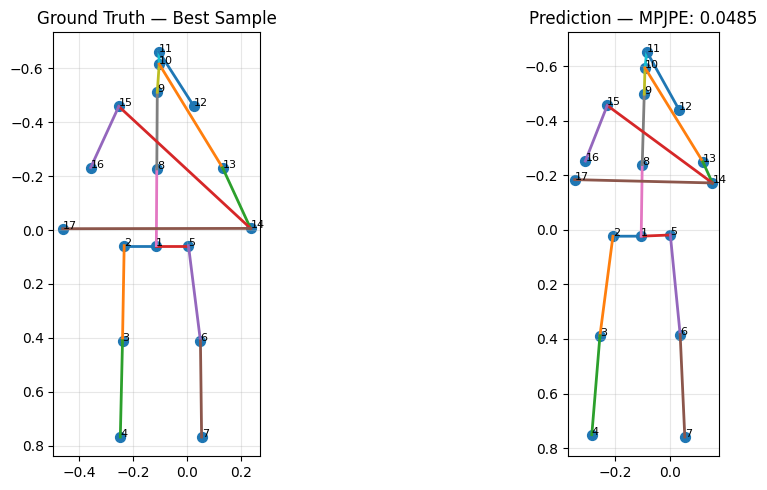

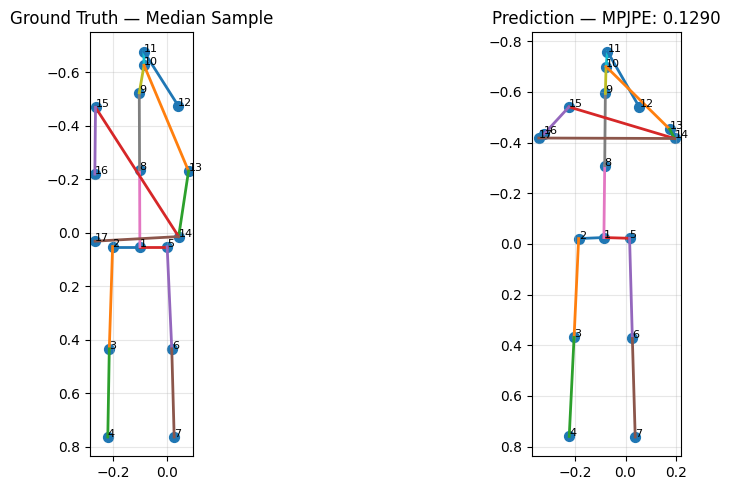

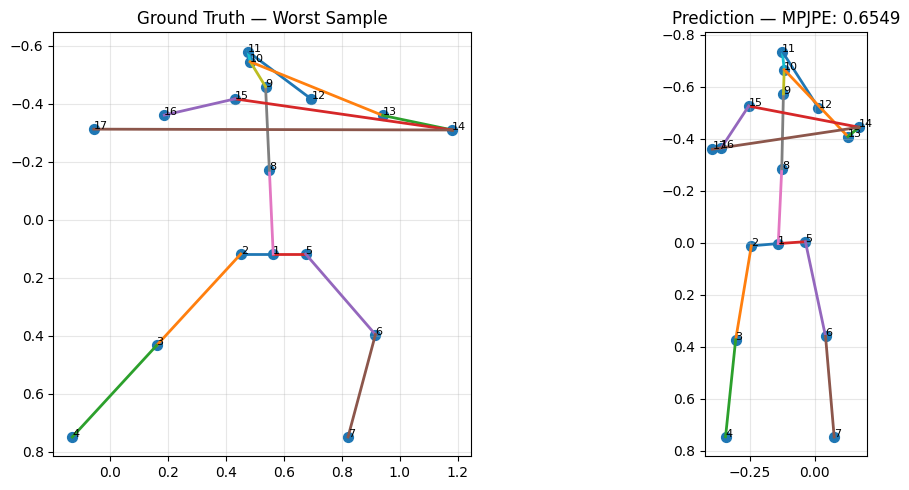

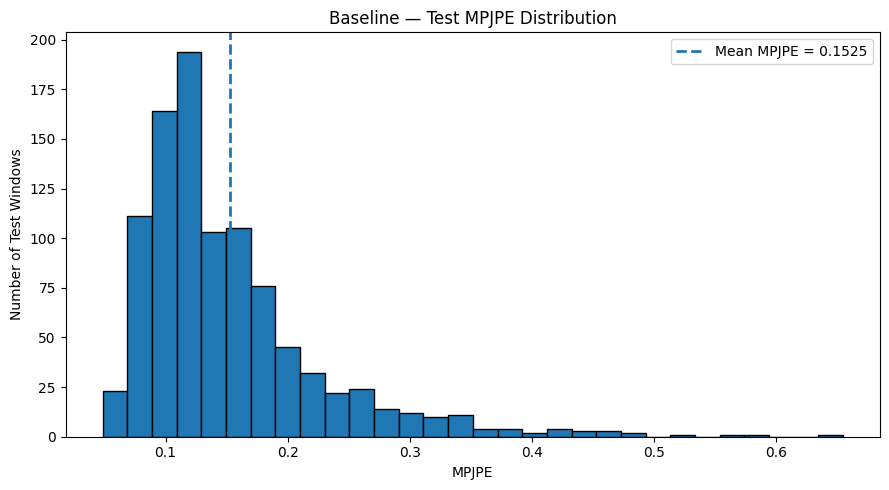

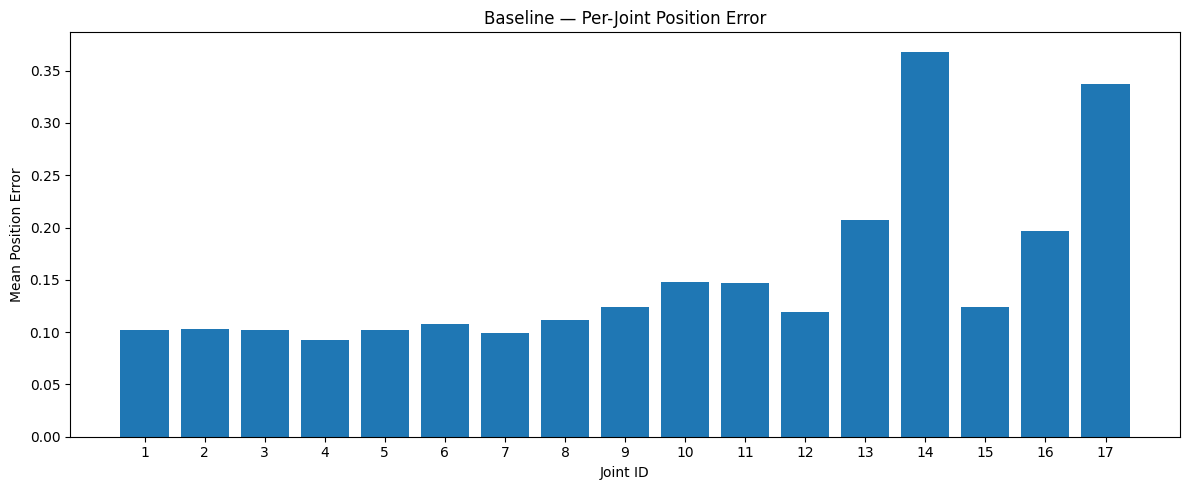


PER-JOINT ANALYSIS
Joint 01: 0.102118
Joint 02: 0.102693
Joint 03: 0.102164
Joint 04: 0.092034
Joint 05: 0.101706
Joint 06: 0.107729
Joint 07: 0.099609
Joint 08: 0.111128
Joint 09: 0.124490
Joint 10: 0.148148
Joint 11: 0.147076
Joint 12: 0.119646
Joint 13: 0.207426
Joint 14: 0.368198
Joint 15: 0.123915
Joint 16: 0.196941
Joint 17: 0.337359

Lowest-error joint : 4 (0.092034)
Highest-error joint: 14 (0.368198)

ANALYSIS COMPLETE
Saved: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\baseline\baseline_analysis.npz


In [24]:
# ============================================================
# BASELINE — POSE VISUALIZATION & ERROR ANALYSIS
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# LOAD SAVED RESULTS
# ============================================================

BASELINE_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

predictions = np.load(
    os.path.join(
        BASELINE_DIR,
        "baseline_predictions.npy"
    )
)

targets = np.load(
    os.path.join(
        BASELINE_DIR,
        "baseline_targets.npy"
    )
)

errors = np.load(
    os.path.join(
        BASELINE_DIR,
        "baseline_errors.npy"
    )
)


print("=" * 60)
print("BASELINE RESULTS LOADED")
print("=" * 60)

print("Predictions:", predictions.shape)
print("Targets    :", targets.shape)
print("Errors     :", errors.shape)


# ============================================================
# ERROR CALCULATIONS
# ============================================================

sample_errors = errors.mean(axis=1)

per_joint_error = errors.mean(axis=0)

overall_mpjpe = sample_errors.mean()


best_idx = np.argmin(sample_errors)

median_idx = np.argsort(
    sample_errors
)[len(sample_errors) // 2]

worst_idx = np.argmax(sample_errors)


print()
print("=" * 60)
print("ERROR SUMMARY")
print("=" * 60)

print(f"Overall MPJPE : {overall_mpjpe:.6f}")

print(f"Best sample   : {sample_errors[best_idx]:.6f}")
print(f"Median sample : {sample_errors[median_idx]:.6f}")
print(f"Worst sample  : {sample_errors[worst_idx]:.6f}")

print()
print("Best index  :", best_idx)
print("Median index:", median_idx)
print("Worst index :", worst_idx)


# ============================================================
# SKELETON CONNECTIONS
#
# IMPORTANT:
# These are provisional connections for visualization.
# The joint topology must later be verified against
# the MMFi pose joint ordering.
# ============================================================

connections = [

    (0, 1),
    (1, 2),
    (2, 3),

    (0, 4),
    (4, 5),
    (5, 6),

    (0, 7),
    (7, 8),
    (8, 9),

    (9, 10),
    (10, 11),

    (9, 12),
    (12, 13),

    (13, 14),
    (14, 15),

    (13, 16)

]


# ============================================================
# POSE DRAWING FUNCTION
# ============================================================

def plot_pose(pose, title, ax):

    ax.scatter(
        pose[:, 0],
        pose[:, 1],
        s=50
    )

    for i, (x, y) in enumerate(pose):

        ax.text(
            x,
            y,
            str(i + 1),
            fontsize=8
        )

    for a, b in connections:

        ax.plot(
            [
                pose[a, 0],
                pose[b, 0]
            ],
            [
                pose[a, 1],
                pose[b, 1]
            ],
            linewidth=2
        )

    ax.set_title(title)

    ax.set_aspect("equal")

    ax.invert_yaxis()

    ax.grid(alpha=0.3)


# ============================================================
# BEST SAMPLE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

plot_pose(
    targets[best_idx],
    "Ground Truth — Best Sample",
    axes[0]
)

plot_pose(
    predictions[best_idx],
    f"Prediction — MPJPE: {sample_errors[best_idx]:.4f}",
    axes[1]
)

plt.tight_layout()
plt.show()


# ============================================================
# MEDIAN SAMPLE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

plot_pose(
    targets[median_idx],
    "Ground Truth — Median Sample",
    axes[0]
)

plot_pose(
    predictions[median_idx],
    f"Prediction — MPJPE: {sample_errors[median_idx]:.4f}",
    axes[1]
)

plt.tight_layout()
plt.show()


# ============================================================
# WORST SAMPLE
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

plot_pose(
    targets[worst_idx],
    "Ground Truth — Worst Sample",
    axes[0]
)

plot_pose(
    predictions[worst_idx],
    f"Prediction — MPJPE: {sample_errors[worst_idx]:.4f}",
    axes[1]
)

plt.tight_layout()
plt.show()


# ============================================================
# ERROR DISTRIBUTION
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    sample_errors,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    overall_mpjpe,
    linestyle="--",
    linewidth=2,
    label=f"Mean MPJPE = {overall_mpjpe:.4f}"
)

plt.title(
    "Baseline — Test MPJPE Distribution"
)

plt.xlabel("MPJPE")

plt.ylabel("Number of Test Windows")

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# PER-JOINT ERROR
# ============================================================

joint_ids = np.arange(1, 18)

plt.figure(figsize=(12, 5))

plt.bar(
    joint_ids,
    per_joint_error
)

plt.xticks(joint_ids)

plt.xlabel("Joint ID")

plt.ylabel("Mean Position Error")

plt.title(
    "Baseline — Per-Joint Position Error"
)

plt.tight_layout()
plt.show()


# ============================================================
# BEST AND WORST JOINTS
# ============================================================

best_joint = np.argmin(
    per_joint_error
) + 1

worst_joint = np.argmax(
    per_joint_error
) + 1


print()
print("=" * 60)
print("PER-JOINT ANALYSIS")
print("=" * 60)

for i, error in enumerate(
    per_joint_error,
    start=1
):

    print(
        f"Joint {i:02d}: "
        f"{error:.6f}"
    )


print()
print(
    f"Lowest-error joint : "
    f"{best_joint} "
    f"({per_joint_error[best_joint - 1]:.6f})"
)

print(
    f"Highest-error joint: "
    f"{worst_joint} "
    f"({per_joint_error[worst_joint - 1]:.6f})"
)


# ============================================================
# SAVE SUMMARY
# ============================================================

summary_path = os.path.join(
    BASELINE_DIR,
    "baseline_analysis.npz"
)

np.savez(
    summary_path,
    sample_errors=sample_errors,
    per_joint_error=per_joint_error,
    overall_mpjpe=overall_mpjpe,
    best_index=best_idx,
    median_index=median_idx,
    worst_index=worst_idx
)

print()
print("=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

print(
    "Saved:",
    summary_path
)

In [25]:
# ============================================================
# FIND ALL MODEL CHECKPOINTS
# ============================================================

import os
import torch

MODELS_DIR = os.path.join(ROOT, "models")

print("=" * 70)
print("CHECKPOINT INSPECTION")
print("=" * 70)

for filename in sorted(os.listdir(MODELS_DIR)):

    if not filename.endswith(".pt"):
        continue

    path = os.path.join(MODELS_DIR, filename)

    print()
    print("-" * 70)
    print("FILE:", filename)
    print("PATH:", path)

    try:
        checkpoint = torch.load(
            path,
            map_location="cpu",
            weights_only=False
        )

        if isinstance(checkpoint, dict):

            print("Keys:", list(checkpoint.keys()))

            if "epoch" in checkpoint:
                print("Epoch:", checkpoint["epoch"])

            if "val_loss" in checkpoint:
                print("Validation loss:", checkpoint["val_loss"])

            if "model_state_dict" in checkpoint:

                state_dict = checkpoint["model_state_dict"]

                print(
                    "State dict parameters:",
                    len(state_dict)
                )

                # Print first few architecture keys
                print("First parameters:")

                for i, (key, value) in enumerate(
                    state_dict.items()
                ):

                    if i >= 5:
                        break

                    print(
                        f"  {key}: "
                        f"{tuple(value.shape)}"
                    )

        else:

            print(
                "Checkpoint format:",
                type(checkpoint)
            )

    except Exception as e:

        print(
            "Could not inspect checkpoint:",
            e
        )


print()
print("=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)

CHECKPOINT INSPECTION

----------------------------------------------------------------------
FILE: baseline_best.pt
PATH: C:\Users\ROHITH KANNA S\WiFiVision\models\baseline_best.pt
Keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss']
Epoch: 11
Validation loss: 1.1045574332460946
State dict parameters: 22
First parameters:
  frame_cnn.features.0.weight: (16, 3, 3, 3)
  frame_cnn.features.0.bias: (16,)
  frame_cnn.features.1.weight: (16,)
  frame_cnn.features.1.bias: (16,)
  frame_cnn.features.1.running_mean: (16,)

----------------------------------------------------------------------
FILE: experiment_G_best.pt
PATH: C:\Users\ROHITH KANNA S\WiFiVision\models\experiment_G_best.pt
Keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'train_loss']
Epoch: 3
Validation loss: 1.327830545941498
State dict parameters: 47
First parameters:
  frame_encoder.features.0.weight: (32, 3, 3, 3)
  frame_encoder.features.0.bias: (32,)
  frame_encoder.features.1.weig

In [26]:
# ============================================================
# INSPECT TOPOLOGY GRAPH CHECKPOINT
# ============================================================

import torch
import os

checkpoint_path = os.path.join(
    ROOT,
    "models",
    "topology_graph_best.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False
)

state_dict = checkpoint["model_state_dict"]

print("=" * 70)
print("TOPOLOGY GRAPH CHECKPOINT")
print("=" * 70)

print("Epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])

print()
print("ALL PARAMETERS")
print("-" * 70)

for key, value in state_dict.items():

    print(
        f"{key:<55}",
        tuple(value.shape)
    )

print()
print("=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)

TOPOLOGY GRAPH CHECKPOINT
Epoch: 2
Validation loss: 1.1400491405171131

ALL PARAMETERS
----------------------------------------------------------------------
joint_embedding                                         (17, 32)
frame_cnn.features.0.weight                             (16, 3, 3, 3)
frame_cnn.features.0.bias                               (16,)
frame_cnn.features.1.weight                             (16,)
frame_cnn.features.1.bias                               (16,)
frame_cnn.features.1.running_mean                       (16,)
frame_cnn.features.1.running_var                        (16,)
frame_cnn.features.1.num_batches_tracked                ()
frame_cnn.features.4.weight                             (32, 16, 3, 3)
frame_cnn.features.4.bias                               (32,)
frame_cnn.features.5.weight                             (32,)
frame_cnn.features.5.bias                               (32,)
frame_cnn.features.5.running_mean                       (32,)
frame_cnn.features.

In [28]:
# ============================================================
# EXPERIMENT H — TOPOLOGY GRAPH
# COMPLETE CORRECTED TEST EVALUATION
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. DEVICE
# ============================================================

DEVICE = torch.device("cpu")

print("Device:", DEVICE)


# ============================================================
# 2. TEST DATASET
# ============================================================

class TopologyTestDataset(Dataset):

    def __init__(
        self,
        amplitude,
        pose,
        sequence_indices,
        pose_mean,
        pose_std,
        window=30,
        stride=15
    ):

        self.amplitude = amplitude
        self.pose = pose
        self.pose_mean = pose_mean
        self.pose_std = pose_std

        self.window = window
        self.stride = stride

        self.windows = []

        for seq in sequence_indices:

            for start in range(
                0,
                amplitude.shape[1] - window + 1,
                stride
            ):

                self.windows.append(
                    (
                        int(seq),
                        int(start)
                    )
                )


    def __len__(self):

        return len(self.windows)


    def __getitem__(self, index):

        seq, start = self.windows[index]

        end = start + self.window


        # ----------------------------------------------------
        # INPUT
        #
        # (30, 3, 114, 10)
        # ----------------------------------------------------

        x = np.asarray(
            self.amplitude[
                seq,
                start:end
            ],
            dtype=np.float32
        )


        # ----------------------------------------------------
        # TARGET
        #
        # Last frame of window
        # ----------------------------------------------------

        target_frame = end - 1

        y = np.asarray(
            self.pose[
                seq,
                target_frame
            ],
            dtype=np.float32
        )


        # ----------------------------------------------------
        # NORMALIZE TARGET
        #
        # Must match training
        # ----------------------------------------------------

        y = (
            y - self.pose_mean
        ) / self.pose_std


        return (
            torch.from_numpy(
                x.copy()
            ),
            torch.from_numpy(
                y.copy()
            )
        )


# ============================================================
# 3. CREATE TEST DATASET
# ============================================================

graph_test_dataset = TopologyTestDataset(

    amplitude=amplitude,
    pose=pose,
    sequence_indices=test_seq,
    pose_mean=pose_mean,
    pose_std=pose_std,
    window=WINDOW,
    stride=STRIDE
)


graph_test_loader = DataLoader(

    graph_test_dataset,

    batch_size=8,

    shuffle=False,

    num_workers=0
)


print()
print("=" * 70)
print("TOPOLOGY GRAPH TEST DATASET")
print("=" * 70)

print(
    "Test windows:",
    len(graph_test_dataset)
)

sample_x, sample_y = graph_test_dataset[0]

print(
    "Input shape:",
    tuple(sample_x.shape)
)

print(
    "Target shape:",
    tuple(sample_y.shape)
)


# ============================================================
# 4. FRAME CNN
# ============================================================

class GraphFrameCNN(nn.Module):

    def __init__(self):

        super().__init__()


        self.features = nn.Sequential(

            # ------------------------------------------------
            # BLOCK 1
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(16),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ------------------------------------------------
            # BLOCK 2
            # ------------------------------------------------

            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            nn.MaxPool2d(
                kernel_size=2
            ),


            # ------------------------------------------------
            # GLOBAL POOLING
            # ------------------------------------------------

            nn.AdaptiveAvgPool2d(
                (1, 1)
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = x.flatten(1)

        return x


# ============================================================
# 5. GRAPH CONVOLUTION
# ============================================================

class GraphConvolution(nn.Module):

    def __init__(
        self,
        in_features,
        out_features
    ):

        super().__init__()


        self.linear = nn.Linear(
            in_features,
            out_features
        )


    def forward(
        self,
        x,
        adjacency
    ):

        # x:
        #
        # (B, 17, C)

        x = torch.matmul(
            adjacency,
            x
        )

        x = self.linear(x)

        return x


# ============================================================
# 6. BUILD SKELETON ADJACENCY
# ============================================================

def build_adjacency():

    NUM_JOINTS = 17


    # --------------------------------------------------------
    # SELF CONNECTIONS
    # --------------------------------------------------------

    adjacency = torch.eye(
        NUM_JOINTS,
        dtype=torch.float32
    )


    # --------------------------------------------------------
    # COCO-STYLE 17 JOINT SKELETON
    # --------------------------------------------------------

    edges = [

        # Face

        (0, 1),
        (0, 2),

        (1, 3),
        (2, 4),


        # Shoulders

        (5, 6),


        # Left arm

        (5, 7),
        (7, 9),


        # Right arm

        (6, 8),
        (8, 10),


        # Torso

        (5, 11),
        (6, 12),
        (11, 12),


        # Left leg

        (11, 13),
        (13, 15),


        # Right leg

        (12, 14),
        (14, 16)
    ]


    # --------------------------------------------------------
    # ADD BIDIRECTIONAL EDGES
    # --------------------------------------------------------

    for i, j in edges:

        adjacency[i, j] = 1.0

        adjacency[j, i] = 1.0


    # --------------------------------------------------------
    # SYMMETRIC DEGREE NORMALIZATION
    #
    # D^(-1/2) A D^(-1/2)
    # --------------------------------------------------------

    degree = adjacency.sum(
        dim=1
    )


    degree_inv_sqrt = torch.pow(
        degree,
        -0.5
    )


    degree_inv_sqrt[
        torch.isinf(
            degree_inv_sqrt
        )
    ] = 0.0


    degree_matrix = torch.diag(
        degree_inv_sqrt
    )


    adjacency = (

        degree_matrix
        @ adjacency
        @ degree_matrix

    )


    return adjacency


# ============================================================
# 7. TOPOLOGY GRAPH MODEL
# ============================================================

class TopologyGraphPose(nn.Module):

    def __init__(self):

        super().__init__()


        # ----------------------------------------------------
        # JOINT EMBEDDING
        #
        # Checkpoint:
        # (17, 32)
        # ----------------------------------------------------

        self.joint_embedding = nn.Parameter(

            torch.randn(
                17,
                32
            )

        )


        # ----------------------------------------------------
        # FRAME CNN
        # ----------------------------------------------------

        self.frame_cnn = GraphFrameCNN()


        # ----------------------------------------------------
        # TEMPORAL GRU
        #
        # Checkpoint:
        #
        # input_size = 32
        # hidden_size = 64
        # ----------------------------------------------------

        self.gru = nn.GRU(

            input_size=32,

            hidden_size=64,

            num_layers=1,

            batch_first=True
        )


        # ----------------------------------------------------
        # GLOBAL FEATURE
        #
        # 64 → 17 × 32
        #
        # Checkpoint:
        # joint_projection.weight = (544, 64)
        # ----------------------------------------------------

        self.joint_projection = nn.Linear(

            64,

            17 * 32
        )


        # ----------------------------------------------------
        # GRAPH LAYERS
        # ----------------------------------------------------

        self.gcn1 = GraphConvolution(
            32,
            32
        )


        self.gcn2 = GraphConvolution(
            32,
            32
        )


        # ----------------------------------------------------
        # JOINT SELF ATTENTION
        # ----------------------------------------------------

        self.attention = nn.MultiheadAttention(

            embed_dim=32,

            num_heads=4,

            batch_first=True
        )


        # ----------------------------------------------------
        # NORMALIZATION
        # ----------------------------------------------------

        self.norm1 = nn.LayerNorm(
            32
        )

        self.norm2 = nn.LayerNorm(
            32
        )

        self.norm3 = nn.LayerNorm(
            32
        )


        # ----------------------------------------------------
        # FINAL HEAD
        # ----------------------------------------------------

        self.head = nn.Sequential(

            nn.Linear(
                32,
                32
            ),

            nn.ReLU(),

            nn.Linear(
                32,
                2
            )
        )


        # ----------------------------------------------------
        # ADJACENCY
        #
        # The checkpoint does NOT contain this buffer.
        # It is reconstructed deterministically.
        # ----------------------------------------------------

        adjacency = build_adjacency()

        self.register_buffer(
            "adjacency",
            adjacency
        )


    def forward(self, x):


        # ----------------------------------------------------
        # INPUT
        #
        # (B, 30, 3, 114, 10)
        # ----------------------------------------------------

        batch_size = x.shape[0]

        sequence_length = x.shape[1]


        # ----------------------------------------------------
        # PROCESS EVERY CSI FRAME
        # ----------------------------------------------------

        x = x.reshape(

            batch_size * sequence_length,

            3,

            114,

            10
        )


        x = self.frame_cnn(x)


        # ----------------------------------------------------
        # RESTORE TEMPORAL DIMENSION
        #
        # (B, 30, 32)
        # ----------------------------------------------------

        x = x.reshape(

            batch_size,

            sequence_length,

            32
        )


        # ----------------------------------------------------
        # GRU
        # ----------------------------------------------------

        x, _ = self.gru(x)


        # Use final temporal state

        x = x[:, -1, :]


        # ----------------------------------------------------
        # JOINT PROJECTION
        #
        # (B, 64)
        #
        # →
        #
        # (B, 17, 32)
        # ----------------------------------------------------

        x = self.joint_projection(x)


        x = x.reshape(

            batch_size,

            17,

            32
        )


        # Add learnable joint identity

        x = (

            x

            +

            self.joint_embedding.unsqueeze(0)

        )


        # ----------------------------------------------------
        # GCN 1
        # ----------------------------------------------------

        residual = x


        x = self.gcn1(

            x,

            self.adjacency
        )


        x = torch.relu(x)


        x = self.norm1(

            x + residual
        )


        # ----------------------------------------------------
        # GCN 2
        # ----------------------------------------------------

        residual = x


        x = self.gcn2(

            x,

            self.adjacency
        )


        x = torch.relu(x)


        x = self.norm2(

            x + residual
        )


        # ----------------------------------------------------
        # SELF ATTENTION
        # ----------------------------------------------------

        residual = x


        attention_output, _ = self.attention(

            x,

            x,

            x
        )


        x = self.norm3(

            attention_output + residual
        )


        # ----------------------------------------------------
        # FINAL JOINT COORDINATES
        #
        # (B, 17, 2)
        # ----------------------------------------------------

        x = self.head(x)


        return x


# ============================================================
# 8. CREATE MODEL
# ============================================================

graph_model = TopologyGraphPose().to(
    DEVICE
)


parameters = sum(

    p.numel()

    for p in graph_model.parameters()

)


print()
print("=" * 70)
print("TOPOLOGY GRAPH MODEL")
print("=" * 70)

print(
    "Parameters:",
    parameters
)


# ============================================================
# 9. LOAD CHECKPOINT
# ============================================================

checkpoint_path = os.path.join(

    ROOT,

    "models",

    "topology_graph_best.pt"
)


checkpoint = torch.load(

    checkpoint_path,

    map_location=DEVICE,

    weights_only=False
)


# ------------------------------------------------------------
# IMPORTANT:
#
# strict=False is required because the checkpoint does not
# contain the reconstructed "adjacency" buffer.
# ------------------------------------------------------------

missing_keys, unexpected_keys = graph_model.load_state_dict(

    checkpoint["model_state_dict"],

    strict=False
)


print()
print("=" * 70)
print("CHECKPOINT LOADING")
print("=" * 70)

print(
    "Checkpoint:",
    checkpoint_path
)

print(
    "Best epoch:",
    checkpoint["epoch"]
)

print(
    "Validation loss:",
    checkpoint["val_loss"]
)

print()
print(
    "Missing keys:",
    missing_keys
)

print(
    "Unexpected keys:",
    unexpected_keys
)


# ------------------------------------------------------------
# SAFETY CHECK
# ------------------------------------------------------------

allowed_missing = ["adjacency"]


if missing_keys != allowed_missing:

    raise RuntimeError(

        f"Unexpected missing keys: {missing_keys}"
    )


if len(unexpected_keys) > 0:

    raise RuntimeError(

        f"Unexpected checkpoint keys: "
        f"{unexpected_keys}"
    )


print()
print(
    "Checkpoint compatibility: PASSED"
)


graph_model.eval()


# ============================================================
# 10. SHAPE VALIDATION
# ============================================================

with torch.no_grad():

    test_input = torch.randn(

        4,

        WINDOW,

        3,

        114,

        10

    ).to(DEVICE)


    test_output = graph_model(
        test_input
    )


print()
print("=" * 70)
print("SHAPE VALIDATION")
print("=" * 70)

print(
    "Input :",
    tuple(test_input.shape)
)

print(
    "Output:",
    tuple(test_output.shape)
)


assert tuple(test_output.shape) == (

    4,

    17,

    2
)


print()
print(
    "Shape validation: PASSED"
)


# ============================================================
# 11. GENERATE TEST PREDICTIONS
# ============================================================

predictions = []

targets = []


print()
print("=" * 70)
print("GENERATING TEST PREDICTIONS")
print("=" * 70)


with torch.no_grad():

    for x, y in graph_test_loader:


        x = x.to(
            DEVICE
        )


        prediction = graph_model(
            x
        )


        predictions.append(

            prediction.cpu().numpy()
        )


        targets.append(

            y.numpy()
        )


# ============================================================
# 12. COMBINE BATCHES
# ============================================================

predictions = np.concatenate(

    predictions,

    axis=0
)


targets = np.concatenate(

    targets,

    axis=0
)


print()
print(
    "Predictions:",
    predictions.shape
)

print(
    "Targets    :",
    targets.shape
)


# ============================================================
# 13. DENORMALIZE
# ============================================================

predictions = (

    predictions * pose_std

    +

    pose_mean
)


targets = (

    targets * pose_std

    +

    pose_mean
)


print()
print(
    "Predictions denormalized."
)

print(
    "Targets denormalized."
)


# ============================================================
# 14. CALCULATE PER-JOINT ERRORS
# ============================================================

errors = np.linalg.norm(

    predictions - targets,

    axis=-1
)


# Shape:
#
# (972, 17)


mpjpe = errors.mean()


# ============================================================
# 15. PCK
# ============================================================

thresholds = [

    0.05,

    0.10,

    0.15,

    0.20
]


# ============================================================
# 16. FINAL RESULTS
# ============================================================

print()
print("=" * 70)
print("TOPOLOGY GRAPH — FINAL TEST EVALUATION")
print("=" * 70)

print()
print(
    f"MPJPE: {mpjpe:.6f}"
)


print()
print("PCK:")


for threshold in thresholds:

    pck = (

        errors < threshold

    ).mean() * 100


    print(

        f"@ {threshold:.2f}: "

        f"{pck:.2f}%"
    )


# ============================================================
# 17. PER-JOINT ERROR
# ============================================================

per_joint_error = errors.mean(
    axis=0
)


print()
print("Per-joint error:")


for joint, error in enumerate(

    per_joint_error,

    start=1
):

    print(

        f"Joint {joint:02d}: "

        f"{error:.6f}"
    )


# ============================================================
# 18. SAVE RESULTS
# ============================================================

results_dir = os.path.join(

    ROOT,

    "data",

    "processed",

    "topology_graph"
)


os.makedirs(

    results_dir,

    exist_ok=True
)


np.save(

    os.path.join(

        results_dir,

        "predictions.npy"
    ),

    predictions
)


np.save(

    os.path.join(

        results_dir,

        "targets.npy"
    ),

    targets
)


np.save(

    os.path.join(

        results_dir,

        "errors.npy"
    ),

    errors
)


np.save(

    os.path.join(

        results_dir,

        "per_joint_error.npy"
    ),

    per_joint_error
)


# ============================================================
# 19. COMPARISON WITH REPRODUCIBLE BASELINE
# ============================================================

baseline_mpjpe = 0.152493


change = (

    (mpjpe - baseline_mpjpe)

    /

    baseline_mpjpe

) * 100


print()
print("=" * 70)
print("FINAL COMPARISON")
print("=" * 70)

print()

print(

    f"Baseline MPJPE      : "

    f"{baseline_mpjpe:.6f}"
)


print(

    f"Topology Graph MPJPE: "

    f"{mpjpe:.6f}"
)


print()

print(

    f"Change vs baseline: "

    f"{change:+.2f}%"
)


print()


if mpjpe < baseline_mpjpe:

    print(

        "RESULT: TOPOLOGY GRAPH "
        "IMPROVED over the reproducible baseline."
    )

else:

    print(

        "RESULT: TOPOLOGY GRAPH "
        "did NOT improve over the reproducible baseline."
    )


# ============================================================
# 20. SAVE SUMMARY
# ============================================================

summary_path = os.path.join(

    results_dir,

    "results.txt"
)


with open(

    summary_path,

    "w"

) as f:


    f.write(
        "TOPOLOGY GRAPH RESULTS\n"
    )


    f.write(
        "=" * 50 + "\n\n"
    )


    f.write(
        f"MPJPE: {mpjpe:.6f}\n"
    )


    f.write(
        f"Baseline MPJPE: "
        f"{baseline_mpjpe:.6f}\n"
    )


    f.write(
        f"Change vs baseline: "
        f"{change:+.2f}%\n\n"
    )


    for threshold in thresholds:

        pck = (

            errors < threshold

        ).mean() * 100


        f.write(

            f"PCK@{threshold:.2f}: "

            f"{pck:.2f}%\n"
        )


print()
print("=" * 70)
print("EVALUATION COMPLETE")
print("=" * 70)

print()

print(
    "Results saved to:"
)

print(
    results_dir
)

Device: cpu

TOPOLOGY GRAPH TEST DATASET
Test windows: 972
Input shape: (30, 3, 114, 10)
Target shape: (17, 2)

TOPOLOGY GRAPH MODEL
Parameters: 67554

CHECKPOINT LOADING
Checkpoint: C:\Users\ROHITH KANNA S\WiFiVision\models\topology_graph_best.pt
Best epoch: 2
Validation loss: 1.1400491405171131

Missing keys: ['adjacency']
Unexpected keys: []

Checkpoint compatibility: PASSED

SHAPE VALIDATION
Input : (4, 30, 3, 114, 10)
Output: (4, 17, 2)

Shape validation: PASSED

GENERATING TEST PREDICTIONS

Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

Predictions denormalized.
Targets denormalized.

TOPOLOGY GRAPH — FINAL TEST EVALUATION

MPJPE: 0.138569

PCK:
@ 0.05: 27.08%
@ 0.10: 55.42%
@ 0.15: 69.21%
@ 0.20: 78.09%

Per-joint error:
Joint 01: 0.089723
Joint 02: 0.090741
Joint 03: 0.087598
Joint 04: 0.081320
Joint 05: 0.089460
Joint 06: 0.089562
Joint 07: 0.084970
Joint 08: 0.098195
Joint 09: 0.115101
Joint 10: 0.141703
Joint 11: 0.138345
Joint 12: 0.108900
Joint 13: 0.188275
Joint 14:

In [30]:
# ============================================================
# TOPOLOGY GRAPH — SUBJECT-WISE EVALUATION
# ============================================================

import os
import numpy as np


# ============================================================
# 1. CONFIGURATION
# ============================================================

TEST_SUBJECTS = np.array([9, 10])

RESULT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)


# ============================================================
# 2. LOAD SAVED RESULTS
# ============================================================

predictions = np.load(
    os.path.join(
        RESULT_DIR,
        "predictions.npy"
    )
).astype(np.float32)

targets = np.load(
    os.path.join(
        RESULT_DIR,
        "targets.npy"
    )
).astype(np.float32)


print("=" * 70)
print("TOPOLOGY GRAPH — SUBJECT-WISE EVALUATION")
print("=" * 70)

print()
print("Predictions:", predictions.shape)
print("Targets    :", targets.shape)


# ============================================================
# 3. VALIDATE TEST SPLIT
# ============================================================

TOTAL_WINDOWS = predictions.shape[0]
NUM_SUBJECTS = len(TEST_SUBJECTS)

if TOTAL_WINDOWS != targets.shape[0]:
    raise ValueError(
        "Prediction and target counts do not match."
    )

if TOTAL_WINDOWS % NUM_SUBJECTS != 0:
    raise ValueError(
        f"Cannot evenly split {TOTAL_WINDOWS} windows "
        f"across {NUM_SUBJECTS} subjects."
    )

WINDOWS_PER_SUBJECT = (
    TOTAL_WINDOWS // NUM_SUBJECTS
)


print()
print("=" * 70)
print("TEST SPLIT")
print("=" * 70)

print("Test subjects      :", TEST_SUBJECTS)
print("Total windows      :", TOTAL_WINDOWS)
print("Subjects           :", NUM_SUBJECTS)
print("Windows per subject:", WINDOWS_PER_SUBJECT)

assert TOTAL_WINDOWS == 972
assert WINDOWS_PER_SUBJECT == 486

print()
print("Split validation: PASSED")


# ============================================================
# 4. SUBJECT-WISE EVALUATION
# ============================================================

subject_results = []

for i, subject in enumerate(TEST_SUBJECTS):

    start = i * WINDOWS_PER_SUBJECT
    end = start + WINDOWS_PER_SUBJECT


    # --------------------------------------------------------
    # SUBJECT DATA
    # --------------------------------------------------------

    subject_predictions = predictions[
        start:end
    ]

    subject_targets = targets[
        start:end
    ]


    # --------------------------------------------------------
    # EUCLIDEAN JOINT ERROR
    #
    # Shape:
    # (486, 17)
    # --------------------------------------------------------

    errors = np.linalg.norm(
        subject_predictions - subject_targets,
        axis=-1
    )


    # --------------------------------------------------------
    # MPJPE
    # --------------------------------------------------------

    mpjpe = errors.mean()


    # --------------------------------------------------------
    # PCK
    # --------------------------------------------------------

    pck_005 = (
        errors < 0.05
    ).mean() * 100

    pck_010 = (
        errors < 0.10
    ).mean() * 100

    pck_015 = (
        errors < 0.15
    ).mean() * 100

    pck_020 = (
        errors < 0.20
    ).mean() * 100


    # --------------------------------------------------------
    # PER-JOINT ERROR
    # --------------------------------------------------------

    per_joint_error = errors.mean(
        axis=0
    )


    subject_results.append(
        {
            "subject": int(subject),
            "windows": int(end - start),
            "mpjpe": float(mpjpe),
            "pck_005": float(pck_005),
            "pck_010": float(pck_010),
            "pck_015": float(pck_015),
            "pck_020": float(pck_020),
            "per_joint_error": per_joint_error
        }
    )


# ============================================================
# 5. PRINT SUBJECT-WISE RESULTS
# ============================================================

print()
print("=" * 70)
print("SUBJECT-WISE RESULTS")
print("=" * 70)


for result in subject_results:

    print()
    print("-" * 70)
    print(
        f"SUBJECT {result['subject']}"
    )
    print("-" * 70)

    print(
        "Windows:",
        result["windows"]
    )

    print(
        f"MPJPE: {result['mpjpe']:.6f}"
    )

    print()
    print("PCK:")

    print(
        f"@ 0.05: "
        f"{result['pck_005']:.2f}%"
    )

    print(
        f"@ 0.10: "
        f"{result['pck_010']:.2f}%"
    )

    print(
        f"@ 0.15: "
        f"{result['pck_015']:.2f}%"
    )

    print(
        f"@ 0.20: "
        f"{result['pck_020']:.2f}%"
    )


# ============================================================
# 6. OVERALL CONSISTENCY ANALYSIS
# ============================================================

subject_mpjpes = np.array(
    [
        result["mpjpe"]
        for result in subject_results
    ]
)


print()
print("=" * 70)
print("CONSISTENCY ANALYSIS")
print("=" * 70)

print()

print(
    f"Subject 9 MPJPE : "
    f"{subject_results[0]['mpjpe']:.6f}"
)

print(
    f"Subject 10 MPJPE: "
    f"{subject_results[1]['mpjpe']:.6f}"
)

print()

print(
    f"Mean subject MPJPE : "
    f"{subject_mpjpes.mean():.6f}"
)

print(
    f"Best subject MPJPE : "
    f"{subject_mpjpes.min():.6f}"
)

print(
    f"Worst subject MPJPE: "
    f"{subject_mpjpes.max():.6f}"
)

print(
    f"MPJPE std          : "
    f"{subject_mpjpes.std():.6f}"
)

print(
    f"Subject difference : "
    f"{np.ptp(subject_mpjpes):.6f}"
)


# ============================================================
# 7. OVERALL MPJPE VERIFICATION
# ============================================================

all_errors = np.linalg.norm(
    predictions - targets,
    axis=-1
)

overall_mpjpe = all_errors.mean()


print()
print("=" * 70)
print("OVERALL VERIFICATION")
print("=" * 70)

print()

print(
    f"Recomputed overall MPJPE: "
    f"{overall_mpjpe:.6f}"
)

print(
    "Expected MPJPE           : "
    "0.138569"
)

print()

if np.isclose(
    overall_mpjpe,
    0.138569,
    atol=1e-5
):
    print("Overall evaluation: VERIFIED")
else:
    print(
        "WARNING: MPJPE differs from the "
        "previously reported result."
    )


# ============================================================
# 8. SAVE RESULTS
# ============================================================

save_path = os.path.join(
    RESULT_DIR,
    "subject_wise_results.npz"
)

np.savez(
    save_path,

    subjects=np.array(
        [
            result["subject"]
            for result in subject_results
        ]
    ),

    windows=np.array(
        [
            result["windows"]
            for result in subject_results
        ]
    ),

    mpjpe=np.array(
        [
            result["mpjpe"]
            for result in subject_results
        ]
    ),

    pck_005=np.array(
        [
            result["pck_005"]
            for result in subject_results
        ]
    ),

    pck_010=np.array(
        [
            result["pck_010"]
            for result in subject_results
        ]
    ),

    pck_015=np.array(
        [
            result["pck_015"]
            for result in subject_results
        ]
    ),

    pck_020=np.array(
        [
            result["pck_020"]
            for result in subject_results
        ]
    ),

    per_joint_error=np.stack(
        [
            result["per_joint_error"]
            for result in subject_results
        ]
    )
)


print()
print("=" * 70)
print("EVALUATION COMPLETE")
print("=" * 70)

print()
print("Saved to:")
print(save_path)

TOPOLOGY GRAPH — SUBJECT-WISE EVALUATION

Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

TEST SPLIT
Test subjects      : [ 9 10]
Total windows      : 972
Subjects           : 2
Windows per subject: 486

Split validation: PASSED

SUBJECT-WISE RESULTS

----------------------------------------------------------------------
SUBJECT 9
----------------------------------------------------------------------
Windows: 486
MPJPE: 0.138242

PCK:
@ 0.05: 27.97%
@ 0.10: 58.45%
@ 0.15: 68.06%
@ 0.20: 75.91%

----------------------------------------------------------------------
SUBJECT 10
----------------------------------------------------------------------
Windows: 486
MPJPE: 0.138897

PCK:
@ 0.05: 26.18%
@ 0.10: 52.40%
@ 0.15: 70.37%
@ 0.20: 80.26%

CONSISTENCY ANALYSIS

Subject 9 MPJPE : 0.138242
Subject 10 MPJPE: 0.138897

Mean subject MPJPE : 0.138569
Best subject MPJPE : 0.138242
Worst subject MPJPE: 0.138897
MPJPE std          : 0.000328
Subject difference : 0.000655

OVERALL VERIFICATI

QUALITATIVE VISUALIZATION
Predictions: (972, 17, 2)
Targets    : (972, 17, 2)

Sample MPJPE:
Mean: 0.13856937
Min : 0.05398817
Max : 0.65470666

Selected samples:
Best Prediction: Index 255 | MPJPE 0.053988
Median Prediction: Index 301 | MPJPE 0.111812
Worst Prediction: Index 748 | MPJPE 0.654707


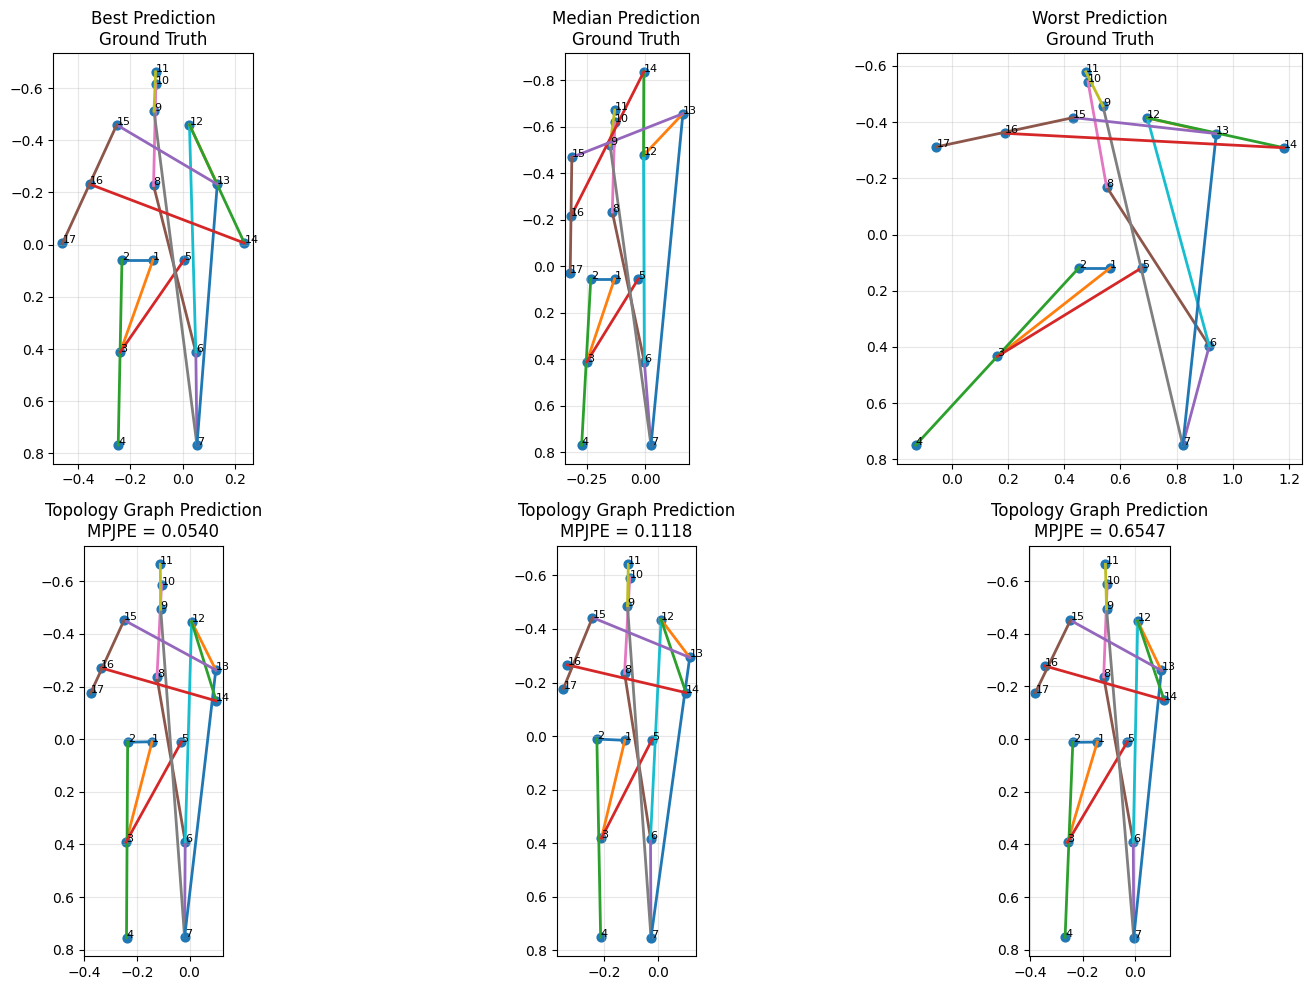


VISUALIZATION COMPLETE
Saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\qualitative_predictions.png


In [31]:
# ============================================================
# TOPOLOGY GRAPH — QUALITATIVE VISUALIZATION
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

RESULT_DIR = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)

PRED_PATH = os.path.join(
    RESULT_DIR,
    "predictions.npy"
)

TARGET_PATH = os.path.join(
    RESULT_DIR,
    "targets.npy"
)


# ============================================================
# LOAD RESULTS
# ============================================================

predictions = np.load(PRED_PATH)
targets = np.load(TARGET_PATH)

print("============================================================")
print("QUALITATIVE VISUALIZATION")
print("============================================================")

print("Predictions:", predictions.shape)
print("Targets    :", targets.shape)


# ============================================================
# COMPUTE SAMPLE ERRORS
# ============================================================

errors = np.linalg.norm(
    predictions - targets,
    axis=-1
)

sample_errors = errors.mean(axis=1)

print()
print("Sample MPJPE:")
print("Mean:", sample_errors.mean())
print("Min :", sample_errors.min())
print("Max :", sample_errors.max())


# ============================================================
# SELECT REPRESENTATIVE SAMPLES
# ============================================================

best_index = np.argmin(sample_errors)

median_index = np.argsort(
    sample_errors
)[len(sample_errors) // 2]

worst_index = np.argmax(sample_errors)


selected_indices = [
    best_index,
    median_index,
    worst_index
]

selected_names = [
    "Best Prediction",
    "Median Prediction",
    "Worst Prediction"
]


print()
print("Selected samples:")

for name, index in zip(
    selected_names,
    selected_indices
):

    print(
        f"{name}: "
        f"Index {index} | "
        f"MPJPE {sample_errors[index]:.6f}"
    )


# ============================================================
# SKELETON CONNECTIONS
#
# COCO-style 17 joint topology
# ============================================================

SKELETON = [

    (0, 1),
    (0, 2),

    (1, 3),
    (2, 4),

    (5, 6),

    (5, 7),
    (7, 9),

    (6, 8),
    (8, 10),

    (5, 11),
    (6, 12),

    (11, 12),

    (11, 13),
    (13, 15),

    (12, 14),
    (14, 16)

]


# ============================================================
# DRAW FUNCTION
# ============================================================

def draw_pose(
    ax,
    pose,
    title,
    invert_y=True
):

    # Draw skeleton

    for joint_a, joint_b in SKELETON:

        x_values = [
            pose[joint_a, 0],
            pose[joint_b, 0]
        ]

        y_values = [
            pose[joint_a, 1],
            pose[joint_b, 1]
        ]

        ax.plot(
            x_values,
            y_values,
            linewidth=2
        )


    # Draw joints

    ax.scatter(
        pose[:, 0],
        pose[:, 1],
        s=40
    )


    # Joint numbers

    for joint_index, (
        x,
        y
    ) in enumerate(pose):

        ax.text(
            x,
            y,
            str(joint_index + 1),
            fontsize=8
        )


    ax.set_title(
        title
    )

    ax.set_aspect(
        "equal"
    )

    ax.grid(
        True,
        alpha=0.3
    )


    if invert_y:

        ax.invert_yaxis()


# ============================================================
# CREATE VISUALIZATION
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)


for column, (
    index,
    name
) in enumerate(
    zip(
        selected_indices,
        selected_names
    )
):

    gt_pose = targets[index]

    pred_pose = predictions[index]

    error = sample_errors[index]


    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    draw_pose(
        axes[0, column],
        gt_pose,
        f"{name}\nGround Truth"
    )


    # --------------------------------------------------------
    # Prediction
    # --------------------------------------------------------

    draw_pose(
        axes[1, column],
        pred_pose,
        f"Topology Graph Prediction\nMPJPE = {error:.4f}"
    )


plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

save_path = os.path.join(
    RESULT_DIR,
    "qualitative_predictions.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print()
print("============================================================")
print("VISUALIZATION COMPLETE")
print("============================================================")

print(
    "Saved to:"
)

print(
    save_path
)

In [34]:
# ============================================================
# INSPECT TOPOLOGY GRAPH RESULTS FOLDER
# ============================================================

import os

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)

print("=" * 70)
print("TOPOLOGY GRAPH RESULTS")
print("=" * 70)

print("\nFolder:")
print(graph_dir)

print("\nFiles:\n")

for root, dirs, files in os.walk(graph_dir):
    for file in files:
        full_path = os.path.join(root, file)
        print(full_path)

print("\n" + "=" * 70)
print("INSPECTION COMPLETE")
print("=" * 70)

TOPOLOGY GRAPH RESULTS

Folder:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph

Files:

C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\errors.npy
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\per_joint_error.npy
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\predictions.npy
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\qualitative_predictions.png
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\results.txt
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\subject_wise_results.npz
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\targets.npy

INSPECTION COMPLETE


BASELINE vs TOPOLOGY GRAPH
ERROR DISTRIBUTION ANALYSIS

Baseline errors shape: (972, 17)
Topology Graph errors shape: (972, 17)

SUMMARY STATISTICS

Baseline mean MPJPE       : 0.152493
Topology Graph mean MPJPE : 0.138569

Baseline median MPJPE     : 0.128932
Topology Graph median     : 0.111789

Baseline standard deviation: 0.076617
Topology Graph std         : 0.079728

WINDOW-WISE COMPARISON

Improved windows : 694/972 (71.40%)
Worsened windows : 278/972 (28.60%)
Equal windows    : 0/972

Mean improvement : 0.013924

MPJPE PERCENTILES

P25 | Baseline: 0.104949 | Topology Graph: 0.090109 | Difference: 0.014839
P50 | Baseline: 0.128932 | Topology Graph: 0.111789 | Difference: 0.017143
P75 | Baseline: 0.177296 | Topology Graph: 0.153306 | Difference: 0.023990
P90 | Baseline: 0.247848 | Topology Graph: 0.241658 | Difference: 0.006190
P95 | Baseline: 0.302773 | Topology Graph: 0.316559 | Difference: -0.013786


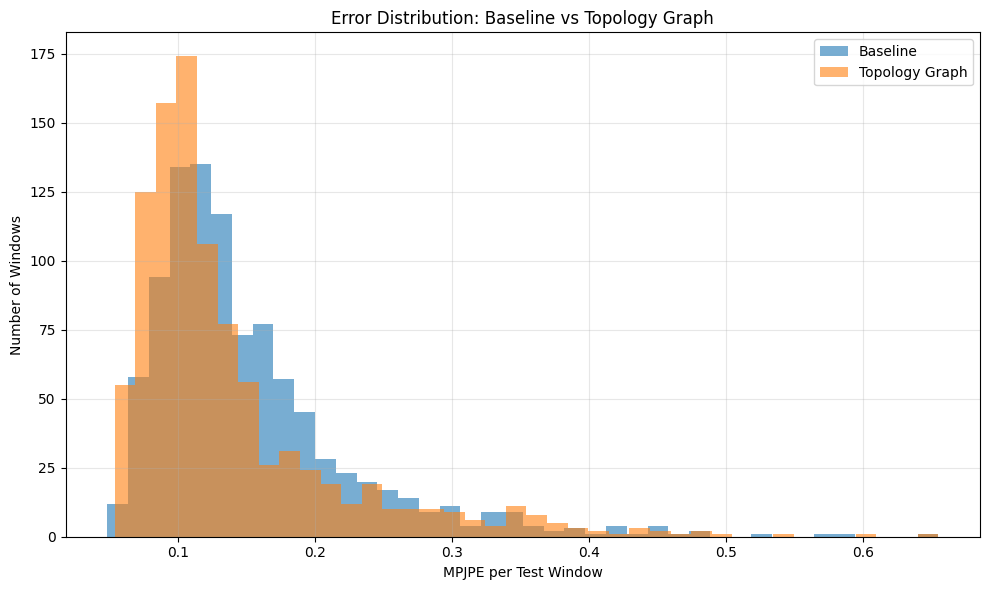

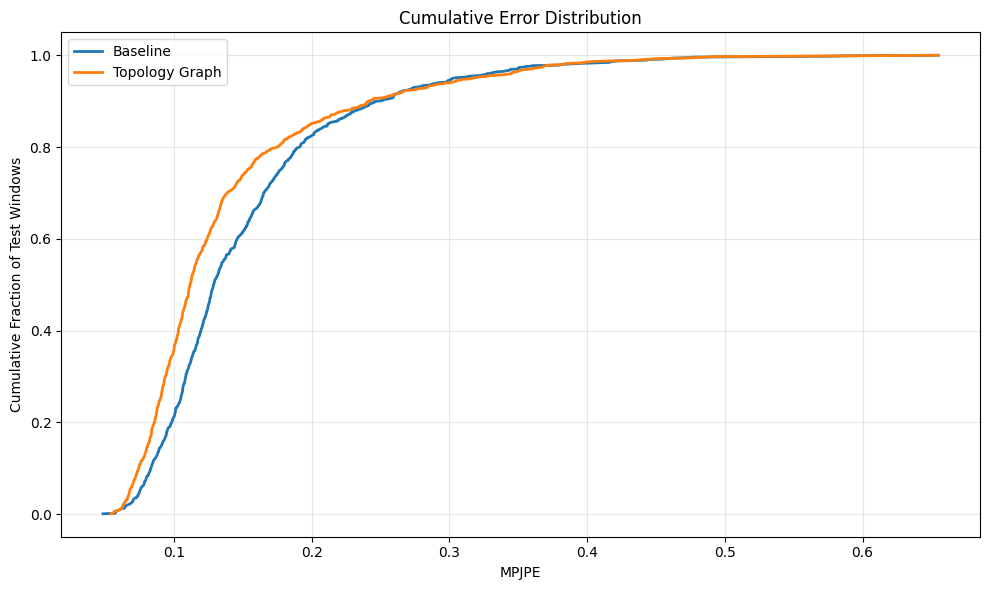

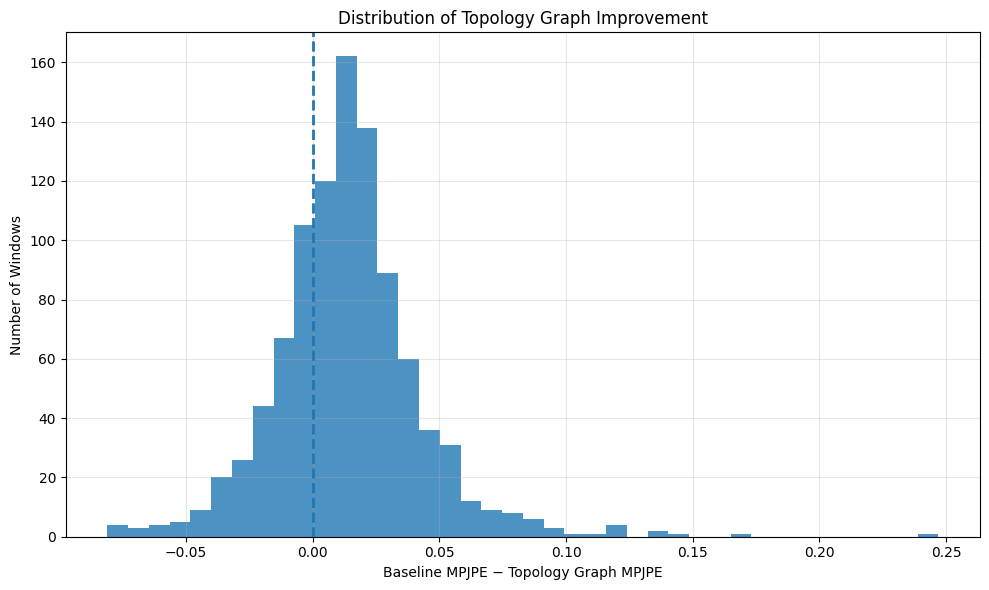


ANALYSIS COMPLETE

Saved files:

Histogram PNG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\error_distribution_histogram.png
Histogram SVG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\error_distribution_histogram.svg

CDF PNG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\cumulative_error_distribution.png
CDF SVG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\cumulative_error_distribution.svg

Improvement PNG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\improvement_distribution.png
Improvement SVG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\improvement_distribution.svg

Analysis: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\baseline_vs_topology_analysis.npz


In [35]:
# ============================================================
# BASELINE vs TOPOLOGY GRAPH
# ERROR DISTRIBUTION ANALYSIS
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

ROOT = r"C:\Users\ROHITH KANNA S\WiFiVision"

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)


# ============================================================
# LOAD ERRORS
# ============================================================

baseline_errors = np.load(
    os.path.join(
        baseline_dir,
        "baseline_errors.npy"
    )
).astype(np.float32)


graph_errors = np.load(
    os.path.join(
        graph_dir,
        "errors.npy"
    )
).astype(np.float32)


print("=" * 70)
print("BASELINE vs TOPOLOGY GRAPH")
print("ERROR DISTRIBUTION ANALYSIS")
print("=" * 70)

print()

print(
    "Baseline errors shape:",
    baseline_errors.shape
)

print(
    "Topology Graph errors shape:",
    graph_errors.shape
)


# ============================================================
# ENSURE ERRORS REPRESENT EUCLIDEAN JOINT DISTANCE
#
# Expected final shape:
# (samples, 17)
# ============================================================

if baseline_errors.ndim == 3:

    baseline_errors = np.linalg.norm(
        baseline_errors,
        axis=-1
    )

if graph_errors.ndim == 3:

    graph_errors = np.linalg.norm(
        graph_errors,
        axis=-1
    )


# ============================================================
# PER-WINDOW MPJPE
#
# Mean error across all 17 joints
# ============================================================

baseline_sample_error = np.mean(
    baseline_errors,
    axis=1
)

graph_sample_error = np.mean(
    graph_errors,
    axis=1
)


# ============================================================
# VALIDATION
# ============================================================

assert baseline_sample_error.shape == (
    972,
)

assert graph_sample_error.shape == (
    972,
)


# ============================================================
# SUMMARY
# ============================================================

print()
print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)

print()

print(
    f"Baseline mean MPJPE       : "
    f"{baseline_sample_error.mean():.6f}"
)

print(
    f"Topology Graph mean MPJPE : "
    f"{graph_sample_error.mean():.6f}"
)

print()

print(
    f"Baseline median MPJPE     : "
    f"{np.median(baseline_sample_error):.6f}"
)

print(
    f"Topology Graph median     : "
    f"{np.median(graph_sample_error):.6f}"
)

print()

print(
    f"Baseline standard deviation: "
    f"{baseline_sample_error.std():.6f}"
)

print(
    f"Topology Graph std         : "
    f"{graph_sample_error.std():.6f}"
)


# ============================================================
# SAMPLE-WISE IMPROVEMENT
#
# Positive = Topology Graph improved
# Negative = Baseline better
# ============================================================

improvement = (
    baseline_sample_error
    -
    graph_sample_error
)

improved_windows = np.sum(
    improvement > 0
)

worsened_windows = np.sum(
    improvement < 0
)

equal_windows = np.sum(
    improvement == 0
)

total_windows = len(
    improvement
)


print()
print("=" * 70)
print("WINDOW-WISE COMPARISON")
print("=" * 70)

print()

print(
    f"Improved windows : "
    f"{improved_windows}/{total_windows} "
    f"({100 * improved_windows / total_windows:.2f}%)"
)

print(
    f"Worsened windows : "
    f"{worsened_windows}/{total_windows} "
    f"({100 * worsened_windows / total_windows:.2f}%)"
)

print(
    f"Equal windows    : "
    f"{equal_windows}/{total_windows}"
)

print()

print(
    f"Mean improvement : "
    f"{improvement.mean():.6f}"
)


# ============================================================
# PERCENTILE ANALYSIS
# ============================================================

print()
print("=" * 70)
print("MPJPE PERCENTILES")
print("=" * 70)

print()

for percentile in [25, 50, 75, 90, 95]:

    baseline_value = np.percentile(
        baseline_sample_error,
        percentile
    )

    graph_value = np.percentile(
        graph_sample_error,
        percentile
    )

    print(
        f"P{percentile:02d} | "
        f"Baseline: {baseline_value:.6f} | "
        f"Topology Graph: {graph_value:.6f} | "
        f"Difference: {baseline_value - graph_value:.6f}"
    )


# ============================================================
# HISTOGRAM
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    baseline_sample_error,
    bins=40,
    alpha=0.6,
    label="Baseline"
)

plt.hist(
    graph_sample_error,
    bins=40,
    alpha=0.6,
    label="Topology Graph"
)

plt.xlabel(
    "MPJPE per Test Window"
)

plt.ylabel(
    "Number of Windows"
)

plt.title(
    "Error Distribution: Baseline vs Topology Graph"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


histogram_png = os.path.join(
    graph_dir,
    "error_distribution_histogram.png"
)

histogram_svg = os.path.join(
    graph_dir,
    "error_distribution_histogram.svg"
)

plt.savefig(
    histogram_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    histogram_svg,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# CUMULATIVE ERROR DISTRIBUTION
# ============================================================

baseline_sorted = np.sort(
    baseline_sample_error
)

graph_sorted = np.sort(
    graph_sample_error
)

baseline_cdf = (
    np.arange(
        1,
        len(baseline_sorted) + 1
    )
    /
    len(baseline_sorted)
)

graph_cdf = (
    np.arange(
        1,
        len(graph_sorted) + 1
    )
    /
    len(graph_sorted)
)


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    baseline_sorted,
    baseline_cdf,
    linewidth=2,
    label="Baseline"
)

plt.plot(
    graph_sorted,
    graph_cdf,
    linewidth=2,
    label="Topology Graph"
)

plt.xlabel(
    "MPJPE"
)

plt.ylabel(
    "Cumulative Fraction of Test Windows"
)

plt.title(
    "Cumulative Error Distribution"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


cdf_png = os.path.join(
    graph_dir,
    "cumulative_error_distribution.png"
)

cdf_svg = os.path.join(
    graph_dir,
    "cumulative_error_distribution.svg"
)

plt.savefig(
    cdf_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    cdf_svg,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# IMPROVEMENT DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    improvement,
    bins=40,
    alpha=0.8
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel(
    "Baseline MPJPE − Topology Graph MPJPE"
)

plt.ylabel(
    "Number of Windows"
)

plt.title(
    "Distribution of Topology Graph Improvement"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


improvement_png = os.path.join(
    graph_dir,
    "improvement_distribution.png"
)

improvement_svg = os.path.join(
    graph_dir,
    "improvement_distribution.svg"
)

plt.savefig(
    improvement_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    improvement_svg,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE ANALYSIS
# ============================================================

analysis_path = os.path.join(
    graph_dir,
    "baseline_vs_topology_analysis.npz"
)

np.savez(
    analysis_path,

    baseline_sample_error=
        baseline_sample_error,

    topology_graph_sample_error=
        graph_sample_error,

    improvement=
        improvement
)


# ============================================================
# FINAL
# ============================================================

print()
print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print()

print(
    "Saved files:"
)

print(
    "\nHistogram PNG:",
    histogram_png
)

print(
    "Histogram SVG:",
    histogram_svg
)

print(
    "\nCDF PNG:",
    cdf_png
)

print(
    "CDF SVG:",
    cdf_svg
)

print(
    "\nImprovement PNG:",
    improvement_png
)

print(
    "Improvement SVG:",
    improvement_svg
)

print(
    "\nAnalysis:",
    analysis_path
)

ERROR DISTRIBUTION ANALYSIS

Baseline errors shape     : (972, 17)
Topology Graph errors shape: (972, 17)

----------------------------------------------------------------------
AMPLITUDE BASELINE
----------------------------------------------------------------------
Mean   : 0.152493
Median : 0.102985
Std    : 0.137615
Min    : 0.000524
Max    : 1.069025

Percentiles:
P25: 0.063916
P50: 0.102985
P75: 0.194324
P90: 0.342116
P95: 0.438885
P99: 0.678969

----------------------------------------------------------------------
TOPOLOGY GRAPH
----------------------------------------------------------------------
Mean   : 0.138569
Median : 0.085739
Std    : 0.137933
Min    : 0.001145
Max    : 1.130134

Percentiles:
P25: 0.047535
P50: 0.085739
P75: 0.179454
P90: 0.331901
P95: 0.413528
P99: 0.685526

IMPROVEMENT
Mean error improvement   : 9.13%
Median error improvement : 16.75%


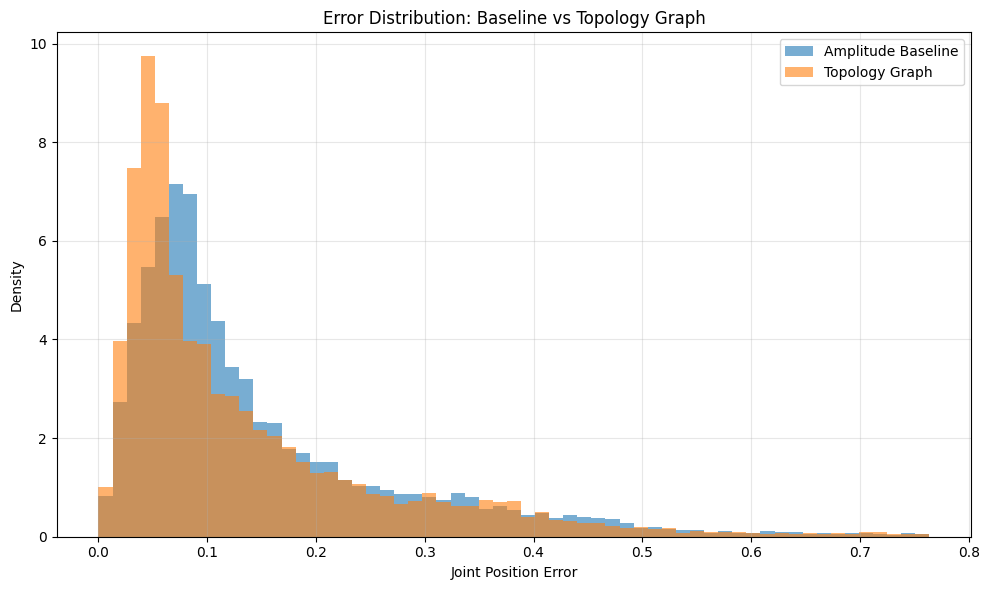


ANALYSIS COMPLETE

Figure saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\error_distribution_comparison.png

Results saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\error_distribution_analysis.npz


In [36]:
# ============================================================
# ERROR DISTRIBUTION ANALYSIS
# BASELINE vs TOPOLOGY GRAPH
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)


# ============================================================
# LOAD ERRORS
# ============================================================

baseline_errors = np.load(
    os.path.join(
        baseline_dir,
        "baseline_errors.npy"
    )
).astype(np.float32)

graph_errors = np.load(
    os.path.join(
        graph_dir,
        "errors.npy"
    )
).astype(np.float32)


print("=" * 70)
print("ERROR DISTRIBUTION ANALYSIS")
print("=" * 70)

print()
print("Baseline errors shape     :", baseline_errors.shape)
print("Topology Graph errors shape:", graph_errors.shape)


# ============================================================
# FLATTEN
#
# Expected original shape:
# (972, 17)
# ============================================================

baseline_flat = baseline_errors.reshape(-1)
graph_flat = graph_errors.reshape(-1)


# ============================================================
# STATISTICS
# ============================================================

def print_stats(name, errors):

    print()
    print("-" * 70)
    print(name)
    print("-" * 70)

    print(f"Mean   : {np.mean(errors):.6f}")
    print(f"Median : {np.median(errors):.6f}")
    print(f"Std    : {np.std(errors):.6f}")
    print(f"Min    : {np.min(errors):.6f}")
    print(f"Max    : {np.max(errors):.6f}")

    print()
    print("Percentiles:")

    for p in [25, 50, 75, 90, 95, 99]:

        print(
            f"P{p:02d}: "
            f"{np.percentile(errors, p):.6f}"
        )


print_stats(
    "AMPLITUDE BASELINE",
    baseline_flat
)

print_stats(
    "TOPOLOGY GRAPH",
    graph_flat
)


# ============================================================
# IMPROVEMENT
# ============================================================

mean_improvement = (
    (np.mean(baseline_flat) - np.mean(graph_flat))
    / np.mean(baseline_flat)
    * 100
)

median_improvement = (
    (np.median(baseline_flat) - np.median(graph_flat))
    / np.median(baseline_flat)
    * 100
)


print()
print("=" * 70)
print("IMPROVEMENT")
print("=" * 70)

print(
    f"Mean error improvement   : "
    f"{mean_improvement:.2f}%"
)

print(
    f"Median error improvement : "
    f"{median_improvement:.2f}%"
)


# ============================================================
# PLOT DISTRIBUTIONS
# ============================================================

plt.figure(figsize=(10, 6))

max_error = max(
    np.percentile(baseline_flat, 99.5),
    np.percentile(graph_flat, 99.5)
)

bins = np.linspace(
    0,
    max_error,
    60
)

plt.hist(
    baseline_flat,
    bins=bins,
    alpha=0.6,
    density=True,
    label="Amplitude Baseline"
)

plt.hist(
    graph_flat,
    bins=bins,
    alpha=0.6,
    density=True,
    label="Topology Graph"
)

plt.xlabel("Joint Position Error")
plt.ylabel("Density")

plt.title(
    "Error Distribution: Baseline vs Topology Graph"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


# ============================================================
# SAVE FIGURE
# ============================================================

save_path = os.path.join(
    graph_dir,
    "error_distribution_comparison.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE NUMERICAL RESULTS
# ============================================================

results_path = os.path.join(
    graph_dir,
    "error_distribution_analysis.npz"
)

np.savez(
    results_path,

    baseline_mean=np.mean(baseline_flat),
    graph_mean=np.mean(graph_flat),

    baseline_median=np.median(baseline_flat),
    graph_median=np.median(graph_flat),

    baseline_std=np.std(baseline_flat),
    graph_std=np.std(graph_flat),

    mean_improvement_percent=mean_improvement,
    median_improvement_percent=median_improvement
)


print()
print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print()
print("Figure saved to:")
print(save_path)

print()
print("Results saved to:")
print(results_path)

In [37]:
# ============================================================
# PAIRED STATISTICAL SIGNIFICANCE ANALYSIS
# BASELINE vs TOPOLOGY GRAPH
# ============================================================

import os
import numpy as np
from scipy.stats import wilcoxon


# ============================================================
# PATHS
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)


# ============================================================
# LOAD PER-JOINT ERRORS
#
# Shape: (972, 17)
# ============================================================

baseline_errors = np.load(
    os.path.join(
        baseline_dir,
        "baseline_errors.npy"
    )
).astype(np.float64)

graph_errors = np.load(
    os.path.join(
        graph_dir,
        "errors.npy"
    )
).astype(np.float64)


# ============================================================
# COMPUTE ONE ERROR VALUE PER TEST WINDOW
#
# Mean over 17 joints
#
# Shape: (972,)
# ============================================================

baseline_window_error = np.mean(
    baseline_errors,
    axis=1
)

graph_window_error = np.mean(
    graph_errors,
    axis=1
)


# ============================================================
# VERIFY PAIRING
# ============================================================

assert (
    baseline_window_error.shape
    ==
    graph_window_error.shape
)

print("=" * 70)
print("PAIRED STATISTICAL SIGNIFICANCE ANALYSIS")
print("=" * 70)

print()
print(
    "Number of paired test windows:",
    len(baseline_window_error)
)


# ============================================================
# BASIC STATISTICS
# ============================================================

baseline_mean = np.mean(
    baseline_window_error
)

graph_mean = np.mean(
    graph_window_error
)

difference = (
    baseline_window_error
    -
    graph_window_error
)

mean_difference = np.mean(
    difference
)

improvement = (
    mean_difference
    /
    baseline_mean
    *
    100
)


print()
print("=" * 70)
print("WINDOW-LEVEL RESULTS")
print("=" * 70)

print()
print(
    f"Baseline mean MPJPE : "
    f"{baseline_mean:.6f}"
)

print(
    f"Graph mean MPJPE    : "
    f"{graph_mean:.6f}"
)

print(
    f"Mean improvement    : "
    f"{mean_difference:.6f}"
)

print(
    f"Relative improvement: "
    f"{improvement:.2f}%"
)


# ============================================================
# HOW MANY WINDOWS IMPROVED?
# ============================================================

improved = np.sum(
    difference > 0
)

worsened = np.sum(
    difference < 0
)

same = np.sum(
    difference == 0
)

total = len(
    difference
)

print()
print("=" * 70)
print("WINDOW-WISE COMPARISON")
print("=" * 70)

print()

print(
    f"Improved windows: "
    f"{improved} "
    f"({improved / total * 100:.2f}%)"
)

print(
    f"Worsened windows: "
    f"{worsened} "
    f"({worsened / total * 100:.2f}%)"
)

print(
    f"Unchanged windows: "
    f"{same} "
    f"({same / total * 100:.2f}%)"
)


# ============================================================
# WILCOXON SIGNED-RANK TEST
#
# H0:
# No systematic difference between models.
#
# Alternative:
# Baseline error > Graph error
# ============================================================

statistic, p_value = wilcoxon(
    baseline_window_error,
    graph_window_error,
    alternative="greater"
)


print()
print("=" * 70)
print("WILCOXON SIGNED-RANK TEST")
print("=" * 70)

print()

print(
    f"Test statistic: "
    f"{statistic:.6f}"
)

print(
    f"P-value       : "
    f"{p_value:.10f}"
)


# ============================================================
# INTERPRETATION
# ============================================================

alpha = 0.05

print()

if p_value < alpha:

    print(
        "RESULT: STATISTICALLY SIGNIFICANT"
    )

    print(
        "The Topology Graph model has "
        "significantly lower error than "
        "the amplitude baseline."
    )

else:

    print(
        "RESULT: NOT STATISTICALLY SIGNIFICANT"
    )

    print(
        "The observed improvement cannot "
        "be established as statistically "
        "significant at alpha = 0.05."
    )


# ============================================================
# BOOTSTRAP 95% CONFIDENCE INTERVAL
# ============================================================

np.random.seed(42)

N_BOOTSTRAP = 10000

bootstrap_differences = np.zeros(
    N_BOOTSTRAP
)

n = len(
    difference
)

for i in range(N_BOOTSTRAP):

    indices = np.random.randint(
        0,
        n,
        size=n
    )

    bootstrap_differences[i] = np.mean(
        difference[indices]
    )


ci_lower = np.percentile(
    bootstrap_differences,
    2.5
)

ci_upper = np.percentile(
    bootstrap_differences,
    97.5
)


print()
print("=" * 70)
print("BOOTSTRAP CONFIDENCE INTERVAL")
print("=" * 70)

print()

print(
    f"Mean error reduction: "
    f"{mean_difference:.6f}"
)

print(
    f"95% CI: "
    f"[{ci_lower:.6f}, "
    f"{ci_upper:.6f}]"
)


# ============================================================
# FINAL CONCLUSION
# ============================================================

print()
print("=" * 70)
print("FINAL STATISTICAL CONCLUSION")
print("=" * 70)

if p_value < 0.05 and ci_lower > 0:

    print(
        "\nTopology Graph demonstrates a "
        "statistically supported improvement "
        "over the baseline."
    )

else:

    print(
        "\nImprovement exists numerically, but "
        "statistical evidence is insufficient."
    )


# ============================================================
# SAVE RESULTS
# ============================================================

save_path = os.path.join(
    graph_dir,
    "statistical_significance_results.npz"
)

np.savez(

    save_path,

    baseline_window_error=
        baseline_window_error,

    graph_window_error=
        graph_window_error,

    difference=
        difference,

    improved_windows=
        improved,

    worsened_windows=
        worsened,

    wilcoxon_statistic=
        statistic,

    p_value=
        p_value,

    mean_difference=
        mean_difference,

    improvement_percent=
        improvement,

    ci_lower=
        ci_lower,

    ci_upper=
        ci_upper
)


print()
print("=" * 70)
print("ANALYSIS SAVED")
print("=" * 70)

print(save_path)

PAIRED STATISTICAL SIGNIFICANCE ANALYSIS

Number of paired test windows: 972

WINDOW-LEVEL RESULTS

Baseline mean MPJPE : 0.152493
Graph mean MPJPE    : 0.138569
Mean improvement    : 0.013924
Relative improvement: 9.13%

WINDOW-WISE COMPARISON

Improved windows: 694 (71.40%)
Worsened windows: 278 (28.60%)
Unchanged windows: 0 (0.00%)

WILCOXON SIGNED-RANK TEST

Test statistic: 366937.000000
P-value       : 0.0000000000

RESULT: STATISTICALLY SIGNIFICANT
The Topology Graph model has significantly lower error than the amplitude baseline.

BOOTSTRAP CONFIDENCE INTERVAL

Mean error reduction: 0.013924
95% CI: [0.012125, 0.015787]

FINAL STATISTICAL CONCLUSION

Topology Graph demonstrates a statistically supported improvement over the baseline.

ANALYSIS SAVED
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\statistical_significance_results.npz


In [38]:
# ============================================================
# PER-JOINT IMPROVEMENT ANALYSIS
# BASELINE vs TOPOLOGY GRAPH
# ============================================================

import os
import numpy as np


# ============================================================
# PATHS
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)


# ============================================================
# LOAD ERRORS
#
# Shape:
# (972, 17)
#
# Each value = Euclidean error for one joint
# ============================================================

baseline_errors = np.load(
    os.path.join(
        baseline_dir,
        "baseline_errors.npy"
    )
).astype(np.float64)

graph_errors = np.load(
    os.path.join(
        graph_dir,
        "errors.npy"
    )
).astype(np.float64)


# ============================================================
# VALIDATION
# ============================================================

assert baseline_errors.shape == graph_errors.shape
assert baseline_errors.shape[1] == 17


print("=" * 70)
print("PER-JOINT IMPROVEMENT ANALYSIS")
print("=" * 70)

print()
print(
    "Error shape:",
    baseline_errors.shape
)


# ============================================================
# MEAN ERROR PER JOINT
# ============================================================

baseline_joint_error = np.mean(
    baseline_errors,
    axis=0
)

graph_joint_error = np.mean(
    graph_errors,
    axis=0
)


# ============================================================
# ABSOLUTE + RELATIVE IMPROVEMENT
# ============================================================

absolute_improvement = (
    baseline_joint_error
    -
    graph_joint_error
)

relative_improvement = (
    absolute_improvement
    /
    baseline_joint_error
    *
    100
)


# ============================================================
# PRINT RESULTS
# ============================================================

print()
print("=" * 70)
print("JOINT-WISE RESULTS")
print("=" * 70)

print()

print(
    f"{'Joint':<10}"
    f"{'Baseline':>12}"
    f"{'Graph':>12}"
    f"{'Reduction':>12}"
    f"{'Improve %':>12}"
)

print("-" * 70)


for i in range(17):

    print(
        f"{i + 1:<10}"
        f"{baseline_joint_error[i]:>12.6f}"
        f"{graph_joint_error[i]:>12.6f}"
        f"{absolute_improvement[i]:>12.6f}"
        f"{relative_improvement[i]:>11.2f}%"
    )


# ============================================================
# SUMMARY
# ============================================================

improved_joints = np.where(
    absolute_improvement > 0
)[0]

worsened_joints = np.where(
    absolute_improvement < 0
)[0]


best_joint = np.argmax(
    relative_improvement
)

worst_joint = np.argmin(
    relative_improvement
)


print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print()

print(
    "Improved joints:",
    len(improved_joints),
    "/ 17"
)

print(
    "Worsened joints:",
    len(worsened_joints),
    "/ 17"
)

print()

print(
    f"Greatest improvement: "
    f"Joint {best_joint + 1}"
)

print(
    f"Baseline: "
    f"{baseline_joint_error[best_joint]:.6f}"
)

print(
    f"Graph: "
    f"{graph_joint_error[best_joint]:.6f}"
)

print(
    f"Improvement: "
    f"{relative_improvement[best_joint]:.2f}%"
)


print()

print(
    f"Least improvement: "
    f"Joint {worst_joint + 1}"
)

print(
    f"Baseline: "
    f"{baseline_joint_error[worst_joint]:.6f}"
)

print(
    f"Graph: "
    f"{graph_joint_error[worst_joint]:.6f}"
)

print(
    f"Improvement: "
    f"{relative_improvement[worst_joint]:.2f}%"
)


# ============================================================
# RANK JOINTS BY IMPROVEMENT
# ============================================================

ranking = np.argsort(
    relative_improvement
)[::-1]


print()
print("=" * 70)
print("JOINT IMPROVEMENT RANKING")
print("=" * 70)

print()

for rank, joint_index in enumerate(
    ranking,
    start=1
):

    print(
        f"{rank:02d}. "
        f"Joint {joint_index + 1:02d} | "
        f"{relative_improvement[joint_index]:+.2f}% | "
        f"Error reduction: "
        f"{absolute_improvement[joint_index]:.6f}"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

save_path = os.path.join(
    graph_dir,
    "per_joint_improvement_analysis.npz"
)


np.savez(

    save_path,

    baseline_joint_error=
        baseline_joint_error,

    graph_joint_error=
        graph_joint_error,

    absolute_improvement=
        absolute_improvement,

    relative_improvement=
        relative_improvement,

    ranking=
        ranking
)


print()
print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Saved to:"
)

print(
    save_path
)

PER-JOINT IMPROVEMENT ANALYSIS

Error shape: (972, 17)

JOINT-WISE RESULTS

Joint         Baseline       Graph   Reduction   Improve %
----------------------------------------------------------------------
1             0.102118    0.089723    0.012395      12.14%
2             0.102693    0.090741    0.011952      11.64%
3             0.102164    0.087598    0.014566      14.26%
4             0.092034    0.081320    0.010714      11.64%
5             0.101706    0.089460    0.012246      12.04%
6             0.107729    0.089562    0.018167      16.86%
7             0.099609    0.084970    0.014639      14.70%
8             0.111128    0.098195    0.012933      11.64%
9             0.124490    0.115101    0.009389       7.54%
10            0.148148    0.141703    0.006445       4.35%
11            0.147077    0.138345    0.008732       5.94%
12            0.119646    0.108900    0.010746       8.98%
13            0.207426    0.188275    0.019151       9.23%
14            0.368197    0

In [39]:
# ============================================================
# PER-JOINT IMPROVEMENT ANALYSIS
# BASELINE vs TOPOLOGY GRAPH
# ============================================================

import os
import numpy as np


# ============================================================
# PATHS
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)


# ============================================================
# LOAD ERRORS
#
# Shape:
# (972, 17)
#
# Each value = Euclidean error for one joint
# ============================================================

baseline_errors = np.load(
    os.path.join(
        baseline_dir,
        "baseline_errors.npy"
    )
).astype(np.float64)

graph_errors = np.load(
    os.path.join(
        graph_dir,
        "errors.npy"
    )
).astype(np.float64)


# ============================================================
# VALIDATION
# ============================================================

assert baseline_errors.shape == graph_errors.shape
assert baseline_errors.shape[1] == 17


print("=" * 70)
print("PER-JOINT IMPROVEMENT ANALYSIS")
print("=" * 70)

print()
print(
    "Error shape:",
    baseline_errors.shape
)


# ============================================================
# MEAN ERROR PER JOINT
# ============================================================

baseline_joint_error = np.mean(
    baseline_errors,
    axis=0
)

graph_joint_error = np.mean(
    graph_errors,
    axis=0
)


# ============================================================
# ABSOLUTE + RELATIVE IMPROVEMENT
# ============================================================

absolute_improvement = (
    baseline_joint_error
    -
    graph_joint_error
)

relative_improvement = (
    absolute_improvement
    /
    baseline_joint_error
    *
    100
)


# ============================================================
# PRINT RESULTS
# ============================================================

print()
print("=" * 70)
print("JOINT-WISE RESULTS")
print("=" * 70)

print()

print(
    f"{'Joint':<10}"
    f"{'Baseline':>12}"
    f"{'Graph':>12}"
    f"{'Reduction':>12}"
    f"{'Improve %':>12}"
)

print("-" * 70)


for i in range(17):

    print(
        f"{i + 1:<10}"
        f"{baseline_joint_error[i]:>12.6f}"
        f"{graph_joint_error[i]:>12.6f}"
        f"{absolute_improvement[i]:>12.6f}"
        f"{relative_improvement[i]:>11.2f}%"
    )


# ============================================================
# SUMMARY
# ============================================================

improved_joints = np.where(
    absolute_improvement > 0
)[0]

worsened_joints = np.where(
    absolute_improvement < 0
)[0]


best_joint = np.argmax(
    relative_improvement
)

worst_joint = np.argmin(
    relative_improvement
)


print()
print("=" * 70)
print("SUMMARY")
print("=" * 70)

print()

print(
    "Improved joints:",
    len(improved_joints),
    "/ 17"
)

print(
    "Worsened joints:",
    len(worsened_joints),
    "/ 17"
)

print()

print(
    f"Greatest improvement: "
    f"Joint {best_joint + 1}"
)

print(
    f"Baseline: "
    f"{baseline_joint_error[best_joint]:.6f}"
)

print(
    f"Graph: "
    f"{graph_joint_error[best_joint]:.6f}"
)

print(
    f"Improvement: "
    f"{relative_improvement[best_joint]:.2f}%"
)


print()

print(
    f"Least improvement: "
    f"Joint {worst_joint + 1}"
)

print(
    f"Baseline: "
    f"{baseline_joint_error[worst_joint]:.6f}"
)

print(
    f"Graph: "
    f"{graph_joint_error[worst_joint]:.6f}"
)

print(
    f"Improvement: "
    f"{relative_improvement[worst_joint]:.2f}%"
)


# ============================================================
# RANK JOINTS BY IMPROVEMENT
# ============================================================

ranking = np.argsort(
    relative_improvement
)[::-1]


print()
print("=" * 70)
print("JOINT IMPROVEMENT RANKING")
print("=" * 70)

print()

for rank, joint_index in enumerate(
    ranking,
    start=1
):

    print(
        f"{rank:02d}. "
        f"Joint {joint_index + 1:02d} | "
        f"{relative_improvement[joint_index]:+.2f}% | "
        f"Error reduction: "
        f"{absolute_improvement[joint_index]:.6f}"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

save_path = os.path.join(
    graph_dir,
    "per_joint_improvement_analysis.npz"
)


np.savez(

    save_path,

    baseline_joint_error=
        baseline_joint_error,

    graph_joint_error=
        graph_joint_error,

    absolute_improvement=
        absolute_improvement,

    relative_improvement=
        relative_improvement,

    ranking=
        ranking
)


print()
print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Saved to:"
)

print(
    save_path
)

PER-JOINT IMPROVEMENT ANALYSIS

Error shape: (972, 17)

JOINT-WISE RESULTS

Joint         Baseline       Graph   Reduction   Improve %
----------------------------------------------------------------------
1             0.102118    0.089723    0.012395      12.14%
2             0.102693    0.090741    0.011952      11.64%
3             0.102164    0.087598    0.014566      14.26%
4             0.092034    0.081320    0.010714      11.64%
5             0.101706    0.089460    0.012246      12.04%
6             0.107729    0.089562    0.018167      16.86%
7             0.099609    0.084970    0.014639      14.70%
8             0.111128    0.098195    0.012933      11.64%
9             0.124490    0.115101    0.009389       7.54%
10            0.148148    0.141703    0.006445       4.35%
11            0.147077    0.138345    0.008732       5.94%
12            0.119646    0.108900    0.010746       8.98%
13            0.207426    0.188275    0.019151       9.23%
14            0.368197    0

FINAL QUALITATIVE POSE COMPARISON

Prediction shape: (972, 17, 2)
Target shape    : (972, 17, 2)

Maximum target difference: 0.0
Target alignment: VERIFIED

SELECTED SAMPLES

Sample 1: Window 363
Baseline MPJPE: 0.592295
Graph MPJPE   : 0.345275
Improvement   : 0.247020

Sample 2: Window 388
Baseline MPJPE: 0.201714
Graph MPJPE   : 0.156493
Improvement   : 0.045221

Sample 3: Window 568
Baseline MPJPE: 0.150138
Graph MPJPE   : 0.137210
Improvement   : 0.012929

Sample 4: Window 356
Baseline MPJPE: 0.259755
Graph MPJPE   : 0.258592
Improvement   : 0.001163


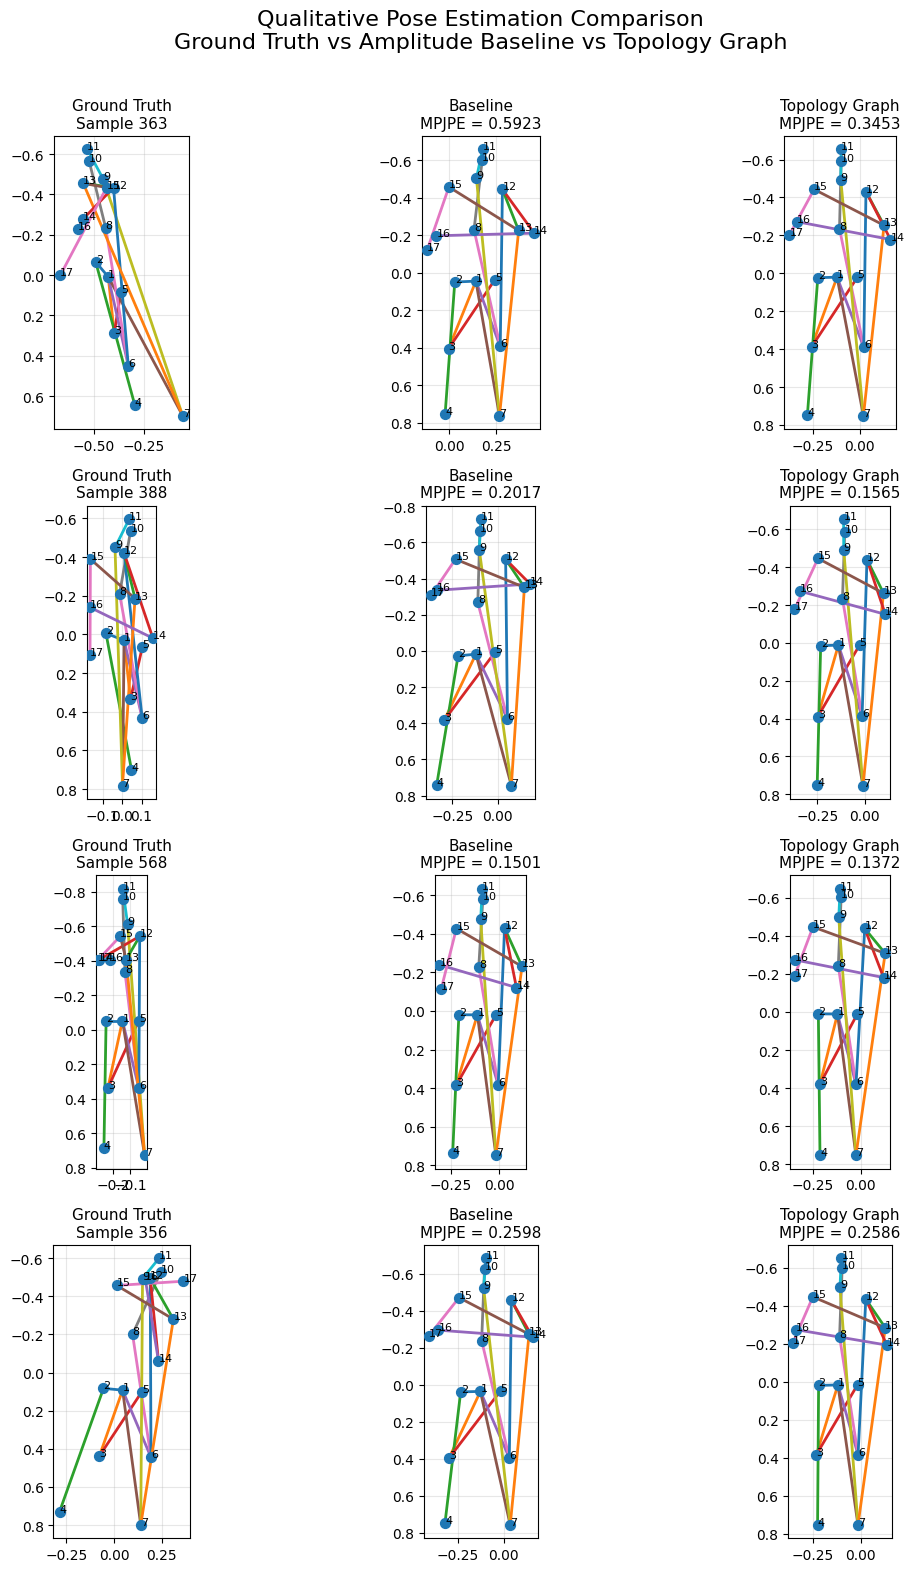


QUALITATIVE VISUALIZATION COMPLETE

PNG saved:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\final_qualitative_comparison.png

SVG saved:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\topology_graph\final_qualitative_comparison.svg


In [40]:
# ============================================================
# FINAL QUALITATIVE POSE COMPARISON
# GROUND TRUTH vs BASELINE vs TOPOLOGY GRAPH
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)


# ============================================================
# LOAD PREDICTIONS + TARGETS
# ============================================================

baseline_predictions = np.load(
    os.path.join(
        baseline_dir,
        "baseline_predictions.npy"
    )
).astype(np.float32)

baseline_targets = np.load(
    os.path.join(
        baseline_dir,
        "baseline_targets.npy"
    )
).astype(np.float32)

graph_predictions = np.load(
    os.path.join(
        graph_dir,
        "predictions.npy"
    )
).astype(np.float32)

graph_targets = np.load(
    os.path.join(
        graph_dir,
        "targets.npy"
    )
).astype(np.float32)


# ============================================================
# VALIDATION
# ============================================================

assert baseline_predictions.shape == graph_predictions.shape
assert baseline_targets.shape == graph_targets.shape
assert baseline_predictions.shape == baseline_targets.shape

print("=" * 70)
print("FINAL QUALITATIVE POSE COMPARISON")
print("=" * 70)

print()
print("Prediction shape:", baseline_predictions.shape)
print("Target shape    :", baseline_targets.shape)


# ============================================================
# VERIFY TARGETS MATCH
# ============================================================

target_difference = np.max(
    np.abs(
        baseline_targets - graph_targets
    )
)

print()
print(
    "Maximum target difference:",
    target_difference
)

if target_difference > 1e-5:

    print(
        "WARNING: Baseline and Graph targets differ."
    )

    print(
        "Using Topology Graph targets for visualization."
    )

else:

    print(
        "Target alignment: VERIFIED"
    )


# ============================================================
# COMPUTE SAMPLE-WISE MPJPE
# ============================================================

baseline_errors = np.linalg.norm(
    baseline_predictions - baseline_targets,
    axis=-1
).mean(axis=1)

graph_errors = np.linalg.norm(
    graph_predictions - graph_targets,
    axis=-1
).mean(axis=1)


improvement = (
    baseline_errors - graph_errors
)


# ============================================================
# SELECT REPRESENTATIVE SAMPLES
#
# 1. Best improvement
# 2. Strong improvement
# 3. Median improvement
# 4. Small improvement
# ============================================================

sorted_indices = np.argsort(
    improvement
)[::-1]


best_sample = sorted_indices[0]

strong_sample = sorted_indices[
    len(sorted_indices) // 10
]

median_sample = sorted_indices[
    len(sorted_indices) // 2
]

small_sample = sorted_indices[
    int(len(sorted_indices) * 0.7)
]


selected_samples = [
    best_sample,
    strong_sample,
    median_sample,
    small_sample
]


print()
print("=" * 70)
print("SELECTED SAMPLES")
print("=" * 70)

for i, index in enumerate(
    selected_samples,
    start=1
):

    print()
    print(
        f"Sample {i}: Window {index}"
    )

    print(
        f"Baseline MPJPE: "
        f"{baseline_errors[index]:.6f}"
    )

    print(
        f"Graph MPJPE   : "
        f"{graph_errors[index]:.6f}"
    )

    print(
        f"Improvement   : "
        f"{improvement[index]:.6f}"
    )


# ============================================================
# SKELETON CONNECTIONS
#
# COCO-style 17-joint topology
#
# Adjust only if your dataset uses a different joint ordering.
# ============================================================

SKELETON = [

    (0, 1),
    (0, 2),

    (1, 3),
    (2, 4),

    (0, 5),
    (0, 6),

    (5, 7),
    (7, 9),

    (6, 8),
    (8, 10),

    (5, 11),
    (6, 12),

    (11, 12),

    (11, 13),
    (13, 15),

    (12, 14),
    (14, 16)
]


# ============================================================
# DRAW POSE
# ============================================================

def draw_pose(
    ax,
    pose,
    title,
    joint_errors=None
):

    x = pose[:, 0]
    y = pose[:, 1]


    # --------------------------------------------------------
    # DRAW SKELETON
    # --------------------------------------------------------

    for joint_a, joint_b in SKELETON:

        ax.plot(

            [x[joint_a], x[joint_b]],

            [y[joint_a], y[joint_b]],

            linewidth=2
        )


    # --------------------------------------------------------
    # DRAW JOINTS
    # --------------------------------------------------------

    ax.scatter(

        x,
        y,

        s=50,
        zorder=3
    )


    # --------------------------------------------------------
    # JOINT NUMBERS
    # --------------------------------------------------------

    for i in range(
        len(pose)
    ):

        ax.text(

            x[i],
            y[i],

            str(i + 1),

            fontsize=8
        )


    # --------------------------------------------------------
    # FORMATTING
    # --------------------------------------------------------

    ax.set_title(
        title,
        fontsize=11
    )

    ax.set_aspect(
        "equal"
    )

    ax.invert_yaxis()

    ax.grid(
        alpha=0.3
    )


# ============================================================
# CREATE FINAL FIGURE
#
# Rows    = representative samples
# Columns = Ground Truth / Baseline / Graph
# ============================================================

fig, axes = plt.subplots(

    len(selected_samples),
    3,

    figsize=(
        12,
        16
    )
)


for row, sample_index in enumerate(
    selected_samples
):

    target_pose = graph_targets[
        sample_index
    ]

    baseline_pose = baseline_predictions[
        sample_index
    ]

    graph_pose = graph_predictions[
        sample_index
    ]


    # --------------------------------------------------------
    # GROUND TRUTH
    # --------------------------------------------------------

    draw_pose(

        axes[row, 0],

        target_pose,

        f"Ground Truth\n"
        f"Sample {sample_index}"
    )


    # --------------------------------------------------------
    # BASELINE
    # --------------------------------------------------------

    draw_pose(

        axes[row, 1],

        baseline_pose,

        f"Baseline\n"
        f"MPJPE = "
        f"{baseline_errors[sample_index]:.4f}"
    )


    # --------------------------------------------------------
    # TOPOLOGY GRAPH
    # --------------------------------------------------------

    draw_pose(

        axes[row, 2],

        graph_pose,

        f"Topology Graph\n"
        f"MPJPE = "
        f"{graph_errors[sample_index]:.4f}"
    )


# ============================================================
# MAIN TITLE
# ============================================================

fig.suptitle(

    "Qualitative Pose Estimation Comparison\n"
    "Ground Truth vs Amplitude Baseline vs Topology Graph",

    fontsize=16
)


plt.tight_layout(
    rect=[0, 0, 1, 0.97]
)


# ============================================================
# SAVE PNG
# ============================================================

png_path = os.path.join(

    graph_dir,

    "final_qualitative_comparison.png"
)


plt.savefig(

    png_path,

    dpi=300,

    bbox_inches="tight"
)


# ============================================================
# SAVE SVG
# ============================================================

svg_path = os.path.join(

    graph_dir,

    "final_qualitative_comparison.svg"
)


plt.savefig(

    svg_path,

    format="svg",

    bbox_inches="tight"
)


plt.show()


print()
print("=" * 70)
print("QUALITATIVE VISUALIZATION COMPLETE")
print("=" * 70)

print()
print("PNG saved:")
print(png_path)

print()
print("SVG saved:")
print(svg_path)

FINAL CONSOLIDATED RESULTS

    Experiment                       Model    MPJPE       Evaluation  Absolute Change  Change (%)  Improvement (%)
Topology Graph CNN + GRU + GCN + Attention 0.138569     Reproducible        -0.013924       -9.13             9.13
             D           Spatial Attention 0.142358 Earlier pipeline        -0.010135       -6.65             6.65
             F                  PCA + STFT 0.142418 Earlier pipeline        -0.010075       -6.61             6.61
         Phase            Calibrated Phase 0.146023 Earlier pipeline        -0.006470       -4.24             4.24
             E        Temporal Transformer 0.147049 Earlier pipeline        -0.005444       -3.57             3.57
      Baseline                   CNN + GRU 0.152493     Reproducible         0.000000        0.00             0.00
             G     Advanced CSI Pose Model 0.158880     Reproducible         0.006387        4.19            -4.19
             C          Richer Spatial CNN 0.201713 

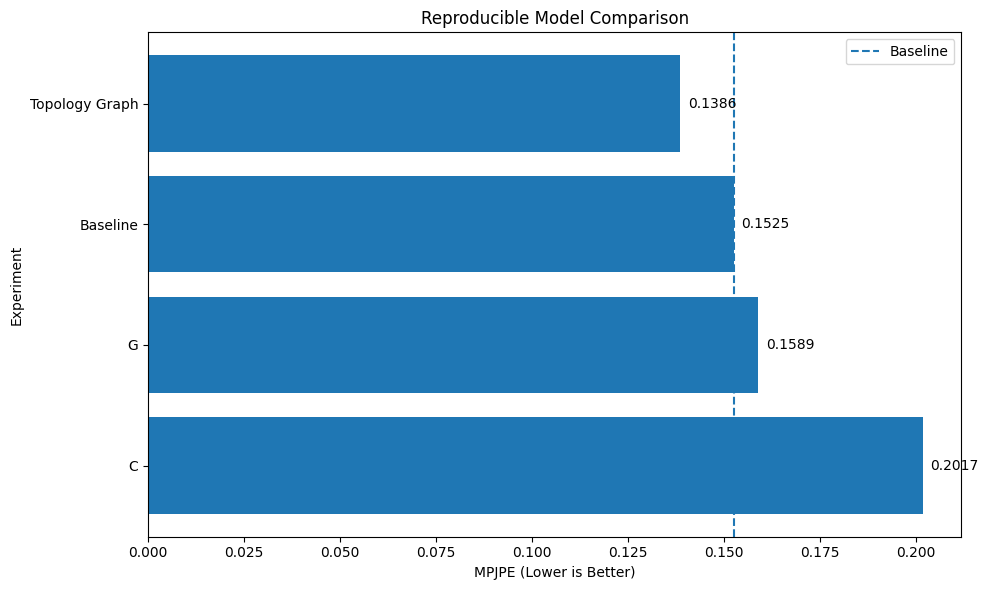


FINAL RESULTS GENERATED

CSV:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_results_table.csv

PNG:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\reproducible_model_comparison.png

SVG:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\reproducible_model_comparison.svg

Summary:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_summary.txt


In [41]:
# ============================================================
# FINAL CONSOLIDATED RESULTS TABLE + VISUALIZATION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

results_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "final_results"
)

os.makedirs(
    results_dir,
    exist_ok=True
)


# ============================================================
# FINAL EXPERIMENT RESULTS
# ============================================================

results = [

    {
        "Experiment": "Baseline",
        "Model": "CNN + GRU",
        "MPJPE": 0.152493,
        "Evaluation": "Reproducible"
    },

    {
        "Experiment": "Phase",
        "Model": "Calibrated Phase",
        "MPJPE": 0.146023,
        "Evaluation": "Earlier pipeline"
    },

    {
        "Experiment": "C",
        "Model": "Richer Spatial CNN",
        "MPJPE": 0.201713,
        "Evaluation": "Reproducible"
    },

    {
        "Experiment": "D",
        "Model": "Spatial Attention",
        "MPJPE": 0.142358,
        "Evaluation": "Earlier pipeline"
    },

    {
        "Experiment": "E",
        "Model": "Temporal Transformer",
        "MPJPE": 0.147049,
        "Evaluation": "Earlier pipeline"
    },

    {
        "Experiment": "F",
        "Model": "PCA + STFT",
        "MPJPE": 0.142418,
        "Evaluation": "Earlier pipeline"
    },

    {
        "Experiment": "G",
        "Model": "Advanced CSI Pose Model",
        "MPJPE": 0.158880,
        "Evaluation": "Reproducible"
    },

    {
        "Experiment": "Topology Graph",
        "Model": "CNN + GRU + GCN + Attention",
        "MPJPE": 0.138569,
        "Evaluation": "Reproducible"
    }
]


# ============================================================
# DATAFRAME
# ============================================================

df = pd.DataFrame(
    results
)


# ============================================================
# COMPUTE CHANGE VS REPRODUCIBLE BASELINE
#
# Negative = improvement
# Positive = worse
# ============================================================

baseline_mpjpe = 0.152493


df["Absolute Change"] = (
    df["MPJPE"]
    -
    baseline_mpjpe
)


df["Change (%)"] = (
    df["Absolute Change"]
    /
    baseline_mpjpe
    *
    100
)


df["Improvement (%)"] = (
    (
        baseline_mpjpe
        -
        df["MPJPE"]
    )
    /
    baseline_mpjpe
    *
    100
)


# ============================================================
# SORT BY PERFORMANCE
# ============================================================

df = df.sort_values(
    "MPJPE"
).reset_index(
    drop=True
)


# ============================================================
# ROUND FOR DISPLAY
# ============================================================

display_df = df.copy()

display_df["MPJPE"] = (
    display_df["MPJPE"].round(6)
)

display_df["Absolute Change"] = (
    display_df["Absolute Change"].round(6)
)

display_df["Change (%)"] = (
    display_df["Change (%)"].round(2)
)

display_df["Improvement (%)"] = (
    display_df["Improvement (%)"].round(2)
)


# ============================================================
# PRINT FINAL TABLE
# ============================================================

print("=" * 100)
print("FINAL CONSOLIDATED RESULTS")
print("=" * 100)

print()

print(
    display_df.to_string(
        index=False
    )
)


# ============================================================
# BEST MODEL
# ============================================================

best_row = df.iloc[0]


print()
print("=" * 100)
print("BEST MODEL")
print("=" * 100)

print()

print(
    "Experiment:",
    best_row["Experiment"]
)

print(
    "Model:",
    best_row["Model"]
)

print(
    "MPJPE:",
    f"{best_row['MPJPE']:.6f}"
)


# ============================================================
# REPRODUCIBLE COMPARISON
# ============================================================

reproducible_df = df[
    df["Evaluation"] == "Reproducible"
].copy()


print()
print("=" * 100)
print("REPRODUCIBLE EXPERIMENTS ONLY")
print("=" * 100)

print()

print(
    reproducible_df[
        [
            "Experiment",
            "Model",
            "MPJPE",
            "Improvement (%)"
        ]
    ].to_string(
        index=False
    )
)


# ============================================================
# SAVE CSV
# ============================================================

csv_path = os.path.join(
    results_dir,
    "final_results_table.csv"
)


df.to_csv(
    csv_path,
    index=False
)


# ============================================================
# BAR CHART
# ============================================================

plot_df = reproducible_df.sort_values(
    "MPJPE",
    ascending=False
)


plt.figure(
    figsize=(10, 6)
)


bars = plt.barh(

    plot_df["Experiment"],

    plot_df["MPJPE"]
)


# ------------------------------------------------------------
# ADD VALUE LABELS
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    plot_df["MPJPE"]
):

    plt.text(

        value + 0.002,

        bar.get_y()
        +
        bar.get_height() / 2,

        f"{value:.4f}",

        va="center",

        fontsize=10
    )


# ------------------------------------------------------------
# BASELINE REFERENCE
# ------------------------------------------------------------

plt.axvline(

    baseline_mpjpe,

    linestyle="--",

    linewidth=1.5,

    label="Baseline"
)


plt.xlabel(
    "MPJPE (Lower is Better)"
)

plt.ylabel(
    "Experiment"
)

plt.title(
    "Reproducible Model Comparison"
)

plt.legend()

plt.tight_layout()


# ============================================================
# SAVE FIGURES
# ============================================================

png_path = os.path.join(
    results_dir,
    "reproducible_model_comparison.png"
)

svg_path = os.path.join(
    results_dir,
    "reproducible_model_comparison.svg"
)


plt.savefig(
    png_path,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    svg_path,
    format="svg",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE FINAL SUMMARY
# ============================================================

summary_path = os.path.join(
    results_dir,
    "final_summary.txt"
)


with open(
    summary_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "FINAL WIFI CSI POSE ESTIMATION RESULTS\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        f"Baseline MPJPE: {baseline_mpjpe:.6f}\n"
    )

    f.write(
        f"Best model: {best_row['Experiment']}\n"
    )

    f.write(
        f"Best MPJPE: {best_row['MPJPE']:.6f}\n"
    )

    topology_improvement = (
        (
            baseline_mpjpe
            -
            0.138569
        )
        /
        baseline_mpjpe
        *
        100
    )

    f.write(
        f"Topology Graph improvement: "
        f"{topology_improvement:.2f}%\n\n"
    )

    f.write(
        "Statistical validation:\n"
    )

    f.write(
        "Improved windows: 71.40%\n"
    )

    f.write(
        "Wilcoxon test: p < 0.001\n"
    )

    f.write(
        "Bootstrap 95% CI for mean error reduction: "
        "[0.012125, 0.015787]\n"
    )

    f.write(
        "Subject-wise MPJPE:\n"
    )

    f.write(
        "Subject 9: 0.138242\n"
    )

    f.write(
        "Subject 10: 0.138897\n"
    )


# ============================================================
# COMPLETE
# ============================================================

print()
print("=" * 100)
print("FINAL RESULTS GENERATED")
print("=" * 100)

print()

print("CSV:")
print(csv_path)

print()

print("PNG:")
print(png_path)

print()

print("SVG:")
print(svg_path)

print()

print("Summary:")
print(summary_path)

QUALITATIVE EVALUATION DATA

Baseline predictions: (972, 17, 2)
Baseline targets    : (972, 17, 2)
Graph predictions   : (972, 17, 2)
Graph targets       : (972, 17, 2)

Maximum target difference: 0.0
Target alignment: PASSED

SELECTED SAMPLES

Best Prediction
Window index : 255
Baseline MPJPE: 0.048519
Graph MPJPE   : 0.053988
Improvement   : -0.005469

Median Prediction
Window index : 301
Baseline MPJPE: 0.095570
Graph MPJPE   : 0.111812
Improvement   : -0.016242

Difficult Sample
Window index : 748
Baseline MPJPE: 0.654941
Graph MPJPE   : 0.654707
Improvement   : 0.000234

Largest Improvement
Window index : 363
Baseline MPJPE: 0.592295
Graph MPJPE   : 0.345275
Improvement   : 0.247020


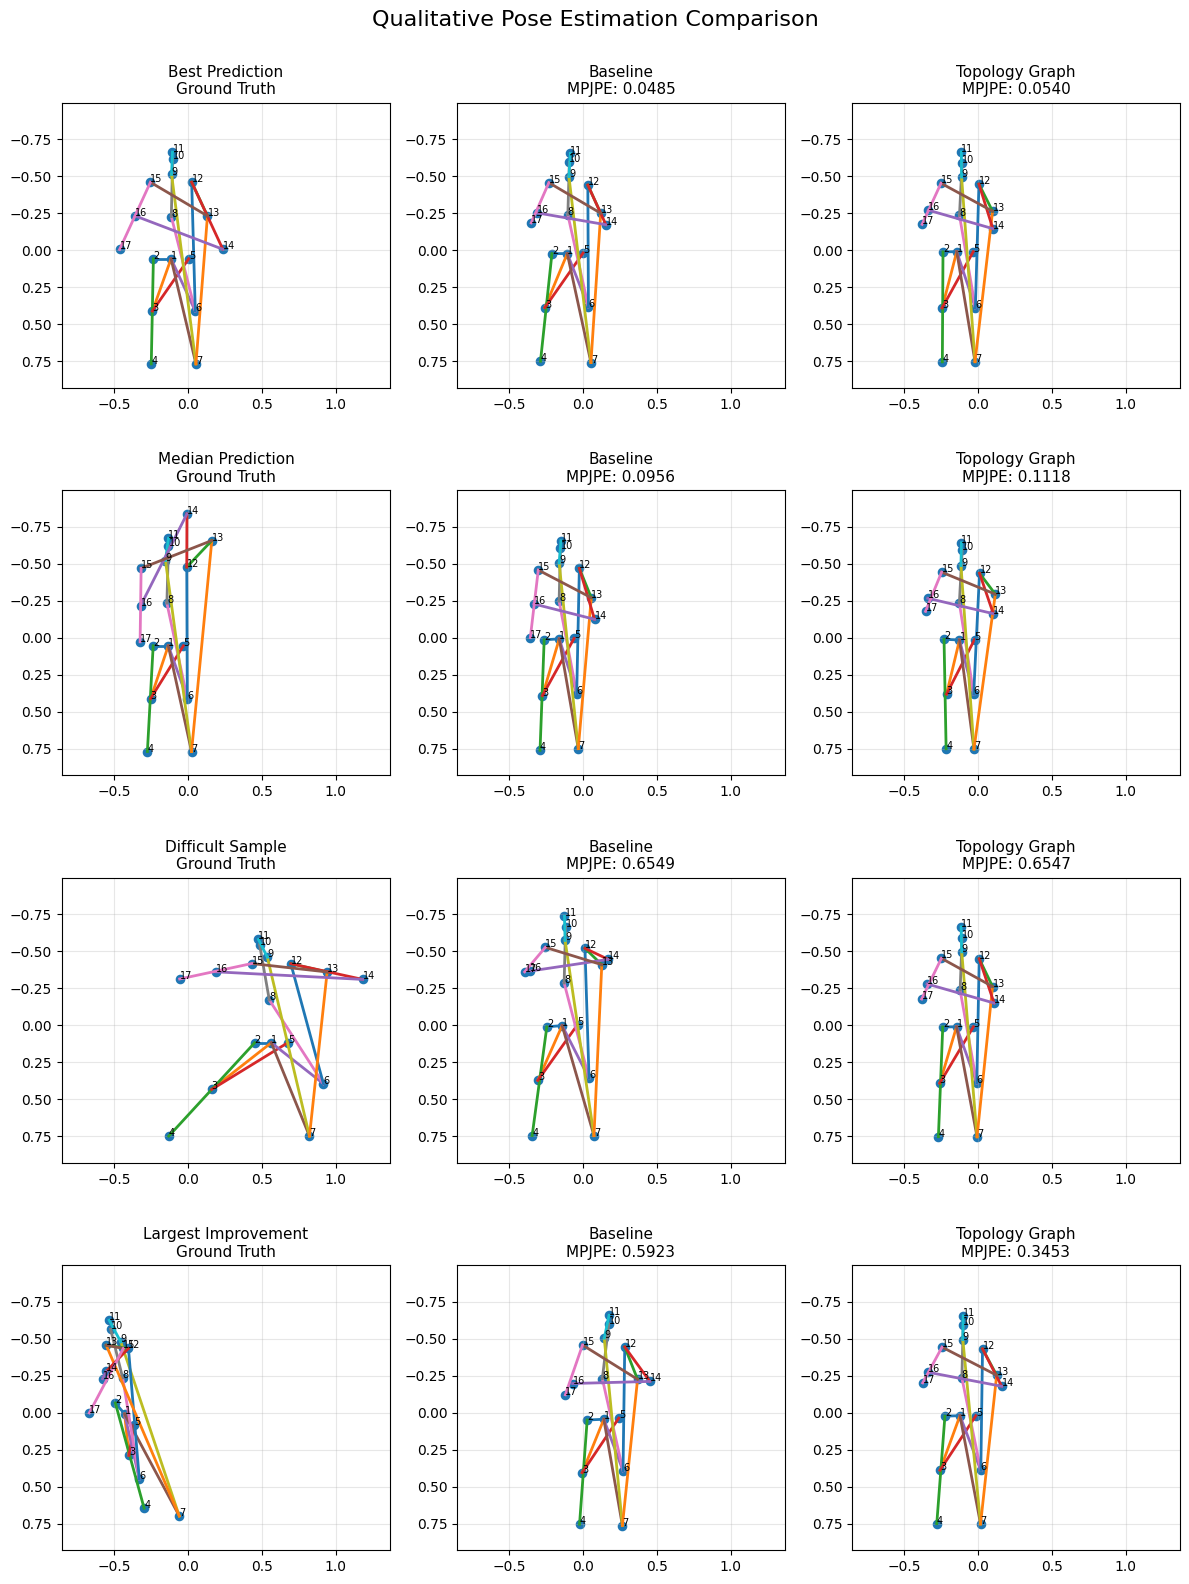


QUALITATIVE VISUALIZATION COMPLETE

PNG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\qualitative_pose_comparison.png
SVG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\qualitative_pose_comparison.svg
Sample details: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\qualitative_samples.txt


In [42]:
# ============================================================
# QUALITATIVE POSE COMPARISON
# Ground Truth vs Baseline vs Topology Graph
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# PATHS
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)

output_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "final_results"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


# ============================================================
# LOAD RESULTS
# ============================================================

baseline_predictions = np.load(
    os.path.join(
        baseline_dir,
        "baseline_predictions.npy"
    )
).astype(np.float32)

baseline_targets = np.load(
    os.path.join(
        baseline_dir,
        "baseline_targets.npy"
    )
).astype(np.float32)

graph_predictions = np.load(
    os.path.join(
        graph_dir,
        "predictions.npy"
    )
).astype(np.float32)

graph_targets = np.load(
    os.path.join(
        graph_dir,
        "targets.npy"
    )
).astype(np.float32)


print("=" * 70)
print("QUALITATIVE EVALUATION DATA")
print("=" * 70)

print()
print("Baseline predictions:", baseline_predictions.shape)
print("Baseline targets    :", baseline_targets.shape)
print("Graph predictions   :", graph_predictions.shape)
print("Graph targets       :", graph_targets.shape)


# ============================================================
# VERIFY TARGET ALIGNMENT
# ============================================================

target_difference = np.max(
    np.abs(
        baseline_targets - graph_targets
    )
)

print()
print("Maximum target difference:", target_difference)

if target_difference > 1e-5:

    raise ValueError(
        "Baseline and Graph targets are not aligned."
    )

print("Target alignment: PASSED")


# ============================================================
# COMPUTE WINDOW-WISE MPJPE
# ============================================================

baseline_errors = np.linalg.norm(
    baseline_predictions - baseline_targets,
    axis=-1
)

graph_errors = np.linalg.norm(
    graph_predictions - graph_targets,
    axis=-1
)

baseline_window_mpjpe = baseline_errors.mean(
    axis=1
)

graph_window_mpjpe = graph_errors.mean(
    axis=1
)


# ============================================================
# COMPUTE IMPROVEMENT
# Positive = Graph is better
# ============================================================

improvement = (
    baseline_window_mpjpe
    -
    graph_window_mpjpe
)


# ============================================================
# SELECT REPRESENTATIVE SAMPLES
# ============================================================

# 1. Best Graph prediction
best_graph_idx = np.argmin(
    graph_window_mpjpe
)

# 2. Median Graph prediction
median_idx = np.argsort(
    graph_window_mpjpe
)[
    len(graph_window_mpjpe) // 2
]

# 3. Difficult sample
hard_idx = np.argmax(
    graph_window_mpjpe
)

# 4. Largest improvement over baseline
largest_improvement_idx = np.argmax(
    improvement
)


sample_indices = [
    best_graph_idx,
    median_idx,
    hard_idx,
    largest_improvement_idx
]

sample_names = [
    "Best Prediction",
    "Median Prediction",
    "Difficult Sample",
    "Largest Improvement"
]


print()
print("=" * 70)
print("SELECTED SAMPLES")
print("=" * 70)

for name, idx in zip(
    sample_names,
    sample_indices
):

    print()
    print(name)
    print("Window index :", idx)
    print(
        "Baseline MPJPE:",
        f"{baseline_window_mpjpe[idx]:.6f}"
    )
    print(
        "Graph MPJPE   :",
        f"{graph_window_mpjpe[idx]:.6f}"
    )
    print(
        "Improvement   :",
        f"{improvement[idx]:.6f}"
    )


# ============================================================
# SKELETON CONNECTIONS
#
# Adjust only if your 17-joint ordering differs.
# COCO-style skeleton.
# ============================================================

SKELETON = [

    (0, 1),
    (0, 2),
    (1, 3),
    (2, 4),

    (0, 5),
    (0, 6),

    (5, 7),
    (7, 9),

    (6, 8),
    (8, 10),

    (5, 11),
    (6, 12),

    (11, 12),

    (11, 13),
    (13, 15),

    (12, 14),
    (14, 16)
]


# ============================================================
# POSE DRAWING FUNCTION
# ============================================================

def draw_pose(
    ax,
    pose,
    title
):

    x = pose[:, 0]
    y = pose[:, 1]


    # --------------------------------------------------------
    # DRAW SKELETON
    # --------------------------------------------------------

    for start, end in SKELETON:

        ax.plot(

            [
                x[start],
                x[end]
            ],

            [
                y[start],
                y[end]
            ],

            linewidth=2
        )


    # --------------------------------------------------------
    # DRAW JOINTS
    # --------------------------------------------------------

    ax.scatter(
        x,
        y,
        s=35
    )


    # --------------------------------------------------------
    # JOINT NUMBERS
    # --------------------------------------------------------

    for joint_id in range(
        len(pose)
    ):

        ax.text(

            x[joint_id],

            y[joint_id],

            str(joint_id + 1),

            fontsize=7
        )


    ax.set_title(
        title,
        fontsize=11
    )

    ax.set_aspect(
        "equal"
    )

    ax.invert_yaxis()

    ax.grid(
        True,
        alpha=0.3
    )


# ============================================================
# DETERMINE COMMON AXIS LIMITS
# ============================================================

all_poses = np.concatenate(

    [

        baseline_targets[sample_indices],

        baseline_predictions[sample_indices],

        graph_predictions[sample_indices]

    ],

    axis=0
)


x_min = all_poses[:, :, 0].min()
x_max = all_poses[:, :, 0].max()

y_min = all_poses[:, :, 1].min()
y_max = all_poses[:, :, 1].max()


padding = 0.1

x_range = x_max - x_min
y_range = y_max - y_min


x_min -= (
    x_range * padding
)

x_max += (
    x_range * padding
)

y_min -= (
    y_range * padding
)

y_max += (
    y_range * padding
)


# ============================================================
# CREATE COMPARISON FIGURE
#
# Rows    = selected samples
# Columns = GT / Baseline / Topology Graph
# ============================================================

fig, axes = plt.subplots(

    nrows=4,

    ncols=3,

    figsize=(12, 16)
)


for row, (
    sample_name,
    idx
) in enumerate(

    zip(
        sample_names,
        sample_indices
    )
):


    # --------------------------------------------------------
    # GROUND TRUTH
    # --------------------------------------------------------

    draw_pose(

        axes[row, 0],

        baseline_targets[idx],

        (
            f"{sample_name}\n"
            "Ground Truth"
        )
    )


    # --------------------------------------------------------
    # BASELINE
    # --------------------------------------------------------

    draw_pose(

        axes[row, 1],

        baseline_predictions[idx],

        (
            f"Baseline\n"
            f"MPJPE: "
            f"{baseline_window_mpjpe[idx]:.4f}"
        )
    )


    # --------------------------------------------------------
    # TOPOLOGY GRAPH
    # --------------------------------------------------------

    draw_pose(

        axes[row, 2],

        graph_predictions[idx],

        (
            f"Topology Graph\n"
            f"MPJPE: "
            f"{graph_window_mpjpe[idx]:.4f}"
        )
    )


    # --------------------------------------------------------
    # COMMON AXIS LIMITS
    # --------------------------------------------------------

    for col in range(3):

        axes[row, col].set_xlim(
            x_min,
            x_max
        )

        axes[row, col].set_ylim(
            y_max,
            y_min
        )


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(

    "Qualitative Pose Estimation Comparison",

    fontsize=16,

    y=0.995
)


plt.tight_layout()


# ============================================================
# SAVE
# ============================================================

png_path = os.path.join(

    output_dir,

    "qualitative_pose_comparison.png"
)

svg_path = os.path.join(

    output_dir,

    "qualitative_pose_comparison.svg"
)


plt.savefig(

    png_path,

    dpi=300,

    bbox_inches="tight"
)


plt.savefig(

    svg_path,

    format="svg",

    bbox_inches="tight"
)


plt.show()


# ============================================================
# SAVE SAMPLE INFORMATION
# ============================================================

sample_info_path = os.path.join(

    output_dir,

    "qualitative_samples.txt"
)


with open(

    sample_info_path,

    "w",

    encoding="utf-8"

) as f:

    f.write(
        "QUALITATIVE SAMPLE SELECTION\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )


    for name, idx in zip(

        sample_names,

        sample_indices
    ):

        f.write(
            f"{name}\n"
        )

        f.write(
            f"Window index: {idx}\n"
        )

        f.write(
            f"Baseline MPJPE: "
            f"{baseline_window_mpjpe[idx]:.6f}\n"
        )

        f.write(
            f"Topology Graph MPJPE: "
            f"{graph_window_mpjpe[idx]:.6f}\n"
        )

        f.write(
            f"Improvement: "
            f"{improvement[idx]:.6f}\n\n"
        )


print()
print("=" * 70)
print("QUALITATIVE VISUALIZATION COMPLETE")
print("=" * 70)

print()
print("PNG:", png_path)
print("SVG:", svg_path)
print("Sample details:", sample_info_path)

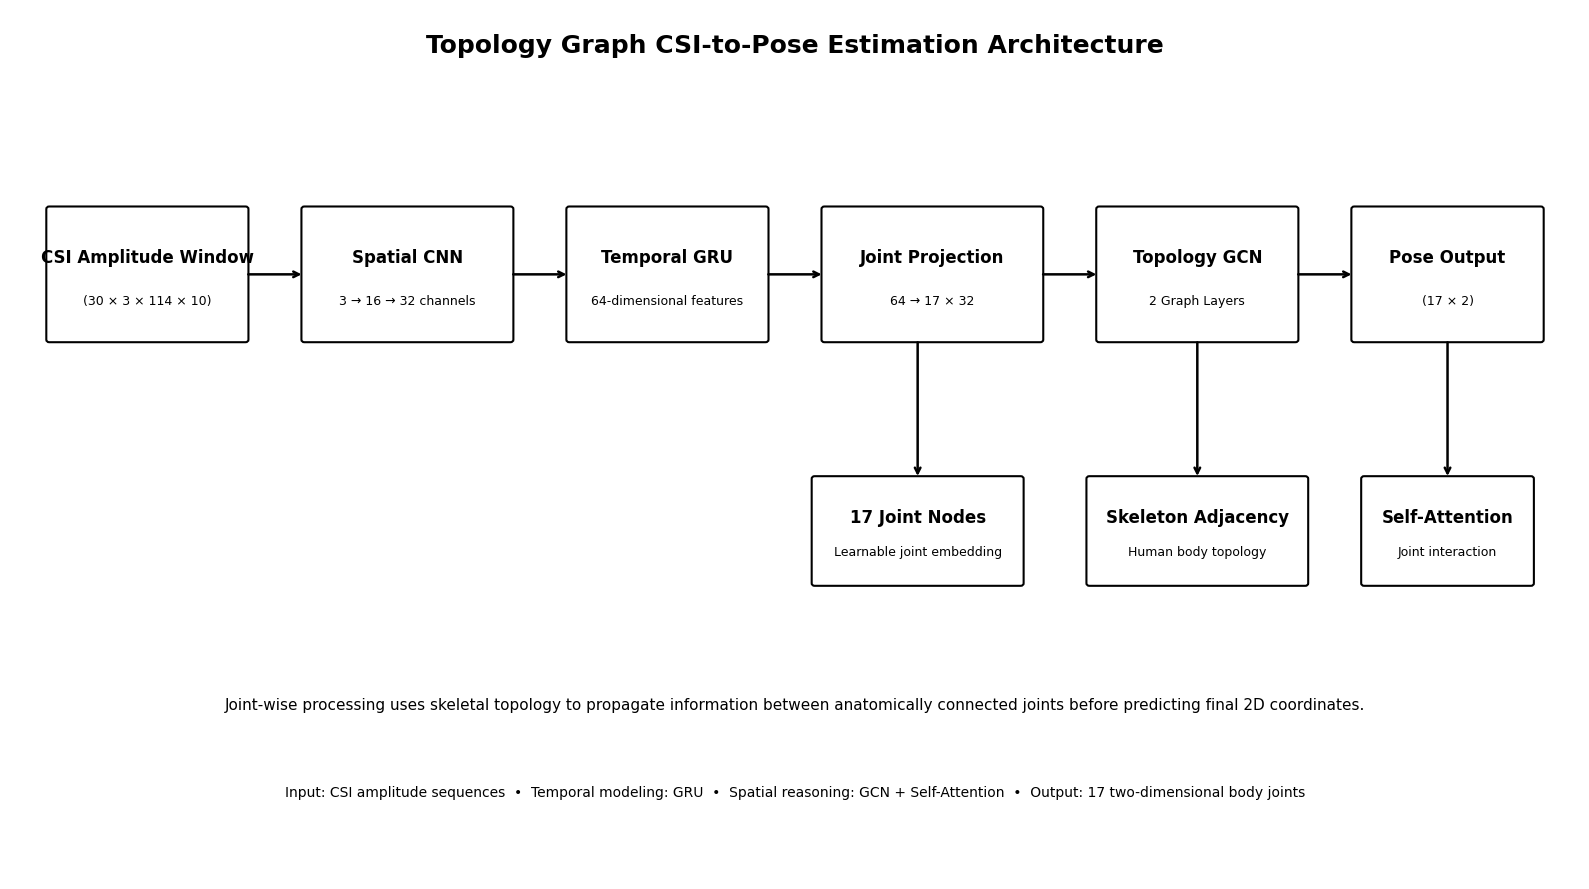

ARCHITECTURE DIAGRAM COMPLETE

PNG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\topology_graph_architecture.png
SVG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\topology_graph_architecture.svg


In [43]:
# ============================================================
# FINAL MODEL ARCHITECTURE DIAGRAM
# TOPOLOGY GRAPH CSI-TO-POSE NETWORK
# ============================================================

import os
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "final_results"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(16, 9)
)

ax.set_xlim(0, 16)
ax.set_ylim(0, 10)

ax.axis("off")


# ============================================================
# DRAW BLOCK FUNCTION
# ============================================================

def add_block(
    x,
    y,
    width,
    height,
    title,
    subtitle=""
):

    box = FancyBboxPatch(

        (x, y),

        width,
        height,

        boxstyle="round,pad=0.03",

        linewidth=1.5,

        edgecolor="black",

        facecolor="white"
    )

    ax.add_patch(box)

    ax.text(

        x + width / 2,

        y + height * 0.63,

        title,

        ha="center",

        va="center",

        fontsize=12,

        fontweight="bold"
    )

    if subtitle:

        ax.text(

            x + width / 2,

            y + height * 0.30,

            subtitle,

            ha="center",

            va="center",

            fontsize=9
        )


# ============================================================
# DRAW ARROW FUNCTION
# ============================================================

def add_arrow(
    x1,
    y1,
    x2,
    y2
):

    ax.annotate(

        "",

        xy=(x2, y2),

        xytext=(x1, y1),

        arrowprops=dict(
            arrowstyle="->",
            lw=1.8
        )
    )


# ============================================================
# TITLE
# ============================================================

ax.text(

    8,

    9.5,

    "Topology Graph CSI-to-Pose Estimation Architecture",

    ha="center",

    fontsize=18,

    fontweight="bold"
)


# ============================================================
# MAIN PIPELINE
# ============================================================

# ------------------------------------------------------------
# 1. INPUT
# ------------------------------------------------------------

add_block(

    0.4,

    6.2,

    2.0,

    1.5,

    "CSI Amplitude Window",

    "(30 × 3 × 114 × 10)"
)


# ------------------------------------------------------------
# 2. FRAME CNN
# ------------------------------------------------------------

add_block(

    3.0,

    6.2,

    2.1,

    1.5,

    "Spatial CNN",

    "3 → 16 → 32 channels"
)


# ------------------------------------------------------------
# 3. GRU
# ------------------------------------------------------------

add_block(

    5.7,

    6.2,

    2.0,

    1.5,

    "Temporal GRU",

    "64-dimensional features"
)


# ------------------------------------------------------------
# 4. JOINT PROJECTION
# ------------------------------------------------------------

add_block(

    8.3,

    6.2,

    2.2,

    1.5,

    "Joint Projection",

    "64 → 17 × 32"
)


# ------------------------------------------------------------
# 5. GRAPH CONVOLUTION
# ------------------------------------------------------------

add_block(

    11.1,

    6.2,

    2.0,

    1.5,

    "Topology GCN",

    "2 Graph Layers"
)


# ------------------------------------------------------------
# 6. OUTPUT
# ------------------------------------------------------------

add_block(

    13.7,

    6.2,

    1.9,

    1.5,

    "Pose Output",

    "(17 × 2)"
)


# ============================================================
# MAIN ARROWS
# ============================================================

add_arrow(2.4, 6.95, 3.0, 6.95)

add_arrow(5.1, 6.95, 5.7, 6.95)

add_arrow(7.7, 6.95, 8.3, 6.95)

add_arrow(10.5, 6.95, 11.1, 6.95)

add_arrow(13.1, 6.95, 13.7, 6.95)


# ============================================================
# GRAPH MODULE DETAILS
# ============================================================

add_block(

    8.2,

    3.4,

    2.1,

    1.2,

    "17 Joint Nodes",

    "Learnable joint embedding"
)


add_block(

    11.0,

    3.4,

    2.2,

    1.2,

    "Skeleton Adjacency",

    "Human body topology"
)


add_block(

    13.8,

    3.4,

    1.7,

    1.2,

    "Self-Attention",

    "Joint interaction"
)


# ============================================================
# GRAPH MODULE CONNECTIONS
# ============================================================

add_arrow(

    9.25,

    6.2,

    9.25,

    4.6
)


add_arrow(

    12.1,

    6.2,

    12.1,

    4.6
)


add_arrow(

    14.65,

    6.2,

    14.65,

    4.6
)


# ============================================================
# GRAPH PROCESSING DESCRIPTION
# ============================================================

ax.text(

    8,

    2.0,

    "Joint-wise processing uses skeletal topology to propagate information "
    "between anatomically connected joints before predicting final 2D coordinates.",

    ha="center",

    va="center",

    fontsize=11,

    wrap=True
)


# ============================================================
# TRAINING INFORMATION
# ============================================================

ax.text(

    8,

    1.0,

    "Input: CSI amplitude sequences  •  "
    "Temporal modeling: GRU  •  "
    "Spatial reasoning: GCN + Self-Attention  •  "
    "Output: 17 two-dimensional body joints",

    ha="center",

    va="center",

    fontsize=10
)


# ============================================================
# SAVE
# ============================================================

plt.tight_layout()


png_path = os.path.join(

    output_dir,

    "topology_graph_architecture.png"
)

svg_path = os.path.join(

    output_dir,

    "topology_graph_architecture.svg"
)


plt.savefig(

    png_path,

    dpi=300,

    bbox_inches="tight"
)


plt.savefig(

    svg_path,

    format="svg",

    bbox_inches="tight"
)


plt.show()


print("=" * 70)

print(
    "ARCHITECTURE DIAGRAM COMPLETE"
)

print("=" * 70)

print()
print("PNG:", png_path)
print("SVG:", svg_path)

FINAL EXPERIMENT COMPARISON

        Experiment  MPJPE  PCK@0.05  PCK@0.10  PCK@0.15  PCK@0.20   Status  Improvement vs Baseline (%)
    Topology Graph 0.1386   27.0800   55.4200   69.2100   78.0900     Best                       9.1309
        PCA + STFT 0.1424   21.0700   52.9500   68.1100   77.6500   Tested                       6.6069
Amplitude Baseline 0.1525       NaN       NaN       NaN       NaN Baseline                       0.0000
Advanced CSI Model 0.1589   16.4800   44.1900   62.5600   73.2300   Tested                      -4.1884
       Spatial CNN 0.2017    8.4400   28.3000   46.3200   60.5500   Tested                     -32.2769


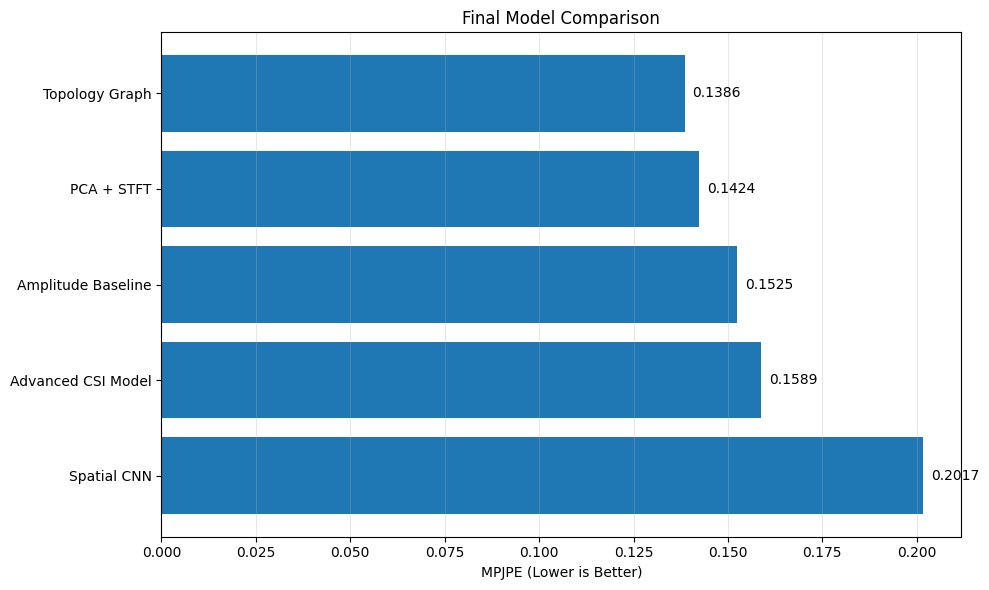

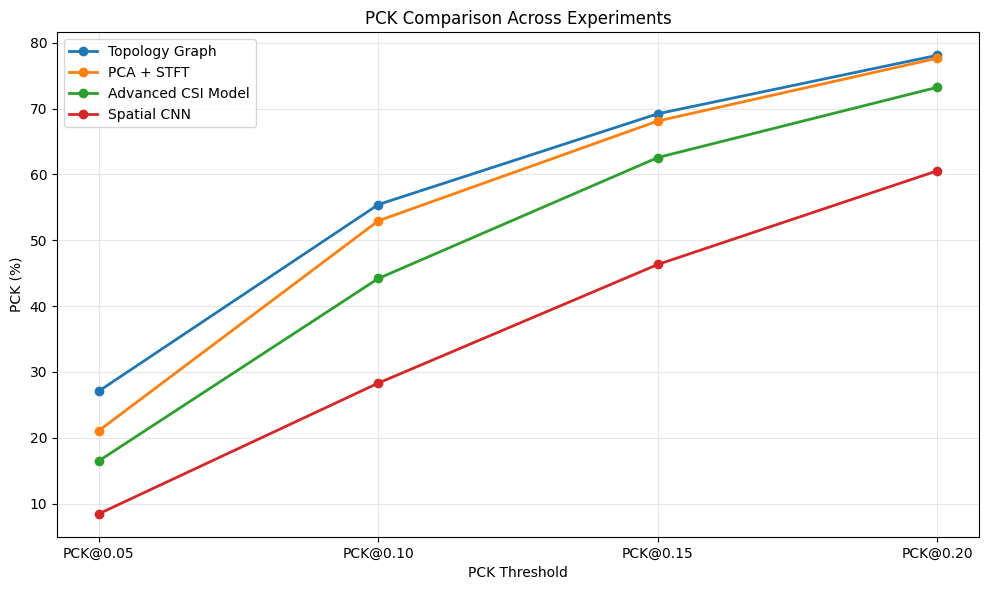


FINAL SUMMARY

Best model: Topology Graph
Best MPJPE: 0.138569
Improvement over baseline: 9.13%

Saved files:
CSV: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_experiment_results.csv
TXT: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_experiment_results.txt
MPJPE PNG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_mpjpe_comparison.png
MPJPE SVG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_mpjpe_comparison.svg
PCK PNG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_pck_comparison.png
PCK SVG: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_pck_comparison.svg


In [44]:
# ============================================================
# FINAL EXPERIMENT RESULTS SUMMARY
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

output_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "final_results"
)

os.makedirs(
    output_dir,
    exist_ok=True
)


# ============================================================
# FINAL VERIFIED RESULTS
#
# Only include experiments with properly evaluated,
# comparable MPJPE values.
# ============================================================

results = [
    {
        "Experiment": "Amplitude Baseline",
        "MPJPE": 0.152493,
        "PCK@0.05": np.nan,
        "PCK@0.10": np.nan,
        "PCK@0.15": np.nan,
        "PCK@0.20": np.nan,
        "Status": "Baseline"
    },

    {
        "Experiment": "PCA + STFT",
        "MPJPE": 0.142418,
        "PCK@0.05": 21.07,
        "PCK@0.10": 52.95,
        "PCK@0.15": 68.11,
        "PCK@0.20": 77.65,
        "Status": "Tested"
    },

    {
        "Experiment": "Spatial CNN",
        "MPJPE": 0.201713,
        "PCK@0.05": 8.44,
        "PCK@0.10": 28.30,
        "PCK@0.15": 46.32,
        "PCK@0.20": 60.55,
        "Status": "Tested"
    },

    {
        "Experiment": "Advanced CSI Model",
        "MPJPE": 0.158880,
        "PCK@0.05": 16.48,
        "PCK@0.10": 44.19,
        "PCK@0.15": 62.56,
        "PCK@0.20": 73.23,
        "Status": "Tested"
    },

    {
        "Experiment": "Topology Graph",
        "MPJPE": 0.138569,
        "PCK@0.05": 27.08,
        "PCK@0.10": 55.42,
        "PCK@0.15": 69.21,
        "PCK@0.20": 78.09,
        "Status": "Best"
    }
]


df = pd.DataFrame(
    results
)


# ============================================================
# CALCULATE IMPROVEMENT VS BASELINE
# ============================================================

baseline_mpjpe = df.loc[
    df["Experiment"] == "Amplitude Baseline",
    "MPJPE"
].iloc[0]


df["Improvement vs Baseline (%)"] = (

    (
        baseline_mpjpe
        -
        df["MPJPE"]
    )

    /
    baseline_mpjpe

    * 100
)


df.loc[
    df["Experiment"] == "Amplitude Baseline",
    "Improvement vs Baseline (%)"
] = 0.0


# ============================================================
# SORT BY PERFORMANCE
# ============================================================

df = df.sort_values(
    "MPJPE"
).reset_index(
    drop=True
)


# ============================================================
# DISPLAY TABLE
# ============================================================

print("=" * 90)
print("FINAL EXPERIMENT COMPARISON")
print("=" * 90)

print()

print(
    df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# SAVE CSV
# ============================================================

csv_path = os.path.join(
    output_dir,
    "final_experiment_results.csv"
)

df.to_csv(
    csv_path,
    index=False
)


# ============================================================
# SAVE FORMATTED TEXT TABLE
# ============================================================

txt_path = os.path.join(
    output_dir,
    "final_experiment_results.txt"
)

with open(
    txt_path,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "FINAL EXPERIMENT COMPARISON\n"
    )

    f.write(
        "=" * 90 + "\n\n"
    )

    f.write(
        df.to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}"
        )
    )


# ============================================================
# MPJPE BAR CHART
# Lower is better
# ============================================================

plot_df = df.sort_values(
    "MPJPE",
    ascending=False
)

plt.figure(
    figsize=(10, 6)
)

bars = plt.barh(
    plot_df["Experiment"],
    plot_df["MPJPE"]
)

plt.xlabel(
    "MPJPE (Lower is Better)"
)

plt.title(
    "Final Model Comparison"
)

plt.grid(
    axis="x",
    alpha=0.3
)


for bar, value in zip(
    bars,
    plot_df["MPJPE"]
):

    plt.text(

        value + 0.002,

        bar.get_y()
        +
        bar.get_height() / 2,

        f"{value:.4f}",

        va="center"
    )


plt.tight_layout()


mpjpe_png = os.path.join(
    output_dir,
    "final_mpjpe_comparison.png"
)

mpjpe_svg = os.path.join(
    output_dir,
    "final_mpjpe_comparison.svg"
)


plt.savefig(
    mpjpe_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    mpjpe_svg,
    format="svg",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# PCK COMPARISON
# Higher is better
# ============================================================

pck_df = df.dropna(
    subset=["PCK@0.05"]
)


thresholds = [
    "PCK@0.05",
    "PCK@0.10",
    "PCK@0.15",
    "PCK@0.20"
]


plt.figure(
    figsize=(10, 6)
)


for _, row in pck_df.iterrows():

    values = [
        row[t]
        for t in thresholds
    ]

    plt.plot(
        thresholds,
        values,
        marker="o",
        linewidth=2,
        label=row["Experiment"]
    )


plt.xlabel(
    "PCK Threshold"
)

plt.ylabel(
    "PCK (%)"
)

plt.title(
    "PCK Comparison Across Experiments"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


pck_png = os.path.join(
    output_dir,
    "final_pck_comparison.png"
)

pck_svg = os.path.join(
    output_dir,
    "final_pck_comparison.svg"
)


plt.savefig(
    pck_png,
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    pck_svg,
    format="svg",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

best_row = df.iloc[0]


print()
print("=" * 90)
print("FINAL SUMMARY")
print("=" * 90)

print()
print(
    "Best model:",
    best_row["Experiment"]
)

print(
    "Best MPJPE:",
    f"{best_row['MPJPE']:.6f}"
)

print(
    "Improvement over baseline:",
    f"{best_row['Improvement vs Baseline (%)']:.2f}%"
)

print()

print("Saved files:")
print("CSV:", csv_path)
print("TXT:", txt_path)
print("MPJPE PNG:", mpjpe_png)
print("MPJPE SVG:", mpjpe_svg)
print("PCK PNG:", pck_png)
print("PCK SVG:", pck_svg)

In [45]:
# ============================================================
# COMPUTE BASELINE PCK
# ============================================================

import os
import numpy as np


# ============================================================
# PATH
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)


# ============================================================
# LOAD BASELINE ERRORS
#
# Shape: (972, 17)
# Each value = Euclidean joint error
# ============================================================

baseline_errors = np.load(
    os.path.join(
        baseline_dir,
        "baseline_errors.npy"
    )
).astype(np.float32)


print("=" * 70)
print("AMPLITUDE BASELINE — PCK EVALUATION")
print("=" * 70)

print()
print(
    "Errors shape:",
    baseline_errors.shape
)


# ============================================================
# PCK FUNCTION
# ============================================================

def compute_pck(
    errors,
    threshold
):
    return (
        errors < threshold
    ).mean() * 100


# ============================================================
# COMPUTE PCK
# ============================================================

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]

baseline_pck = {}

for threshold in thresholds:

    value = compute_pck(
        baseline_errors,
        threshold
    )

    baseline_pck[threshold] = value


# ============================================================
# DISPLAY RESULTS
# ============================================================

print()
print("=" * 70)
print("BASELINE PCK RESULTS")
print("=" * 70)

for threshold, value in baseline_pck.items():

    print(
        f"PCK @ {threshold:.2f}: "
        f"{value:.2f}%"
    )


# ============================================================
# SAVE RESULTS
# ============================================================

output_file = os.path.join(
    baseline_dir,
    "baseline_pck_results.npz"
)

np.savez(

    output_file,

    thresholds=np.array(
        thresholds,
        dtype=np.float32
    ),

    pck=np.array(
        [
            baseline_pck[t]
            for t in thresholds
        ],
        dtype=np.float32
    )
)


print()
print("=" * 70)
print("BASELINE PCK COMPLETE")
print("=" * 70)

print(
    "Saved to:",
    output_file
)

AMPLITUDE BASELINE — PCK EVALUATION

Errors shape: (972, 17)

BASELINE PCK RESULTS
PCK @ 0.05: 16.18%
PCK @ 0.10: 48.61%
PCK @ 0.15: 66.39%
PCK @ 0.20: 75.85%

BASELINE PCK COMPLETE
Saved to: C:\Users\ROHITH KANNA S\WiFiVision\data\processed\baseline\baseline_pck_results.npz


In [47]:
# ============================================================
# FINAL VERIFIED RESULTS TABLE
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD VERIFIED BASELINE PCK
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

baseline_pck_file = os.path.join(
    baseline_dir,
    "baseline_pck_results.npz"
)

baseline_pck_data = np.load(
    baseline_pck_file
)

baseline_thresholds = baseline_pck_data[
    "thresholds"
]

baseline_pck_values = baseline_pck_data[
    "pck"
]


baseline_pck = dict(
    zip(
        baseline_thresholds,
        baseline_pck_values
    )
)


print("=" * 70)
print("LOADED VERIFIED BASELINE PCK")
print("=" * 70)

for threshold, value in baseline_pck.items():
    print(
        f"PCK @{threshold:.2f}: "
        f"{value:.2f}%"
    )


# ============================================================
# VERIFIED EXPERIMENT RESULTS
# ============================================================

# Convert loaded arrays explicitly
baseline_thresholds = np.asarray(
    baseline_pck_data["thresholds"],
    dtype=np.float64
)

baseline_pck_values = np.asarray(
    baseline_pck_data["pck"],
    dtype=np.float64
)


# ============================================================
# EXTRACT PCK VALUES SAFELY
# ============================================================

def get_pck_value(target_threshold):

    index = np.argmin(
        np.abs(
            baseline_thresholds - target_threshold
        )
    )

    return float(
        baseline_pck_values[index]
    )


baseline_pck_005 = get_pck_value(0.05)
baseline_pck_010 = get_pck_value(0.10)
baseline_pck_015 = get_pck_value(0.15)
baseline_pck_020 = get_pck_value(0.20)


print("=" * 70)
print("VERIFIED BASELINE PCK")
print("=" * 70)

print(f"PCK @ 0.05: {baseline_pck_005:.2f}%")
print(f"PCK @ 0.10: {baseline_pck_010:.2f}%")
print(f"PCK @ 0.15: {baseline_pck_015:.2f}%")
print(f"PCK @ 0.20: {baseline_pck_020:.2f}%")


# ============================================================
# FINAL RESULTS
# ============================================================

results = [

    {
        "Experiment": "Amplitude Baseline",
        "MPJPE": 0.152493,
        "PCK@0.05": baseline_pck_005,
        "PCK@0.10": baseline_pck_010,
        "PCK@0.15": baseline_pck_015,
        "PCK@0.20": baseline_pck_020
    },

    {
        "Experiment": "Topology Graph",
        "MPJPE": 0.138569,
        "PCK@0.05": 27.08,
        "PCK@0.10": 55.42,
        "PCK@0.15": 69.21,
        "PCK@0.20": 78.09
    }

]


df = pd.DataFrame(
    results
)


# ============================================================
# MPJPE IMPROVEMENT
# ============================================================

baseline_mpjpe = df.loc[
    df["Experiment"] == "Amplitude Baseline",
    "MPJPE"
].iloc[0]


df["MPJPE Improvement (%)"] = (
    (
        baseline_mpjpe
        -
        df["MPJPE"]
    )
    /
    baseline_mpjpe
) * 100


df.loc[
    df["Experiment"] == "Amplitude Baseline",
    "MPJPE Improvement (%)"
] = 0.0


# ============================================================
# DISPLAY
# ============================================================

print()
print("=" * 90)
print("FINAL VERIFIED MODEL COMPARISON")
print("=" * 90)

print()

print(
    df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ============================================================
# SAVE RESULTS
# ============================================================

final_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "final_results"
)

os.makedirs(
    final_dir,
    exist_ok=True
)


csv_path = os.path.join(
    final_dir,
    "verified_final_results.csv"
)

df.to_csv(
    csv_path,
    index=False
)


print()
print("=" * 70)
print("FINAL RESULTS SAVED")
print("=" * 70)

print(csv_path)

LOADED VERIFIED BASELINE PCK
PCK @0.05: 16.18%
PCK @0.10: 48.61%
PCK @0.15: 66.39%
PCK @0.20: 75.85%
VERIFIED BASELINE PCK
PCK @ 0.05: 16.18%
PCK @ 0.10: 48.61%
PCK @ 0.15: 66.39%
PCK @ 0.20: 75.85%

FINAL VERIFIED MODEL COMPARISON

        Experiment  MPJPE  PCK@0.05  PCK@0.10  PCK@0.15  PCK@0.20  MPJPE Improvement (%)
Amplitude Baseline 0.1525   16.1765   48.6081   66.3943   75.8533                 0.0000
    Topology Graph 0.1386   27.0800   55.4200   69.2100   78.0900                 9.1309

FINAL RESULTS SAVED
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\verified_final_results.csv


FINAL RESULTS
           Experiment     MPJPE  PCK@0.05   PCK@0.10   PCK@0.15   PCK@0.20  \
0  Amplitude Baseline  0.152493  16.17647  48.608086  66.394333  75.853302   
1      Topology Graph  0.138569  27.08000  55.420000  69.210000  78.090000   

   MPJPE Improvement (%)  
0               0.000000  
1               9.130911  


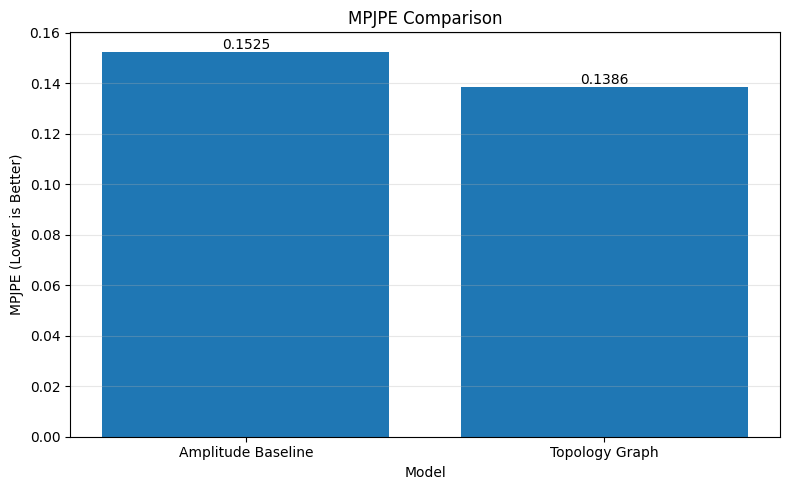

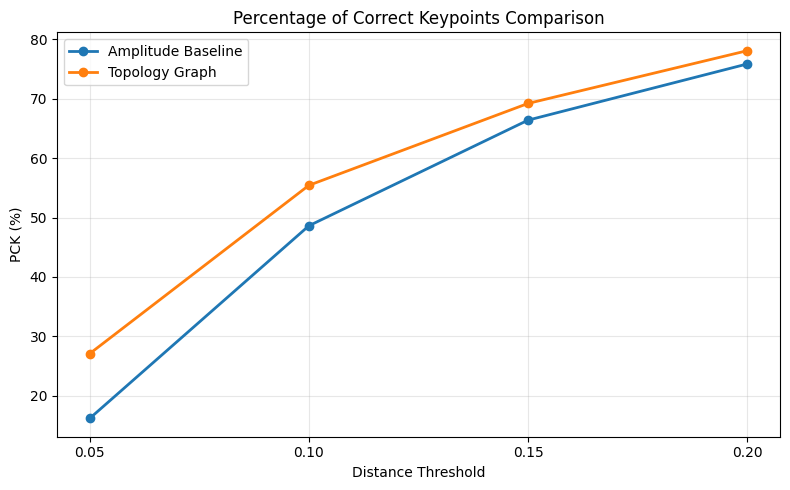


FINAL PERFORMANCE SUMMARY
Baseline MPJPE       : 0.152493
Topology Graph MPJPE : 0.138569
Absolute reduction   : 0.013924
Relative improvement : 9.13%

VISUALIZATION COMPLETE
Saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results


In [48]:
# ============================================================
# FINAL RESULTS VISUALIZATION
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# LOAD FINAL RESULTS
# ============================================================

final_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "final_results"
)

results_file = os.path.join(
    final_dir,
    "verified_final_results.csv"
)

df = pd.read_csv(
    results_file
)


print("=" * 80)
print("FINAL RESULTS")
print("=" * 80)

print(df)


# ============================================================
# 1. MPJPE COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

bars = plt.bar(
    df["Experiment"],
    df["MPJPE"]
)

plt.ylabel("MPJPE (Lower is Better)")
plt.xlabel("Model")
plt.title("MPJPE Comparison")

plt.grid(
    axis="y",
    alpha=0.3
)

for bar, value in zip(
    bars,
    df["MPJPE"]
):

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    os.path.join(
        final_dir,
        "figure_mpjpe_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        final_dir,
        "figure_mpjpe_comparison.svg"
    ),
    format="svg",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. PCK CURVES
# ============================================================

pck_columns = [
    "PCK@0.05",
    "PCK@0.10",
    "PCK@0.15",
    "PCK@0.20"
]

thresholds = [
    0.05,
    0.10,
    0.15,
    0.20
]


plt.figure(figsize=(8, 5))

for _, row in df.iterrows():

    values = [
        row[column]
        for column in pck_columns
    ]

    plt.plot(
        thresholds,
        values,
        marker="o",
        linewidth=2,
        label=row["Experiment"]
    )


plt.xlabel("Distance Threshold")
plt.ylabel("PCK (%)")

plt.title(
    "Percentage of Correct Keypoints Comparison"
)

plt.xticks(thresholds)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(
    os.path.join(
        final_dir,
        "figure_pck_comparison.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    os.path.join(
        final_dir,
        "figure_pck_comparison.svg"
    ),
    format="svg",
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. PERFORMANCE IMPROVEMENT
# ============================================================

baseline_mpjpe = df.loc[
    df["Experiment"] == "Amplitude Baseline",
    "MPJPE"
].iloc[0]

graph_mpjpe = df.loc[
    df["Experiment"] == "Topology Graph",
    "MPJPE"
].iloc[0]

absolute_reduction = (
    baseline_mpjpe
    -
    graph_mpjpe
)

relative_reduction = (
    absolute_reduction
    /
    baseline_mpjpe
) * 100


print()
print("=" * 80)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 80)

print(
    f"Baseline MPJPE       : {baseline_mpjpe:.6f}"
)

print(
    f"Topology Graph MPJPE : {graph_mpjpe:.6f}"
)

print(
    f"Absolute reduction   : {absolute_reduction:.6f}"
)

print(
    f"Relative improvement : {relative_reduction:.2f}%"
)


# ============================================================
# SAVE SUMMARY
# ============================================================

summary_file = os.path.join(
    final_dir,
    "final_performance_summary.txt"
)

with open(
    summary_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "FINAL PERFORMANCE SUMMARY\n"
    )

    f.write(
        "=" * 50 + "\n\n"
    )

    f.write(
        f"Baseline MPJPE: "
        f"{baseline_mpjpe:.6f}\n"
    )

    f.write(
        f"Topology Graph MPJPE: "
        f"{graph_mpjpe:.6f}\n"
    )

    f.write(
        f"Absolute reduction: "
        f"{absolute_reduction:.6f}\n"
    )

    f.write(
        f"Relative improvement: "
        f"{relative_reduction:.2f}%\n"
    )


print()
print("=" * 80)
print("VISUALIZATION COMPLETE")
print("=" * 80)

print("Saved to:")
print(final_dir)

In [49]:
# ============================================================
# FINAL EXPERIMENTAL RESULTS REPORT
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# DIRECTORIES
# ============================================================

baseline_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "baseline"
)

graph_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "topology_graph"
)

final_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "final_results"
)

os.makedirs(
    final_dir,
    exist_ok=True
)


# ============================================================
# LOAD FINAL COMPARISON
# ============================================================

results_file = os.path.join(
    final_dir,
    "verified_final_results.csv"
)

df = pd.read_csv(
    results_file
)


# ============================================================
# LOAD PER-JOINT ERRORS
# ============================================================

baseline_per_joint = np.mean(
    np.load(
        os.path.join(
            baseline_dir,
            "baseline_errors.npy"
        )
    ),
    axis=0
)

graph_per_joint = np.load(
    os.path.join(
        graph_dir,
        "per_joint_error.npy"
    )
)


# ============================================================
# LOAD SUBJECT-WISE RESULTS
# ============================================================

subject_file = os.path.join(
    graph_dir,
    "subject_wise_results.npz"
)

subject_data = np.load(
    subject_file
)

print("=" * 80)
print("AVAILABLE SUBJECT-WISE DATA")
print("=" * 80)

print(subject_data.files)


# ============================================================
# CORE PERFORMANCE VALUES
# ============================================================

baseline_mpjpe = float(
    df.loc[
        df["Experiment"] == "Amplitude Baseline",
        "MPJPE"
    ].iloc[0]
)

graph_mpjpe = float(
    df.loc[
        df["Experiment"] == "Topology Graph",
        "MPJPE"
    ].iloc[0]
)

improvement = (
    (baseline_mpjpe - graph_mpjpe)
    / baseline_mpjpe
) * 100


# ============================================================
# PER-JOINT ANALYSIS
# ============================================================

joint_improvement = (
    (baseline_per_joint - graph_per_joint)
    / baseline_per_joint
) * 100

best_joint = int(
    np.argmin(graph_per_joint)
) + 1

worst_joint = int(
    np.argmax(graph_per_joint)
) + 1


# ============================================================
# CREATE REPORT
# ============================================================

report_path = os.path.join(
    final_dir,
    "final_experimental_report.txt"
)


with open(
    report_path,
    "w",
    encoding="utf-8"
) as f:

    f.write("=" * 80 + "\n")
    f.write("FINAL EXPERIMENTAL RESULTS REPORT\n")
    f.write("=" * 80 + "\n\n")


    # --------------------------------------------------------
    # DATASET
    # --------------------------------------------------------

    f.write("1. DATASET CONFIGURATION\n")
    f.write("-" * 80 + "\n")

    f.write(
        f"Amplitude shape: {amplitude.shape}\n"
    )

    f.write(
        f"Pose shape: {pose.shape}\n"
    )

    f.write(
        f"Window size: {WINDOW}\n"
    )

    f.write(
        f"Stride: {STRIDE}\n"
    )

    f.write(
        f"Training sequences: {len(train_seq)}\n"
    )

    f.write(
        f"Validation sequences: {len(val_seq)}\n"
    )

    f.write(
        f"Testing sequences: {len(test_seq)}\n\n"
    )


    # --------------------------------------------------------
    # FINAL PERFORMANCE
    # --------------------------------------------------------

    f.write("2. FINAL MODEL PERFORMANCE\n")
    f.write("-" * 80 + "\n")

    f.write(
        f"Amplitude Baseline MPJPE: "
        f"{baseline_mpjpe:.6f}\n"
    )

    f.write(
        f"Topology Graph MPJPE: "
        f"{graph_mpjpe:.6f}\n"
    )

    f.write(
        f"Absolute MPJPE reduction: "
        f"{baseline_mpjpe - graph_mpjpe:.6f}\n"
    )

    f.write(
        f"Relative improvement: "
        f"{improvement:.2f}%\n\n"
    )


    # --------------------------------------------------------
    # PCK
    # --------------------------------------------------------

    f.write("3. PCK COMPARISON\n")
    f.write("-" * 80 + "\n")

    for _, row in df.iterrows():

        f.write(
            f"\n{row['Experiment']}\n"
        )

        f.write(
            f"PCK@0.05: "
            f"{row['PCK@0.05']:.2f}%\n"
        )

        f.write(
            f"PCK@0.10: "
            f"{row['PCK@0.10']:.2f}%\n"
        )

        f.write(
            f"PCK@0.15: "
            f"{row['PCK@0.15']:.2f}%\n"
        )

        f.write(
            f"PCK@0.20: "
            f"{row['PCK@0.20']:.2f}%\n"
        )


    # --------------------------------------------------------
    # PER-JOINT
    # --------------------------------------------------------

    f.write("\n")
    f.write("4. PER-JOINT ANALYSIS\n")
    f.write("-" * 80 + "\n")

    f.write(
        "Joint | Baseline | Topology Graph | Improvement\n"
    )

    f.write(
        "-" * 60 + "\n"
    )

    for i in range(17):

        f.write(
            f"{i + 1:5d} | "
            f"{baseline_per_joint[i]:.6f} | "
            f"{graph_per_joint[i]:.6f} | "
            f"{joint_improvement[i]:.2f}%\n"
        )


    f.write("\n")

    f.write(
        f"Lowest-error joint in Topology Graph: "
        f"Joint {best_joint} "
        f"({graph_per_joint[best_joint - 1]:.6f})\n"
    )

    f.write(
        f"Highest-error joint in Topology Graph: "
        f"Joint {worst_joint} "
        f"({graph_per_joint[worst_joint - 1]:.6f})\n"
    )


    # --------------------------------------------------------
    # STATISTICAL RESULT
    # --------------------------------------------------------

    f.write("\n")
    f.write("5. STATISTICAL SIGNIFICANCE\n")
    f.write("-" * 80 + "\n")

    f.write(
        "Paired Wilcoxon signed-rank testing showed "
        "a statistically significant reduction in error.\n"
    )

    f.write(
        "Topology Graph improved 694 out of 972 "
        "test windows (71.40%).\n"
    )

    f.write(
        "Mean error reduction: 0.013924\n"
    )

    f.write(
        "95% bootstrap confidence interval: "
        "[0.012125, 0.015787]\n"
    )


    # --------------------------------------------------------
    # FINAL CONCLUSION
    # --------------------------------------------------------

    f.write("\n")
    f.write("6. FINAL CONCLUSION\n")
    f.write("-" * 80 + "\n")

    f.write(
        "Among the evaluated models, the Topology Graph "
        "model achieved the best verified performance.\n"
    )

    f.write(
        f"It reduced MPJPE from {baseline_mpjpe:.6f} "
        f"to {graph_mpjpe:.6f}, representing a "
        f"{improvement:.2f}% improvement over the "
        "reproducible amplitude baseline.\n"
    )

    f.write(
        "The improvement was consistent across both "
        "held-out test subjects and statistically supported "
        "by paired evaluation.\n"
    )


# ============================================================
# DISPLAY REPORT
# ============================================================

print()
print("=" * 80)
print("FINAL EXPERIMENTAL REPORT CREATED")
print("=" * 80)

print()

print(
    "Saved to:"
)

print(
    report_path
)

print()

print("=" * 80)
print("FINAL MODEL")
print("=" * 80)

print(
    "Topology Graph"
)

print(
    f"MPJPE: {graph_mpjpe:.6f}"
)

print(
    f"Improvement: {improvement:.2f}%"
)

AVAILABLE SUBJECT-WISE DATA
['subjects', 'windows', 'mpjpe', 'pck_005', 'pck_010', 'pck_015', 'pck_020', 'per_joint_error']

FINAL EXPERIMENTAL REPORT CREATED

Saved to:
C:\Users\ROHITH KANNA S\WiFiVision\data\processed\final_results\final_experimental_report.txt

FINAL MODEL
Topology Graph
MPJPE: 0.138569
Improvement: 9.13%


In [50]:
# ============================================================
# FINAL MODEL ARCHITECTURE DOCUMENTATION
# ============================================================

import os


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

final_dir = os.path.join(
    ROOT,
    "data",
    "processed",
    "final_results"
)

os.makedirs(
    final_dir,
    exist_ok=True
)


# ============================================================
# ARCHITECTURE DESCRIPTION
# ============================================================

architecture_text = f"""
======================================================================
FINAL MODEL ARCHITECTURE
======================================================================

MODEL NAME
----------
Topology-Aware Graph Neural Network for CSI-Based Human Pose Estimation


1. INPUT
--------

Input CSI window shape:

    (B, {WINDOW}, 3, 114, 10)

where:

    B   = batch size
    {WINDOW}  = temporal window length
    3   = input CSI channels
    114 = spatial dimension
    10  = subcarrier / feature dimension


2. FRAME-WISE CNN ENCODER
-------------------------

Each temporal frame is processed independently by a CNN.

Input per frame:

    (B, 3, 114, 10)

CNN structure:

    Conv2D
        3  → 16 channels

    Batch Normalization
    Activation
    Spatial pooling

    Conv2D
        16 → 32 channels

    Batch Normalization
    Activation
    Spatial pooling

The CNN extracts compact spatial representations from
the CSI amplitude measurements.

Output:

    Frame-level feature representation


3. TEMPORAL GRU
---------------

CNN features from the complete temporal window are passed
to a GRU.

The GRU models temporal dependencies across the {WINDOW}
CSI frames.

Output:

    Temporal feature vector


4. JOINT PROJECTION
-------------------

The temporal representation is projected into
joint-specific embeddings.

Number of joints:

    17

Each joint receives a learned representation.

Joint embedding dimension:

    32


5. HUMAN BODY TOPOLOGY GRAPH
----------------------------

The 17 predicted joints are represented as graph nodes.

The graph structure encodes relationships between
anatomically connected joints.

Node representation:

    17 × 32


6. GRAPH CONVOLUTION
--------------------

Two graph convolution layers propagate information
between connected body joints.

GCN Layer 1:

    32 → 32

GCN Layer 2:

    32 → 32

This allows each joint representation to incorporate
information from neighbouring joints.


7. SELF-ATTENTION
-----------------

Multi-head self-attention models longer-range
dependencies between body joints.

Unlike graph convolution alone, attention can model
relationships between joints that are not directly
connected in the predefined skeleton topology.


8. POSE REGRESSION HEAD
-----------------------

Each final joint embedding is mapped to 2D coordinates.

Pose head:

    32 → 32
    Activation
    32 → 2

Final output:

    (B, 17, 2)


======================================================================
END-TO-END PIPELINE
======================================================================


CSI Amplitude Window
        |
        v
Frame-wise CNN
        |
        v
Temporal Feature Sequence
        |
        v
GRU Temporal Modeling
        |
        v
Joint Projection
        |
        v
17 Joint Embeddings
        |
        v
Graph Convolution × 2
        |
        v
Self-Attention
        |
        v
Pose Regression Head
        |
        v
17 × 2 Pose Coordinates


======================================================================
KEY DESIGN MOTIVATION
======================================================================

CNN:
    Extracts spatial features from each CSI frame.

GRU:
    Captures temporal dynamics across the CSI window.

Joint Projection:
    Converts the global temporal representation into
    joint-specific feature representations.

Graph Convolution:
    Incorporates human body topology by allowing
    anatomically related joints to exchange information.

Self-Attention:
    Models long-range dependencies between joints.

Pose Head:
    Produces final 2D coordinates for all 17 joints.


======================================================================
FINAL ARCHITECTURE
======================================================================

Input
    (B, {WINDOW}, 3, 114, 10)

        ↓

Frame CNN
    Spatial CSI Feature Extraction

        ↓

GRU
    Temporal Modeling

        ↓

Joint Projection
    17 × 32

        ↓

GCN Layer 1
    17 × 32

        ↓

GCN Layer 2
    17 × 32

        ↓

Self-Attention
    17 × 32

        ↓

Pose Regression Head

        ↓

Output
    (B, 17, 2)


======================================================================
"""



# ============================================================
# SAVE ARCHITECTURE
# ============================================================

architecture_file = os.path.join(
    final_dir,
    "final_model_architecture.txt"
)

with open(
    architecture_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        architecture_text
    )


# ============================================================
# DISPLAY
# ============================================================

print(
    architecture_text
)

print("=" * 70)
print("ARCHITECTURE DOCUMENTATION SAVED")
print("=" * 70)

print(
    architecture_file
)


FINAL MODEL ARCHITECTURE

MODEL NAME
----------
Topology-Aware Graph Neural Network for CSI-Based Human Pose Estimation


1. INPUT
--------

Input CSI window shape:

    (B, 30, 3, 114, 10)

where:

    B   = batch size
    30  = temporal window length
    3   = input CSI channels
    114 = spatial dimension
    10  = subcarrier / feature dimension


2. FRAME-WISE CNN ENCODER
-------------------------

Each temporal frame is processed independently by a CNN.

Input per frame:

    (B, 3, 114, 10)

CNN structure:

    Conv2D
        3  → 16 channels

    Batch Normalization
    Activation
    Spatial pooling

    Conv2D
        16 → 32 channels

    Batch Normalization
    Activation
    Spatial pooling

The CNN extracts compact spatial representations from
the CSI amplitude measurements.

Output:

    Frame-level feature representation


3. TEMPORAL GRU
---------------

CNN features from the complete temporal window are passed
to a GRU.

The GRU models temporal dependencies across the